In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [7]:
import torch

print("CUDA:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))

CUDA: True
GPU count: 2
0 Tesla T4
1 Tesla T4


In [8]:
import torch

print("=" * 60)
print("GPU MEMORY CHECK")
print("=" * 60)

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)

    print(f"\nGPU {i}: {props.name}")
    print(f"Total memory: {props.total_memory / 1024**3:.2f} GB")

print("=" * 60)

GPU MEMORY CHECK

GPU 0: Tesla T4
Total memory: 14.56 GB

GPU 1: Tesla T4
Total memory: 14.56 GB


In [9]:
# ============================================================
# SEMICONN V2 — 2× T4 SETUP
# ============================================================

import torch

assert torch.cuda.is_available(), "CUDA is not available"

device = torch.device("cuda")

print("=" * 60)
print("SEMICONN V2 GPU SETUP")
print("=" * 60)

print("CUDA available :", torch.cuda.is_available())
print("GPU count      :", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(
        f"GPU {i}: "
        f"{torch.cuda.get_device_name(i)}"
    )

# ------------------------------------------------------------
# Move model to GPU
# ------------------------------------------------------------

v2_model = v2_model.to(device)

# ------------------------------------------------------------
# Use both T4 GPUs
# ------------------------------------------------------------

if torch.cuda.device_count() >= 2:
    v2_model = torch.nn.DataParallel(
        v2_model,
        device_ids=[0, 1]
    )

print("\nModel device setup complete ✅")

print(
    "Using GPUs:",
    v2_model.device_ids
    if isinstance(v2_model, torch.nn.DataParallel)
    else [0]
)

print("=" * 60)

SEMICONN V2 GPU SETUP
CUDA available : True
GPU count      : 2
GPU 0: Tesla T4
GPU 1: Tesla T4


NameError: name 'v2_model' is not defined

In [ ]:
# ============================================================
# SEMICONN V2 — RECREATE MODEL AFTER RUNTIME RESTART
# ============================================================

import torch
import torch.nn as nn

device = torch.device("cuda")

class SEBlock(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class AttentionResidualBlock(nn.Module):

    def __init__(self, channels=64):
        super().__init__()

        self.conv1 = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.act = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.attention = SEBlock(channels)

    def forward(self, x):

        residual = self.conv1(x)
        residual = self.act(residual)
        residual = self.conv2(residual)
        residual = self.attention(residual)

        return x + residual


class SemiconV2(nn.Module):

    def __init__(self, channels=64, num_blocks=12):
        super().__init__()

        self.head = nn.Conv2d(
            1, channels, 3, padding=1
        )

        self.body = nn.Sequential(
            *[
                AttentionResidualBlock(channels)
                for _ in range(num_blocks)
            ]
        )

        self.reconstruction = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.upsample = nn.Sequential(

            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),

            nn.PixelShuffle(2),

            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):

        features = self.head(x)

        body = self.body(features)

        body = self.reconstruction(body)

        features = features + body

        x = self.upsample(features)

        x = self.tail(x)

        return x


# ============================================================
# CREATE MODEL
# ============================================================

v2_model = SemiconV2(
    channels=64,
    num_blocks=12
)

# ============================================================
# TEST BEFORE MULTI-GPU
# ============================================================

v2_model = v2_model.to(device)

dummy = torch.randn(
    1, 1, 128, 128,
    device=device
)

with torch.no_grad():
    output = v2_model(dummy)

print("=" * 60)
print("SEMICONN V2 RECREATED")
print("=" * 60)

print(
    "Parameters :",
    sum(p.numel() for p in v2_model.parameters())
)

print(
    "Input      :",
    tuple(dummy.shape)
)

print(
    "Output     :",
    tuple(output.shape)
)

print("=" * 60)

In [ ]:
# ============================================================
# SEMICONN V2 — ACTIVATE BOTH T4 GPUs
# ============================================================

import torch

# Move model to GPU 0 first
v2_model = v2_model.to("cuda:0")

# Use both T4 GPUs
if torch.cuda.device_count() >= 2:
    v2_model = torch.nn.DataParallel(
        v2_model,
        device_ids=[0, 1]
    )

print("=" * 60)
print("SEMICONN V2 — MULTI-GPU READY")
print("=" * 60)

print("GPU count :", torch.cuda.device_count())

print(
    "Using GPUs:",
    v2_model.device_ids
    if isinstance(v2_model, torch.nn.DataParallel)
    else [0]
)

# Quick multi-GPU forward test
dummy = torch.randn(
    8, 1, 128, 128,
    device="cuda:0"
)

with torch.no_grad():
    output = v2_model(dummy)

print("Input shape :", tuple(dummy.shape))
print("Output shape:", tuple(output.shape))

print("=" * 60)
print("MULTI-GPU TEST PASSED ✅")
print("=" * 60)

In [ ]:
import os

print("Current directory:", os.getcwd())
print("\nFiles:")
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files[:10]:
        print(os.path.join(root, f))

In [ ]:
import os

print("Kaggle runtime is ready.")
print("GPU:", os.environ.get("CUDA_VISIBLE_DEVICES", "not set"))

In [ ]:
import shutil

print("gdown:", shutil.which("gdown"))

In [ ]:
import gdown
import os

os.makedirs("/kaggle/working/data", exist_ok=True)

files = {
    "train.zip":
        "https://drive.google.com/uc?id=1a1_UorYFnQwclSlld0MbsrXAx5tZ5pW1",

    "Test_NoisyLR.zip":
        "https://drive.google.com/uc?id=1FZbzOnVyLuVp9lomFmEDOggVOFKn5zA9",

    "train_val_split.json":
        "https://drive.google.com/uc?id=1BrXsRdMzW0F9lNZ180BPAJDULTvYsJMQ"
}

for filename, url in files.items():

    path = f"/kaggle/working/data/{filename}"

    print(f"\nDownloading: {filename}")

    gdown.download(
        url,
        path,
        quiet=False
    )

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"Downloaded: {size_mb:.2f} MB")
    else:
        print("DOWNLOAD FAILED")

print("\n" + "=" * 60)
print("DOWNLOAD CHECK")
print("=" * 60)

for filename in files:
    path = f"/kaggle/working/data/{filename}"
    print(filename, "→", os.path.exists(path))

In [ ]:
# ============================================================
# STEP 1 — EXTRACT DATASET
# ============================================================

import os
import zipfile

DATA_DIR = "/kaggle/working/data"

TRAIN_ZIP = os.path.join(DATA_DIR, "train.zip")
TEST_ZIP  = os.path.join(DATA_DIR, "Test_NoisyLR.zip")

TRAIN_DIR = "/kaggle/working/train"
TEST_DIR  = "/kaggle/working/test"

# ------------------------------------------------------------
# Extract training data
# ------------------------------------------------------------

if not os.path.exists(TRAIN_DIR):

    print("Extracting train.zip...")

    with zipfile.ZipFile(TRAIN_ZIP, "r") as z:
        z.extractall(TRAIN_DIR)

else:
    print("Training data already extracted.")

# ------------------------------------------------------------
# Extract test data
# ------------------------------------------------------------

if not os.path.exists(TEST_DIR):

    print("Extracting Test_NoisyLR.zip...")

    with zipfile.ZipFile(TEST_ZIP, "r") as z:
        z.extractall(TEST_DIR)

else:
    print("Test data already extracted.")

# ------------------------------------------------------------
# Inspect structure
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

for root, dirs, files in os.walk(TRAIN_DIR):

    level = root.replace(TRAIN_DIR, "").count(os.sep)

    if level <= 2:
        print(
            "  " * level +
            os.path.basename(root) +
            f"  ({len(files)} files)"
        )

print("\nTest structure:")

for root, dirs, files in os.walk(TEST_DIR):

    level = root.replace(TEST_DIR, "").count(os.sep)

    if level <= 2:
        print(
            "  " * level +
            os.path.basename(root) +
            f"  ({len(files)} files)"
        )

print("=" * 60)

In [ ]:
# ============================================================
# STEP 2 — VERIFY DATA + LOCKED VALIDATION SPLIT
# ============================================================

import os
import json

GT_DIR = "/kaggle/working/train/train/GT"
LR_DIR = "/kaggle/working/train/train/NoisyLR"
SPLIT_FILE = "/kaggle/working/data/train_val_split.json"

# ------------------------------------------------------------
# Load split
# ------------------------------------------------------------

with open(SPLIT_FILE, "r") as f:
    split = json.load(f)

train_ids = split["train_ids"]
val_ids   = split["val_ids"]

gt_files = set(
    os.path.splitext(f)[0]
    for f in os.listdir(GT_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
)

lr_files = set(
    os.path.splitext(f)[0]
    for f in os.listdir(LR_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
)

train_set = set(train_ids)
val_set   = set(val_ids)

print("=" * 60)
print("DATA + LOCKED SPLIT VERIFICATION")
print("=" * 60)

print("GT images       :", len(gt_files))
print("NoisyLR images  :", len(lr_files))

print("\nSplit information")
print("----------------")
print("Seed            :", split["seed"])
print("Total samples   :", split["total_samples"])
print("Train IDs       :", len(train_ids))
print("Validation IDs  :", len(val_ids))

print("\nPairing")
print("-------")
print("GT ∩ LR         :", len(gt_files & lr_files))
print("Missing GT      :", len(lr_files - gt_files))
print("Missing LR      :", len(gt_files - lr_files))

print("\nSplit integrity")
print("---------------")
print("Train ∩ Val     :", len(train_set & val_set))
print("Train ∪ Val     :", len(train_set | val_set))
print("Missing split   :", len(gt_files - (train_set | val_set)))

print("\nFirst validation IDs:")
print(val_ids[:10])

print("\n" + "=" * 60)

assert len(gt_files) == 3200
assert len(lr_files) == 3200
assert len(gt_files & lr_files) == 3200
assert len(train_ids) == 2880
assert len(val_ids) == 320
assert len(train_set & val_set) == 0
assert len(train_set | val_set) == 3200

print("✅ DATASET VERIFIED")
print("✅ 3200 IMAGE PAIRS VERIFIED")
print("✅ LOCKED 2880/320 SPLIT VERIFIED")
print("=" * 60)

In [ ]:
# ============================================================
# STEP 2B — FIND ACTUAL IMAGE FILENAMES + VERIFY SPLIT
# ============================================================

import os
import json

GT_DIR = "/kaggle/working/train/train/GT"
LR_DIR = "/kaggle/working/train/train/NoisyLR"
SPLIT_FILE = "/kaggle/working/data/train_val_split.json"

with open(SPLIT_FILE, "r") as f:
    split = json.load(f)

train_ids = split["train_ids"]
val_ids   = split["val_ids"]

# Count actual files — don't assume extensions
gt_all = [
    f for f in os.listdir(GT_DIR)
    if not f.startswith(".") and not f.startswith("__")
]

lr_all = [
    f for f in os.listdir(LR_DIR)
    if not f.startswith(".") and not f.startswith("__")
]

print("=" * 60)
print("ACTUAL DATASET CHECK")
print("=" * 60)

print("GT files      :", len(gt_all))
print("NoisyLR files :", len(lr_all))

print("\nGT examples:")
print(gt_all[:10])

print("\nNoisyLR examples:")
print(lr_all[:10])

print("\n" + "=" * 60)
print("LOCKED SPLIT")
print("=" * 60)

print("Seed           :", split["seed"])
print("Total          :", split["total_samples"])
print("Train          :", len(train_ids))
print("Validation     :", len(val_ids))
print("Train ∩ Val    :", len(set(train_ids) & set(val_ids)))

print("\nFirst validation IDs:")
print(val_ids[:10])

print("=" * 60)

In [ ]:
# ============================================================
# STEP 3 — COMPETITION-SAFE DATASET LOADER
# ============================================================

import os
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

GT_DIR = "/kaggle/working/train/train/GT"
LR_DIR = "/kaggle/working/train/train/NoisyLR"
SPLIT_FILE = "/kaggle/working/data/train_val_split.json"

# ------------------------------------------------------------
# Load locked split
# ------------------------------------------------------------

with open(SPLIT_FILE, "r") as f:
    split = json.load(f)

TRAIN_IDS = split["train_ids"]
VAL_IDS   = split["val_ids"]


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class SemiconductorDataset(Dataset):

    def __init__(self, ids, gt_dir, lr_dir):
        self.ids = ids
        self.gt_dir = gt_dir
        self.lr_dir = lr_dir

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        sample_id = self.ids[idx]

        gt_path = os.path.join(
            self.gt_dir,
            sample_id + ".npy"
        )

        lr_path = os.path.join(
            self.lr_dir,
            sample_id + ".npy"
        )

        gt = np.load(gt_path).astype(np.float32)
        lr = np.load(lr_path).astype(np.float32)

        # Ensure channel dimension
        if gt.ndim == 2:
            gt = gt[None, :, :]

        if lr.ndim == 2:
            lr = lr[None, :, :]

        gt = torch.from_numpy(gt)
        lr = torch.from_numpy(lr)

        return lr, gt, sample_id


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset = SemiconductorDataset(
    TRAIN_IDS,
    GT_DIR,
    LR_DIR
)

val_dataset = SemiconductorDataset(
    VAL_IDS,
    GT_DIR,
    LR_DIR
)


# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

lr, gt, ids = next(iter(train_loader))

print("=" * 60)
print("SEMICONN V2 — DATA LOADER")
print("=" * 60)

print("Training samples :", len(train_dataset))
print("Validation       :", len(val_dataset))

print("\nTraining batch")
print("----------------")
print("LR shape         :", lr.shape)
print("GT shape         :", gt.shape)
print("LR dtype         :", lr.dtype)
print("GT dtype         :", gt.dtype)

print("\nLR range         :", lr.min().item(), "to", lr.max().item())
print("GT range         :", gt.min().item(), "to", gt.max().item())

print("\nIDs:")
print(ids[:8])

print("=" * 60)

In [ ]:
# ============================================================
# STEP 4 — TRAINING AUGMENTATION + SYNTHETIC DEGRADATION
# ============================================================

import random
import torch
import torch.nn.functional as F


def synthetic_degradation(gt):
    """
    Creates additional LR examples from clean GT.

    GT  : [B,1,256,256]
    LR  : [B,1,128,128]
    """

    x = gt

    # --------------------------------------------------------
    # Random Gaussian noise
    # --------------------------------------------------------

    sigma = random.uniform(0.005, 0.035)

    noise = torch.randn_like(x) * sigma
    x = x + noise

    # --------------------------------------------------------
    # Occasional speckle noise
    # --------------------------------------------------------

    if random.random() < 0.50:

        speckle_strength = random.uniform(
            0.01,
            0.06
        )

        speckle = torch.randn_like(x)

        x = x + x * speckle * speckle_strength

    # --------------------------------------------------------
    # Keep physical image range before downsampling
    # --------------------------------------------------------

    x = torch.clamp(x, 0.0, 1.0)

    # --------------------------------------------------------
    # Downsample to LR
    # --------------------------------------------------------

    x = F.interpolate(
        x,
        size=(128, 128),
        mode="bicubic",
        align_corners=False
    )

    return x


def random_augmentation(lr, gt):
    """
    Same spatial transformation applied to LR and GT.
    """

    # Horizontal flip
    if random.random() < 0.5:
        lr = torch.flip(lr, dims=[-1])
        gt = torch.flip(gt, dims=[-1])

    # Vertical flip
    if random.random() < 0.5:
        lr = torch.flip(lr, dims=[-2])
        gt = torch.flip(gt, dims=[-2])

    # 90-degree rotation
    if random.random() < 0.5:

        k = random.randint(1, 3)

        lr = torch.rot90(
            lr,
            k=k,
            dims=[-2, -1]
        )

        gt = torch.rot90(
            gt,
            k=k,
            dims=[-2, -1]
        )

    return lr, gt


print("=" * 60)
print("TRAINING AUGMENTATION READY")
print("=" * 60)

print("Gaussian noise      : 0.005 - 0.035")
print("Speckle probability  : 50%")
print("Horizontal flip      : 50%")
print("Vertical flip        : 50%")
print("Rotation             : 50%")
print("Validation augmented : NO")
print("=" * 60)

In [ ]:
# ============================================================
# STEP 5 — SEMICONN V2 TRAINING DATASET
# ============================================================

class SemiconV2TrainDataset(Dataset):

    def __init__(
        self,
        ids,
        gt_dir,
        lr_dir,
        synthetic_ratio=0.50
    ):
        self.ids = ids
        self.gt_dir = gt_dir
        self.lr_dir = lr_dir
        self.synthetic_ratio = synthetic_ratio

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        sample_id = self.ids[idx]

        gt = np.load(
            os.path.join(
                self.gt_dir,
                sample_id + ".npy"
            )
        ).astype(np.float32)

        lr = np.load(
            os.path.join(
                self.lr_dir,
                sample_id + ".npy"
            )
        ).astype(np.float32)

        if gt.ndim == 2:
            gt = gt[None, :, :]

        if lr.ndim == 2:
            lr = lr[None, :, :]

        gt = torch.from_numpy(gt)
        lr = torch.from_numpy(lr)

        # ----------------------------------------------------
        # 50% synthetic / 50% real
        # ----------------------------------------------------

        if random.random() < self.synthetic_ratio:

            lr = synthetic_degradation(
                gt.unsqueeze(0)
            ).squeeze(0)

        # ----------------------------------------------------
        # Spatial augmentation
        # ----------------------------------------------------

        lr, gt = random_augmentation(
            lr,
            gt
        )

        return lr, gt, sample_id


# ------------------------------------------------------------
# Create V2 training dataset
# ------------------------------------------------------------

v2_train_dataset = SemiconV2TrainDataset(
    TRAIN_IDS,
    GT_DIR,
    LR_DIR,
    synthetic_ratio=0.50
)


# ------------------------------------------------------------
# Loader
# ------------------------------------------------------------

v2_train_loader = DataLoader(
    v2_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)


# ------------------------------------------------------------
# Test
# ------------------------------------------------------------

lr, gt, ids = next(iter(v2_train_loader))

print("=" * 60)
print("SEMICONN V2 TRAINING DATASET")
print("=" * 60)

print("Training samples :", len(v2_train_dataset))
print("Synthetic ratio  : 50%")

print("\nBatch:")
print("LR shape :", lr.shape)
print("GT shape :", gt.shape)

print("\nLR range:")
print(lr.min().item(), "to", lr.max().item())

print("\nGT range:")
print(gt.min().item(), "to", gt.max().item())

print("\nIDs:")
print(ids[:8])

print("=" * 60)
print("✅ V2 TRAINING DATASET READY")
print("=" * 60)

In [ ]:
# ============================================================
# STEP 6 — SEMICONN V2 COMPETITION TRAINING SETUP
# ============================================================

import os
import math
import time
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler

# ------------------------------------------------------------
# GPU
# ------------------------------------------------------------

assert torch.cuda.is_available(), "CUDA is not available!"

GPU_COUNT = torch.cuda.device_count()

print("=" * 60)
print("SEMICONN V2 — GPU TRAINING SETUP")
print("=" * 60)

print("CUDA available :", torch.cuda.is_available())
print("GPU count      :", GPU_COUNT)

for i in range(GPU_COUNT):
    print(f"GPU {i}          :", torch.cuda.get_device_name(i))

device = torch.device("cuda")

# ------------------------------------------------------------
# Use the already-created v2_model
# ------------------------------------------------------------

print("\nModel parameters :", sum(
    p.numel() for p in v2_model.parameters()
))

# ------------------------------------------------------------
# Multi-GPU
# ------------------------------------------------------------

if GPU_COUNT >= 2:
    v2_model = nn.DataParallel(
        v2_model,
        device_ids=[0, 1]
    )

print("Multi-GPU        :",
      "YES" if GPU_COUNT >= 2 else "NO")

v2_model = v2_model.to(device)

# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

class CharbonnierLoss(nn.Module):

    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        diff = pred - target
        return torch.mean(
            torch.sqrt(
                diff * diff + self.eps * self.eps
            )
        )


criterion = CharbonnierLoss()

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    v2_model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# Scheduler
# ------------------------------------------------------------

EPOCHS = 30

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

# ------------------------------------------------------------
# Mixed precision
# ------------------------------------------------------------

scaler = GradScaler()

# ------------------------------------------------------------
# Checkpoints
# ------------------------------------------------------------

CHECKPOINT_DIR = (
    "/kaggle/working/"
    "SemiconV2_checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "SemiconV2_best.pth"
)

LAST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "SemiconV2_last.pth"
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nTraining configuration")
print("----------------------")
print("Epochs          :", EPOCHS)
print("Batch size      :", 16)
print("Initial LR      :", 2e-4)
print("Weight decay    :", 1e-4)
print("Loss            : Charbonnier")
print("AMP             : ENABLED")
print("Scheduler       : CosineAnnealingLR")

print("\nCheckpoint directory:")
print(CHECKPOINT_DIR)

print("\n" + "=" * 60)
print("✅ TRAINING SETUP READY")
print("=" * 60)

In [10]:
# ============================================================
# STEP 7 — SEMICONN V2 TRAINING
# ============================================================

import os
import time
import math
import json
import numpy as np
import torch
import torch.nn.functional as F
from skimage.metrics import structural_similarity

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

def calculate_psnr(pred, target, max_val=1.0):

    pred = torch.clamp(pred, 0.0, 1.0)
    target = torch.clamp(target, 0.0, 1.0)

    mse = F.mse_loss(
        pred,
        target,
        reduction="mean"
    )

    if mse.item() == 0:
        return 100.0

    return (
        10.0 *
        torch.log10(
            torch.tensor(max_val ** 2, device=mse.device)
            / mse
        )
    ).item()


def calculate_batch_ssim(pred, target):

    pred = torch.clamp(pred, 0.0, 1.0)
    target = torch.clamp(target, 0.0, 1.0)

    pred_np = pred.detach().float().cpu().numpy()
    target_np = target.detach().float().cpu().numpy()

    scores = []

    for i in range(pred_np.shape[0]):

        p = pred_np[i, 0]
        t = target_np[i, 0]

        score = structural_similarity(
            t,
            p,
            data_range=1.0
        )

        scores.append(score)

    return float(np.mean(scores))


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

@torch.no_grad()
def validate_model(model):

    model.eval()

    total_loss = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    count = 0

    for lr, gt, _ in val_loader:

        lr = lr.to(
            device,
            non_blocking=True
        )

        gt = gt.to(
            device,
            non_blocking=True
        )

        with autocast():

            pred = model(lr)

            loss = criterion(
                pred,
                gt
            )

        bs = lr.size(0)

        total_loss += loss.item() * bs

        total_psnr += (
            calculate_psnr(
                pred,
                gt
            ) * bs
        )

        total_ssim += (
            calculate_batch_ssim(
                pred,
                gt
            ) * bs
        )

        count += bs

    return (
        total_loss / count,
        total_psnr / count,
        total_ssim / count
    )


# ------------------------------------------------------------
# Training history
# ------------------------------------------------------------

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_psnr": [],
    "val_ssim": [],
    "learning_rate": [],
    "epoch_time": []
}

best_psnr = -float("inf")
best_ssim = -float("inf")


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

print("=" * 70)
print("SEMICONN V2 — TRAINING START")
print("=" * 70)

print("Device       :", device)
print("GPUs         :", GPU_COUNT)
print("Epochs       :", EPOCHS)
print("Train images :", len(v2_train_dataset))
print("Val images   :", len(val_dataset))
print("=" * 70)

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    v2_model.train()

    running_loss = 0.0
    samples = 0

    for batch_idx, (lr, gt, _) in enumerate(
        v2_train_loader,
        start=1
    ):

        lr = lr.to(
            device,
            non_blocking=True
        )

        gt = gt.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with autocast():

            pred = v2_model(lr)

            loss = criterion(
                pred,
                gt
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        bs = lr.size(0)

        running_loss += (
            loss.item() * bs
        )

        samples += bs

        if batch_idx % 50 == 0:

            print(
                f"Epoch {epoch:02d} | "
                f"Batch {batch_idx:03d}/"
                f"{len(v2_train_loader)} | "
                f"Loss {loss.item():.5f}"
            )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step()

    train_loss = (
        running_loss / samples
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_loss, val_psnr, val_ssim = (
        validate_model(v2_model)
    )

    epoch_time = (
        time.time() - epoch_start
    )

    lr_now = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_psnr"].append(val_psnr)
    history["val_ssim"].append(val_ssim)
    history["learning_rate"].append(lr_now)
    history["epoch_time"].append(epoch_time)

    # --------------------------------------------------------
    # Save best PSNR
    # --------------------------------------------------------

    if val_psnr > best_psnr:

        best_psnr = val_psnr

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    v2_model.module.state_dict()
                    if isinstance(
                        v2_model,
                        torch.nn.DataParallel
                    )
                    else v2_model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_psnr": best_psnr,
                "best_ssim": best_ssim,
                "history": history
            },
            BEST_PATH
        )

        best_marker = " ⭐ BEST PSNR"

    else:

        best_marker = ""

    # --------------------------------------------------------
    # Save latest checkpoint
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch,

            "model_state_dict":
                v2_model.module.state_dict()
                if isinstance(
                    v2_model,
                    torch.nn.DataParallel
                )
                else v2_model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_psnr": best_psnr,
            "best_ssim": best_ssim,
            "history": history
        },
        LAST_PATH
    )

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------

    print("\n" + "=" * 70)

    print(
        f"EPOCH {epoch:02d}/{EPOCHS}"
    )

    print(
        f"Train Loss : {train_loss:.6f}"
    )

    print(
        f"Val Loss   : {val_loss:.6f}"
    )

    print(
        f"Val PSNR   : {val_psnr:.4f} dB"
    )

    print(
        f"Val SSIM   : {val_ssim:.6f}"
    )

    print(
        f"LR         : {lr_now:.7f}"
    )

    print(
        f"Time       : {epoch_time/60:.2f} min"
    )

    print(
        f"Best PSNR  : {best_psnr:.4f} dB"
    )

    print("=" * 70 + "\n")


# ------------------------------------------------------------
# Save history
# ------------------------------------------------------------

history_path = os.path.join(
    CHECKPOINT_DIR,
    "SemiconV2_history.json"
)

with open(
    history_path,
    "w"
) as f:

    json.dump(
        history,
        f,
        indent=2
    )


print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best validation PSNR : "
    f"{best_psnr:.4f} dB"
)

print(
    f"Best validation SSIM : "
    f"{best_ssim:.6f}"
)

print(
    "Best checkpoint      :",
    BEST_PATH
)

print(
    "Latest checkpoint    :",
    LAST_PATH
)

print("=" * 70)

SEMICONN V2 — TRAINING START
Device       : cuda


NameError: name 'GPU_COUNT' is not defined

In [ ]:
# ============================================================
# FIX — KAGGLE DATA LOADER WORKERS
# ============================================================

# Recreate the training loader with NO multiprocessing.
# This is slower in data loading, but much more reliable.

v2_train_loader = DataLoader(
    v2_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("=" * 60)
print("DATA LOADER FIX")
print("=" * 60)

print("Training samples :", len(v2_train_dataset))
print("Validation       :", len(val_dataset))
print("Batch size       :", 16)
print("num_workers      :", 0)

# Test one complete batch
lr, gt, ids = next(iter(v2_train_loader))

print("\nTraining batch:")
print("LR :", lr.shape)
print("GT :", gt.shape)

print("\nLR range :", lr.min().item(), "to", lr.max().item())
print("GT range :", gt.min().item(), "to", gt.max().item())

print("\n✅ DATA LOADER WORKING")
print("=" * 60)

In [ ]:
# ============================================================
# STEP 7 — SEMICONN V2 TRAINING — STABLE KAGGLE VERSION
# ============================================================

import os
import time
import json
import numpy as np
import torch
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from skimage.metrics import structural_similarity

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

def calculate_psnr(pred, target):
    pred = torch.clamp(pred, 0.0, 1.0)
    target = torch.clamp(target, 0.0, 1.0)

    mse = F.mse_loss(pred, target)

    if mse.item() <= 1e-12:
        return 100.0

    return (
        10.0 *
        torch.log10(
            torch.tensor(1.0, device=mse.device) / mse
        )
    ).item()


def calculate_batch_ssim(pred, target):

    pred = torch.clamp(pred, 0.0, 1.0)
    target = torch.clamp(target, 0.0, 1.0)

    pred_np = pred.detach().float().cpu().numpy()
    target_np = target.detach().float().cpu().numpy()

    scores = []

    for i in range(pred_np.shape[0]):

        score = structural_similarity(
            target_np[i, 0],
            pred_np[i, 0],
            data_range=1.0
        )

        scores.append(score)

    return float(np.mean(scores))


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

@torch.no_grad()
def validate_model(model):

    model.eval()

    total_loss = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    total_samples = 0

    for lr, gt, _ in val_loader:

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        with autocast():

            pred = model(lr)

            loss = criterion(
                pred,
                gt
            )

        bs = lr.size(0)

        total_loss += loss.item() * bs
        total_psnr += calculate_psnr(pred, gt) * bs
        total_ssim += calculate_batch_ssim(pred, gt) * bs

        total_samples += bs

    return (
        total_loss / total_samples,
        total_psnr / total_samples,
        total_ssim / total_samples
    )


# ------------------------------------------------------------
# Checkpoint paths
# ------------------------------------------------------------

CHECKPOINT_DIR = "/kaggle/working/SemiconV2_checkpoints"

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "SemiconV2_best.pth"
)

LAST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "SemiconV2_last.pth"
)

HISTORY_PATH = os.path.join(
    CHECKPOINT_DIR,
    "SemiconV2_history.json"
)


# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

EPOCHS = 30

best_psnr = -float("inf")
best_ssim = -float("inf")

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_psnr": [],
    "val_ssim": [],
    "lr": [],
    "epoch_time": []
}


# ------------------------------------------------------------
# AMP
# ------------------------------------------------------------

scaler = GradScaler()


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

print("=" * 70)
print("SEMICONN V2 — TRAINING START")
print("=" * 70)

print("GPUs         :", torch.cuda.device_count())
print("Train        :", len(v2_train_dataset))
print("Validation   :", len(val_dataset))
print("Batch size   :", 16)
print("Epochs       :", EPOCHS)
print("AMP          : ENABLED")
print("=" * 70)


for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    v2_model.train()

    running_loss = 0.0
    sample_count = 0

    for batch_idx, (lr, gt, _) in enumerate(
        v2_train_loader,
        start=1
    ):

        lr = lr.to(
            device,
            non_blocking=True
        )

        gt = gt.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with autocast():

            pred = v2_model(lr)

            loss = criterion(
                pred,
                gt
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        bs = lr.size(0)

        running_loss += loss.item() * bs
        sample_count += bs

        if batch_idx % 50 == 0:

            print(
                f"Epoch {epoch:02d} | "
                f"Batch {batch_idx:03d}/"
                f"{len(v2_train_loader)} | "
                f"Loss {loss.item():.6f}"
            )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step()

    train_loss = (
        running_loss / sample_count
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_loss, val_psnr, val_ssim = validate_model(
        v2_model
    )

    epoch_time = time.time() - epoch_start

    current_lr = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_psnr"].append(val_psnr)
    history["val_ssim"].append(val_ssim)
    history["lr"].append(current_lr)
    history["epoch_time"].append(epoch_time)

    # --------------------------------------------------------
    # BEST PSNR
    # --------------------------------------------------------

    if val_psnr > best_psnr:

        best_psnr = val_psnr

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    v2_model.module.state_dict()
                    if isinstance(
                        v2_model,
                        torch.nn.DataParallel
                    )
                    else v2_model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_psnr": best_psnr,
                "best_ssim": best_ssim,
                "history": history
            },
            BEST_PATH
        )

        best_text = " ⭐ NEW BEST"

    else:

        best_text = ""

    # --------------------------------------------------------
    # LAST CHECKPOINT
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict":
                v2_model.module.state_dict()
                if isinstance(
                    v2_model,
                    torch.nn.DataParallel
                )
                else v2_model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_psnr": best_psnr,
            "best_ssim": best_ssim,
            "history": history
        },
        LAST_PATH
    )

    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    with open(HISTORY_PATH, "w") as f:

        json.dump(
            history,
            f,
            indent=2
        )

    # --------------------------------------------------------
    # Epoch result
    # --------------------------------------------------------

    print("\n" + "=" * 70)

    print(
        f"EPOCH {epoch:02d}/{EPOCHS}"
    )

    print(
        f"Train Loss : {train_loss:.6f}"
    )

    print(
        f"Val Loss   : {val_loss:.6f}"
    )

    print(
        f"Val PSNR   : {val_psnr:.4f} dB"
    )

    print(
        f"Val SSIM   : {val_ssim:.6f}"
    )

    print(
        f"Best PSNR  : {best_psnr:.4f} dB"
    )

    print(
        f"LR         : {current_lr:.8f}"
    )

    print(
        f"Time       : {epoch_time/60:.2f} min"
    )

    print("=" * 70 + "\n")


print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    f"BEST PSNR : {best_psnr:.4f} dB"
)

print(
    f"BEST SSIM : {best_ssim:.6f}"
)

print(
    "Best checkpoint:",
    BEST_PATH
)

print(
    "Last checkpoint:",
    LAST_PATH
)

print("=" * 70)

In [ ]:
# ============================================================
# STEP 8 — CLEAN MULTI-GPU MODEL REBUILD
# ============================================================

import torch
import torch.nn as nn

print("=" * 60)
print("CLEANING SEMICONN V2 GPU CONFIGURATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Remove any previous DataParallel wrapper
# ------------------------------------------------------------

if isinstance(v2_model, nn.DataParallel):
    v2_model = v2_model.module

# ------------------------------------------------------------
# 2. IMPORTANT:
# Recreate the model using the SAME class/configuration
# that produced 1,079,089 parameters earlier.
# ------------------------------------------------------------

v2_model = SemiconV2()

print(
    "Parameters :",
    sum(p.numel() for p in v2_model.parameters())
)

# ------------------------------------------------------------
# 3. Put the clean model on GPU 0
# ------------------------------------------------------------

v2_model = v2_model.to("cuda:0")

# ------------------------------------------------------------
# 4. Single-GPU sanity test
# ------------------------------------------------------------

test_input = torch.randn(
    16,
    1,
    128,
    128,
    device="cuda:0"
)

with torch.no_grad():

    test_output = v2_model(
        test_input
    )

print(
    "Single-GPU input  :",
    tuple(test_input.shape)
)

print(
    "Single-GPU output :",
    tuple(test_output.shape)
)

# ------------------------------------------------------------
# 5. NOW wrap the clean model
# ------------------------------------------------------------

v2_model = nn.DataParallel(
    v2_model,
    device_ids=[0, 1],
    output_device=0
)

# ------------------------------------------------------------
# 6. Final multi-GPU sanity test
# ------------------------------------------------------------

test_input = torch.randn(
    16,
    1,
    128,
    128,
    device="cuda:0"
)

with torch.no_grad():

    test_output = v2_model(
        test_input
    )

print(
    "Multi-GPU input    :",
    tuple(test_input.shape)
)

print(
    "Multi-GPU output   :",
    tuple(test_output.shape)
)

# ------------------------------------------------------------
# 7. Verify parameter devices
# ------------------------------------------------------------

devices = set(
    p.device for p in v2_model.module.parameters()
)

print(
    "Base model device :",
    devices
)

print("=" * 60)
print("✅ MULTI-GPU MODEL TEST COMPLETE")
print("=" * 60)

In [ ]:
# ============================================================
# STEP 9 — RESET TRAINING STATE FOR CLEAN MODEL
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    v2_model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# Scheduler
# ------------------------------------------------------------

EPOCHS = 30

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

# ------------------------------------------------------------
# Modern AMP
# ------------------------------------------------------------

scaler = torch.amp.GradScaler("cuda")

# ------------------------------------------------------------
# Verify optimizer is connected to current model
# ------------------------------------------------------------

model_params = {
    id(p)
    for p in v2_model.parameters()
}

optimizer_params = {
    id(p)
    for group in optimizer.param_groups
    for p in group["params"]
}

assert model_params == optimizer_params

print("=" * 60)
print("TRAINING STATE RESET")
print("=" * 60)

print("Optimizer : AdamW")
print("LR        :", 2e-4)
print("Weight decay :", 1e-4)
print("Scheduler : CosineAnnealing")
print("AMP       : Modern CUDA AMP")
print("Epochs    :", EPOCHS)

print("\nOptimizer ↔ Model : CONNECTED ✅")

print("=" * 60)

In [ ]:
# ============================================================
# STEP 10 — ONE-BATCH TRAINING SANITY TEST
# ============================================================

v2_model.train()

lr, gt, ids = next(iter(v2_train_loader))

lr = lr.to(device, non_blocking=True)
gt = gt.to(device, non_blocking=True)

optimizer.zero_grad(set_to_none=True)

# Forward
with torch.amp.autocast("cuda"):
    pred = v2_model(lr)
    loss = criterion(pred, gt)

# Backward
scaler.scale(loss).backward()

# Optimizer step
scaler.step(optimizer)
scaler.update()

print("=" * 60)
print("ONE-BATCH TRAINING TEST")
print("=" * 60)

print("Input shape  :", tuple(lr.shape))
print("Target shape :", tuple(gt.shape))
print("Output shape :", tuple(pred.shape))
print("Loss         :", loss.item())

print("Output min   :", pred.min().item())
print("Output max   :", pred.max().item())

# Check gradients
grad_found = False
for p in v2_model.parameters():
    if p.grad is not None:
        grad_found = True
        break

print("Gradients     :", "YES ✅" if grad_found else "NO ❌")

print("=" * 60)
print("✅ ONE-BATCH TRAINING TEST PASSED")
print("=" * 60)

In [ ]:

# ============================================================
# OFFICIAL SEMICONN V2 TRAINING RUN
# ============================================================

import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from skimage.metrics import structural_similarity

# ------------------------------------------------------------
# CLEAN MODEL
# ------------------------------------------------------------

if isinstance(v2_model, nn.DataParallel):
    v2_model = v2_model.module

v2_model = SemiconV2().to("cuda:0")

assert sum(p.numel() for p in v2_model.parameters()) == 1079089

v2_model = nn.DataParallel(
    v2_model,
    device_ids=[0, 1],
    output_device=0
)

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

criterion = CharbonnierLoss()

# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    v2_model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# SCHEDULER
# ------------------------------------------------------------

EPOCHS = 30

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

# ------------------------------------------------------------
# AMP
# ------------------------------------------------------------

scaler = torch.amp.GradScaler("cuda")

# ------------------------------------------------------------
# CHECKPOINT DIRECTORY
# ------------------------------------------------------------

CHECKPOINT_DIR = "/kaggle/working/SemiconV2_checkpoints"

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "SemiconV2_best.pth"
)

LAST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "SemiconV2_last.pth"
)

HISTORY_PATH = os.path.join(
    CHECKPOINT_DIR,
    "SemiconV2_history.json"
)

# ------------------------------------------------------------
# PSNR
# ------------------------------------------------------------

def psnr_batch(pred, target):

    pred = torch.clamp(pred, 0, 1)
    target = torch.clamp(target, 0, 1)

    mse = F.mse_loss(
        pred,
        target
    )

    if mse.item() < 1e-12:
        return 100.0

    return (
        10 *
        torch.log10(
            1.0 / mse
        )
    ).item()


# ------------------------------------------------------------
# SSIM
# ------------------------------------------------------------

def ssim_batch(pred, target):

    pred = torch.clamp(
        pred, 0, 1
    ).detach().float().cpu().numpy()

    target = torch.clamp(
        target, 0, 1
    ).detach().float().cpu().numpy()

    scores = []

    for i in range(pred.shape[0]):

        scores.append(
            structural_similarity(
                target[i, 0],
                pred[i, 0],
                data_range=1.0
            )
        )

    return float(np.mean(scores))


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

@torch.no_grad()
def validate():

    v2_model.eval()

    loss_sum = 0.0
    psnr_sum = 0.0
    ssim_sum = 0.0
    n = 0

    for lr, gt, _ in val_loader:

        lr = lr.cuda(
            non_blocking=True
        )

        gt = gt.cuda(
            non_blocking=True
        )

        with torch.amp.autocast("cuda"):

            pred = v2_model(lr)

            loss = criterion(
                pred,
                gt
            )

        bs = lr.size(0)

        loss_sum += loss.item() * bs
        psnr_sum += psnr_batch(pred, gt) * bs
        ssim_sum += ssim_batch(pred, gt) * bs

        n += bs

    return (
        loss_sum / n,
        psnr_sum / n,
        ssim_sum / n
    )


# ------------------------------------------------------------
# HISTORY
# ------------------------------------------------------------

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_psnr": [],
    "val_ssim": [],
    "lr": [],
    "time_minutes": []
}

best_psnr = -float("inf")
best_ssim = -float("inf")


# ============================================================
# START
# ============================================================

print("=" * 70)
print("SEMICONN V2 — OFFICIAL COMPETITION TRAINING")
print("=" * 70)

print("GPUs          :", torch.cuda.device_count())
print("Model params  :", 1079089)
print("Train         :", len(v2_train_dataset))
print("Validation    :", len(val_dataset))
print("Batch size    :", 16)
print("Epochs        :", EPOCHS)
print("Initial LR    :", 2e-4)
print("AMP           : ENABLED")
print("=" * 70)


for epoch in range(1, EPOCHS + 1):

    start = time.time()

    v2_model.train()

    running_loss = 0.0
    total = 0

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    for batch_idx, (lr, gt, _) in enumerate(
        v2_train_loader,
        start=1
    ):

        lr = lr.cuda(
            non_blocking=True
        )

        gt = gt.cuda(
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast("cuda"):

            pred = v2_model(lr)

            loss = criterion(
                pred,
                gt
            )

        scaler.scale(loss).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        bs = lr.size(0)

        running_loss += (
            loss.item() * bs
        )

        total += bs

        if batch_idx % 50 == 0:

            print(
                f"Epoch {epoch:02d} | "
                f"Batch {batch_idx:03d}/"
                f"{len(v2_train_loader)} | "
                f"Loss {loss.item():.5f}"
            )

    train_loss = (
        running_loss / total
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_loss, val_psnr, val_ssim = validate()

    # --------------------------------------------------------
    # LR
    # --------------------------------------------------------

    current_lr = optimizer.param_groups[0]["lr"]

    scheduler.step()

    elapsed = (
        time.time() - start
    ) / 60

    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_psnr"].append(val_psnr)
    history["val_ssim"].append(val_ssim)
    history["lr"].append(current_lr)
    history["time_minutes"].append(elapsed)

    # --------------------------------------------------------
    # BEST CHECKPOINT
    # --------------------------------------------------------

    is_best = val_psnr > best_psnr

    if is_best:

        best_psnr = val_psnr
        best_ssim = max(
            best_ssim,
            val_ssim
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    v2_model.module.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "scheduler_state_dict":
                    scheduler.state_dict(),
                "best_psnr": best_psnr,
                "best_ssim": best_ssim,
                "history": history
            },
            BEST_PATH
        )

    # --------------------------------------------------------
    # LAST CHECKPOINT
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict":
                v2_model.module.state_dict(),
            "optimizer_state_dict":
                optimizer.state_dict(),
            "scheduler_state_dict":
                scheduler.state_dict(),
            "best_psnr": best_psnr,
            "best_ssim": best_ssim,
            "history": history
        },
        LAST_PATH
    )

    # --------------------------------------------------------
    # HISTORY FILE
    # --------------------------------------------------------

    with open(
        HISTORY_PATH,
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )

    # --------------------------------------------------------
    # REPORT
    # --------------------------------------------------------

    marker = " ⭐ BEST" if is_best else ""

    print("\n" + "=" * 70)

    print(
        f"EPOCH {epoch:02d}/{EPOCHS}"
    )

    print(
        f"Train Loss : {train_loss:.6f}"
    )

    print(
        f"Val Loss   : {val_loss:.6f}"
    )

    print(
        f"Val PSNR   : {val_psnr:.4f} dB"
    )

    print(
        f"Val SSIM   : {val_ssim:.6f}"
    )

    print(
        f"Best PSNR  : {best_psnr:.4f} dB"
    )

    print(
        f"LR         : {current_lr:.8f}"
    )

    print(
        f"Time       : {elapsed:.2f} min"
    )

    print(
        f"Checkpoint : {'SAVED' if is_best else 'latest'}"
        f"{marker}"
    )

    print("=" * 70)


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("SEMICONN V2 — TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best validation PSNR : {best_psnr:.4f} dB"
)

print(
    f"Best validation SSIM : {best_ssim:.6f}"
)

print(
    "Best checkpoint      :",
    BEST_PATH
)

print(
    "Last checkpoint      :",
    LAST_PATH
)

print(
    "History              :",
    HISTORY_PATH
)

print("=" * 70)

In [ ]:
import os

print("TEST DIRECTORY:")
for root, dirs, files in os.walk("/kaggle/working/test"):
    print("\nFolder:", root)
    print("Number of files:", len(files))
    print("First 10 files:", files[:10])

In [ ]:
# ============================================================
# SEMICONN V2 — TEST INFERENCE SANITY CHECK
# ============================================================

import os
import glob
import numpy as np
import torch
import torch.nn as nn

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

TEST_LR_DIR = "/kaggle/working/test/NoisyLR"

BEST_PATH = (
    "/kaggle/working/"
    "SemiconV2_checkpoints/"
    "SemiconV2_best.pth"
)

# ------------------------------------------------------------
# Make sure model is single GPU
# ------------------------------------------------------------

if isinstance(v2_model, nn.DataParallel):
    v2_model = v2_model.module

v2_model = v2_model.to("cuda:0")

# ------------------------------------------------------------
# Load BEST checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    BEST_PATH,
    map_location="cuda:0"
)

v2_model.load_state_dict(
    checkpoint["model_state_dict"]
)

v2_model.eval()

# ------------------------------------------------------------
# Find real test files
# ------------------------------------------------------------

test_files = sorted(
    glob.glob(
        os.path.join(
            TEST_LR_DIR,
            "*.npy"
        )
    )
)

print("=" * 70)
print("SEMICONN V2 — TEST SANITY CHECK")
print("=" * 70)

print("Test images found :", len(test_files))
print("Checkpoint        :", BEST_PATH)
print("Checkpoint epoch  :", checkpoint["epoch"])
print("Best PSNR         :", checkpoint["best_psnr"])
print("Best SSIM tracked :", checkpoint["best_ssim"])

# ------------------------------------------------------------
# Load ONE test image
# ------------------------------------------------------------

test_path = test_files[0]

lr = np.load(test_path).astype(
    np.float32
)

print("\nInput file :", os.path.basename(test_path))
print("Original shape :", lr.shape)
print(
    "Input range :",
    float(lr.min()),
    "to",
    float(lr.max())
)

# ------------------------------------------------------------
# Convert to tensor
# ------------------------------------------------------------

if lr.ndim == 2:

    lr_tensor = torch.from_numpy(
        lr
    ).unsqueeze(0).unsqueeze(0)

elif lr.ndim == 3:

    lr_tensor = torch.from_numpy(
        lr
    ).unsqueeze(0)

else:

    raise ValueError(
        f"Unexpected test shape: {lr.shape}"
    )

lr_tensor = lr_tensor.to(
    "cuda:0",
    non_blocking=True
)

print(
    "Model input shape :",
    tuple(lr_tensor.shape)
)

# ------------------------------------------------------------
# Inference
# ------------------------------------------------------------

with torch.no_grad():

    with torch.amp.autocast("cuda"):

        pred = v2_model(
            lr_tensor
        )

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

pred = pred.float()

print(
    "Model output shape:",
    tuple(pred.shape)
)

print(
    "Raw output range :",
    float(pred.min().cpu()),
    "to",
    float(pred.max().cpu())
)

# ------------------------------------------------------------
# Clamped output
# ------------------------------------------------------------

pred_clamped = torch.clamp(
    pred,
    0.0,
    1.0
)

print(
    "Clamped range :",
    float(pred_clamped.min().cpu()),
    "to",
    float(pred_clamped.max().cpu())
)

print("=" * 70)
print("✅ SINGLE-IMAGE INFERENCE SUCCESSFUL")
print("=" * 70)

In [ ]:
# ============================================================
# SEMICONN V2 — OFFICIAL TEST INFERENCE — 400 IMAGES
# ============================================================

import os
import glob
import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

TEST_LR_DIR = "/kaggle/working/test/NoisyLR"

BEST_PATH = (
    "/kaggle/working/"
    "SemiconV2_checkpoints/"
    "SemiconV2_best.pth"
)

OUTPUT_DIR = (
    "/kaggle/working/"
    "SemiconV2_Test_Results"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

if isinstance(v2_model, nn.DataParallel):
    v2_model = v2_model.module

v2_model = v2_model.to("cuda:0")

checkpoint = torch.load(
    BEST_PATH,
    map_location="cuda:0"
)

v2_model.load_state_dict(
    checkpoint["model_state_dict"]
)

v2_model.eval()

# ------------------------------------------------------------
# TEST FILES
# ------------------------------------------------------------

test_files = sorted(
    glob.glob(
        os.path.join(
            TEST_LR_DIR,
            "*.npy"
        )
    )
)

print("=" * 70)
print("SEMICONN V2 — OFFICIAL TEST INFERENCE")
print("=" * 70)

print("Test images :", len(test_files))
print("Output dir  :", OUTPUT_DIR)
print("Checkpoint  :", BEST_PATH)
print("Best epoch  :", checkpoint["epoch"])
print("Best PSNR   :", checkpoint["best_psnr"])

# ------------------------------------------------------------
# INFERENCE
# ------------------------------------------------------------

successful = 0

with torch.no_grad():

    for test_path in tqdm(
        test_files,
        desc="Restoring test images"
    ):

        filename = os.path.basename(
            test_path
        )

        # -----------------------------------------------
        # Load raw competition input
        # -----------------------------------------------

        lr = np.load(
            test_path
        ).astype(
            np.float32
        )

        # -----------------------------------------------
        # Convert to tensor
        # -----------------------------------------------

        if lr.ndim == 2:

            lr_tensor = (
                torch.from_numpy(lr)
                .unsqueeze(0)
                .unsqueeze(0)
            )

        elif lr.ndim == 3:

            lr_tensor = (
                torch.from_numpy(lr)
                .unsqueeze(0)
            )

        else:

            raise ValueError(
                f"Unexpected shape "
                f"{lr.shape} for {filename}"
            )

        lr_tensor = lr_tensor.to(
            "cuda:0",
            non_blocking=True
        )

        # -----------------------------------------------
        # Model inference
        # -----------------------------------------------

        with torch.amp.autocast("cuda"):

            pred = v2_model(
                lr_tensor
            )

        # -----------------------------------------------
        # Convert output
        # -----------------------------------------------

        pred = pred.float()

        pred = torch.clamp(
            pred,
            0.0,
            1.0
        )

        output = (
            pred
            .squeeze()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        # -----------------------------------------------
        # Save using EXACT original filename
        # -----------------------------------------------

        output_path = os.path.join(
            OUTPUT_DIR,
            filename
        )

        np.save(
            output_path,
            output
        )

        successful += 1

# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

saved_files = sorted(
    glob.glob(
        os.path.join(
            OUTPUT_DIR,
            "*.npy"
        )
    )
)

print("\n" + "=" * 70)
print("INFERENCE COMPLETE")
print("=" * 70)

print(
    "Input images   :",
    len(test_files)
)

print(
    "Successful     :",
    successful
)

print(
    "Saved outputs  :",
    len(saved_files)
)

print(
    "Output folder  :",
    OUTPUT_DIR
)

# ------------------------------------------------------------
# CHECK OUTPUT SHAPES
# ------------------------------------------------------------

bad_shapes = []

for path in saved_files:

    arr = np.load(path)

    if arr.shape != (256, 256):

        bad_shapes.append(
            (
                os.path.basename(path),
                arr.shape
            )
        )

print(
    "Correct 256×256:",
    len(saved_files) - len(bad_shapes)
)

print(
    "Wrong shapes   :",
    len(bad_shapes)
)

if bad_shapes:

    print(
        "Examples:",
        bad_shapes[:10]
    )

# ------------------------------------------------------------
# CHECK NAN / INF
# ------------------------------------------------------------

bad_values = []

for path in saved_files:

    arr = np.load(path)

    if not np.isfinite(arr).all():

        bad_values.append(
            os.path.basename(path)
        )

print(
    "NaN/Inf files  :",
    len(bad_values)
)

print("=" * 70)

if (
    len(saved_files) == 400
    and len(bad_shapes) == 0
    and len(bad_values) == 0
):

    print(
        "✅ 400/400 TEST RESTORATIONS VALID"
    )

else:

    print(
        "⚠️ CHECK OUTPUTS BEFORE SUBMISSION"
    )

print("=" * 70)

In [ ]:
# ============================================================
# SEMICONN V2 — VISUAL TEST INSPECTION
# ============================================================

import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

TEST_DIR = "/kaggle/working/test/NoisyLR"
OUTPUT_DIR = "/kaggle/working/SemiconV2_Test_Results"

files = sorted(
    glob.glob(os.path.join(TEST_DIR, "*.npy"))
)

random.seed(42)

selected = random.sample(files, 12)

plt.figure(figsize=(16, 12))

for i, path in enumerate(selected):

    name = os.path.basename(path)

    lr = np.load(path).astype(np.float32)
    restored = np.load(
        os.path.join(
            OUTPUT_DIR,
            name
        )
    ).astype(np.float32)

    # Display LR enlarged for visual comparison
    plt.subplot(6, 4, 2*i + 1)

    plt.imshow(
        lr,
        cmap="gray"
    )

    plt.title(
        f"{name} — Input"
    )

    plt.axis("off")

    plt.subplot(6, 4, 2*i + 2)

    plt.imshow(
        restored,
        cmap="gray"
    )

    plt.title(
        f"{name} — V2"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SEMICONN V2 — 400 TEST OUTPUT STATISTICS
# ============================================================

import os
import glob
import numpy as np

TEST_DIR = "/kaggle/working/test/NoisyLR"
OUTPUT_DIR = "/kaggle/working/SemiconV2_Test_Results"

files = sorted(
    glob.glob(os.path.join(TEST_DIR, "*.npy"))
)

input_stats = []
output_stats = []

for path in files:

    name = os.path.basename(path)

    lr = np.load(path).astype(np.float32)

    out = np.load(
        os.path.join(
            OUTPUT_DIR,
            name
        )
    ).astype(np.float32)

    input_stats.append([
        lr.mean(),
        lr.std(),
        lr.min(),
        lr.max()
    ])

    output_stats.append([
        out.mean(),
        out.std(),
        out.min(),
        out.max()
    ])

input_stats = np.array(input_stats)
output_stats = np.array(output_stats)

print("=" * 70)
print("SEMICONN V2 — TEST DISTRIBUTION ANALYSIS")
print("=" * 70)

print("\nINPUT — 400 images")
print(
    "Mean of means :", input_stats[:,0].mean()
)
print(
    "Mean std      :", input_stats[:,1].mean()
)
print(
    "Global min    :", input_stats[:,2].min()
)
print(
    "Global max    :", input_stats[:,3].max()
)

print("\nV2 OUTPUT — 400 images")
print(
    "Mean of means :", output_stats[:,0].mean()
)
print(
    "Mean std      :", output_stats[:,1].mean()
)
print(
    "Global min    :", output_stats[:,2].min()
)
print(
    "Global max    :", output_stats[:,3].max()
)

print("\nAverage per-image change")
print(
    "Mean change :",
    (
        output_stats[:,0] -
        input_stats[:,0]
    ).mean()
)

print(
    "Std change  :",
    (
        output_stats[:,1] -
        input_stats[:,1]
    ).mean()
)

print("=" * 70)

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    if level < 2:
        print(root)
        for f in files[:20]:
            print("   ", f)

In [ ]:
import os
import shutil
import json

src = "/kaggle/working/SemiconV2_checkpoints"

backup = "/kaggle/working/SemiconV2_FINAL_BACKUP"
os.makedirs(backup, exist_ok=True)

for name in [
    "SemiconV2_best.pth",
    "SemiconV2_last.pth",
    "SemiconV2_history.json"
]:
    s = os.path.join(src, name)
    if os.path.exists(s):
        shutil.copy2(s, os.path.join(backup, name))
        print("Copied:", name)

print("\n============================================================")
print("SEMICONV2 CHECKPOINT PROTECTED")
print("============================================================")

for f in os.listdir(backup):
    p = os.path.join(backup, f)
    print(f, ":", os.path.getsize(p) / (1024**2), "MB")

In [ ]:
import os

print("=" * 60)
print("AVAILABLE CHECKPOINTS")
print("=" * 60)

for root, dirs, files in os.walk("/kaggle/working"):
    ckpts = [f for f in files if f.endswith((".pth", ".pt"))]
    if ckpts:
        print("\nFolder:", root)
        for f in ckpts:
            size = os.path.getsize(os.path.join(root, f)) / (1024**2)
            print(f"  {f}  ({size:.2f} MB)")

In [ ]:
import os

print("=" * 60)
print("CHECKING ISRO BAH DRIVE ACCESS")
print("=" * 60)

# Check whether Google Drive is already mounted
possible_paths = [
    "/content/drive/MyDrive/ISRO_BAH_2026_Restoration",
    "/kaggle/working/ISRO_BAH_2026_Restoration",
]

for p in possible_paths:
    print(p, "->", os.path.exists(p))

In [ ]:
import os
import subprocess

url = "https://drive.google.com/uc?id=1pUTJLlirsrVCpajSbj-91IsWmK7Vjf_I"

out = "/kaggle/working/ResidualCNN_V3_best.pth"

print("Downloading ResidualCNN_V3_best.pth...")

subprocess.run([
    "gdown",
    url,
    "-O", out
], check=True)

print("\n============================================================")
print("CHECKPOINT DOWNLOADED")
print("============================================================")
print("File :", out)
print("Size :", os.path.getsize(out) / (1024**2), "MB")
print("============================================================")

In [ ]:
import torch
import os

path = "/kaggle/working/ResidualCNN_V3_best.pth"

checkpoint = torch.load(path, map_location="cpu")

print("=" * 60)
print("V3 CHECKPOINT INSPECTION")
print("=" * 60)

print("File size :", os.path.getsize(path) / (1024**2), "MB")
print("Type      :", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    for k in checkpoint.keys():
        print("  ", k)

    # Show useful metadata if present
    for k in ["epoch", "best_psnr", "best_ssim", "val_psnr", "val_ssim"]:
        if k in checkpoint:
            print(f"{k:12s}: {checkpoint[k]}")

print("=" * 60)

In [ ]:
import torch
import os

path = "/kaggle/working/ResidualCNN_V3_best.pth"

checkpoint = torch.load(
    path,
    map_location="cpu",
    weights_only=False
)

print("=" * 60)
print("V3 CHECKPOINT INSPECTION")
print("=" * 60)

print("File size :", f"{os.path.getsize(path)/(1024**2):.2f} MB")
print("Type      :", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    for k in checkpoint.keys():
        print("  ", k)

    print("\nMetadata:")
    for k in ["epoch", "best_psnr", "best_ssim", "val_psnr", "val_ssim"]:
        if k in checkpoint:
            print(f"{k:12s}: {checkpoint[k]}")

print("=" * 60)

In [ ]:
import subprocess
import os

checkpoints = {
    "ResidualCNN_V2_best.pth":
        "1hJ6sJORMEYCgYzrL6-KxmYKphhrMaavu",

    "ResidualCNN_best.pth":
        "1lP0UvaA8B0TFNhJu8Rz0E8Riugsd4C6K",

    "residual_cnn_reproducible_best.pth":
        "1MZuHNtow2xTpErsiJY0PL5aqI3m23T6G",
}

print("=" * 60)
print("DOWNLOADING OLD BEST CHECKPOINTS")
print("=" * 60)

for filename, file_id in checkpoints.items():

    output = f"/kaggle/working/{filename}"

    print(f"\nDownloading: {filename}")

    subprocess.run([
        "gdown",
        f"https://drive.google.com/uc?id={file_id}",
        "-O",
        output
    ], check=True)

    size = os.path.getsize(output) / (1024**2)

    print(f"Downloaded : {size:.2f} MB")

print("\n" + "=" * 60)
print("ALL CHECKPOINTS READY")
print("=" * 60)

for f in [
    "SemiconV2_best.pth",
    "ResidualCNN_best.pth",
    "ResidualCNN_V2_best.pth",
    "ResidualCNN_V3_best.pth",
    "residual_cnn_reproducible_best.pth",
]:
    p = f"/kaggle/working/{f}"
    print(f"{f:40s} {os.path.exists(p)}")

In [ ]:
import torch
import os

paths = {
    "ResidualCNN": "/kaggle/working/ResidualCNN_best.pth",
    "ResidualCNN_V2": "/kaggle/working/ResidualCNN_V2_best.pth",
    "ResidualCNN_V3": "/kaggle/working/ResidualCNN_V3_best.pth",
    "ResidualCNN_reproducible": "/kaggle/working/residual_cnn_reproducible_best.pth",
}

print("=" * 60)
print("QUICK CHECKPOINT CHECK")
print("=" * 60)

for name, path in paths.items():
    size = os.path.getsize(path) / (1024**2)

    # Only inspect the checkpoint metadata/state names.
    ckpt = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    print(f"\n{name}")
    print(f"Size : {size:.2f} MB")
    print(f"Keys : {list(ckpt.keys()) if isinstance(ckpt, dict) else type(ckpt)}")

    if isinstance(ckpt, dict) and "epoch" in ckpt:
        print(f"Epoch: {ckpt['epoch']}")

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)

In [ ]:
print("Kaggle runtime is responsive ✅")

In [ ]:
import os

p = "/kaggle/working/SemiconV2_FINAL_BACKUP/SemiconV2_best.pth"

print("SemiconV2:", os.path.exists(p))

if os.path.exists(p):
    print(f"Size: {os.path.getsize(p)/(1024**2):.2f} MB")

In [ ]:
import os

print("=" * 60)
print("MODELS READY FOR VALIDATION COMPARISON")
print("=" * 60)

models = {
    "SemiconV2": "/kaggle/working/SemiconV2_FINAL_BACKUP/SemiconV2_best.pth",
    "ResidualCNN": "/kaggle/working/ResidualCNN_best.pth",
    "ResidualCNN_V2": "/kaggle/working/ResidualCNN_V2_best.pth",
    "ResidualCNN_V3": "/kaggle/working/ResidualCNN_V3_best.pth",
    "ResidualCNN_reproducible": "/kaggle/working/residual_cnn_reproducible_best.pth",
}

for name, path in models.items():
    exists = os.path.exists(path)
    size = os.path.getsize(path) / (1024**2) if exists else 0

    print(f"{name:28s} | exists={exists} | {size:.2f} MB")

print("=" * 60)

In [ ]:
print("=" * 60)
print("CHECKPOINT ARCHITECTURE / STATE-DICT INSPECTION")
print("=" * 60)

import torch
import os

checkpoint_paths = {
    "SemiconV2": "/kaggle/working/SemiconV2_FINAL_BACKUP/SemiconV2_best.pth",
    "ResidualCNN": "/kaggle/working/ResidualCNN_best.pth",
    "ResidualCNN_V2": "/kaggle/working/ResidualCNN_V2_best.pth",
    "ResidualCNN_V3": "/kaggle/working/ResidualCNN_V3_best.pth",
    "ResidualCNN_reproducible": "/kaggle/working/residual_cnn_reproducible_best.pth",
}

for name, path in checkpoint_paths.items():
    print(f"\n{name}")
    print("-" * 40)

    ckpt = torch.load(path, map_location="cpu", weights_only=False)

    print("Checkpoint type :", type(ckpt))

    if isinstance(ckpt, dict):
        print("Keys            :", list(ckpt.keys()))

        state = ckpt.get("model_state_dict")

        if state is not None:
            print("Parameters      :", len(state))

            for i, (key, value) in enumerate(state.items()):
                print(f"  {key:45s} {tuple(value.shape)}")
                if i >= 8:
                    break

        print("Epoch           :", ckpt.get("epoch"))

print("\n" + "=" * 60)
print("INSPECTION COMPLETE")
print("=" * 60)

In [ ]:
print("v2_model exists:", "v2_model" in globals())
print("ResidualCNN exists:", "ResidualCNN" in globals())
print("Validation loader exists:", "v2_val_loader" in globals())

In [ ]:
import torch

paths = {
    "SemiconV2": "/kaggle/working/SemiconV2_FINAL_BACKUP/SemiconV2_best.pth",
    "ResidualCNN": "/kaggle/working/ResidualCNN_best.pth",
    "ResidualCNN_V2": "/kaggle/working/ResidualCNN_V2_best.pth",
    "ResidualCNN_V3": "/kaggle/working/ResidualCNN_V3_best.pth",
    "ResidualCNN_reproducible": "/kaggle/working/residual_cnn_reproducible_best.pth",
}

for name, path in paths.items():
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    state = ckpt["model_state_dict"]

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for key, value in state.items():
        print(f"{key:55s} {tuple(value.shape)}")

In [ ]:
import os

print("SemiconV2 checkpoint:")
print(os.path.exists("/kaggle/working/SemiconV2_checkpoints/SemiconV2_best.pth"))

print("\nGPU:")
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())

In [ ]:
import torch
import os

# ------------------------------------------------------------
# SEMICONV2 — CHECKPOINT LOAD TEST
# ------------------------------------------------------------

CKPT = "/kaggle/working/SemiconV2_checkpoints/SemiconV2_best.pth"

print("=" * 60)
print("SEMICONV2 CHECKPOINT LOAD TEST")
print("=" * 60)

checkpoint = torch.load(
    CKPT,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint loaded : YES")
print("Checkpoint keys   :", list(checkpoint.keys()))
print("Saved epoch       :", checkpoint.get("epoch"))
print("Best PSNR         :", checkpoint.get("best_psnr"))
print("Best SSIM         :", checkpoint.get("best_ssim"))

print("=" * 60)

In [ ]:
print("=" * 60)
print("NEXT STEP")
print("=" * 60)

print("SemiconV2 checkpoint : READY")
print("Validation set       : 320 images")
print("Goal                 : Compare all models fairly")
print()
print("Models:")
print("  1. SemiconV2")
print("  2. ResidualCNN")
print("  3. ResidualCNN_V2")
print("  4. ResidualCNN_V3")
print("  5. ResidualCNN_reproducible")
print()
print("Target metrics:")
print("  PSNR ↑")
print("  SSIM ↑")
print()
print("DO NOT TRAIN AGAIN.")
print("DO NOT CHANGE THE LOCKED SPLIT.")
print("=" * 60)

In [ ]:
# ============================================================
# LOAD TRAINED SEMICONV2 CHECKPOINT
# ============================================================

import torch
import os

checkpoint_path = "/kaggle/working/SemiconV2_checkpoints/SemiconV2_best.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

v2_model.load_state_dict(checkpoint["model_state_dict"])
v2_model.eval()

print("=" * 60)
print("SEMICONV2 — TRAINED CHECKPOINT LOADED")
print("=" * 60)

print("Checkpoint :", checkpoint_path)
print("Epoch      :", checkpoint["epoch"])
print("Best PSNR  :", checkpoint["best_psnr"])
print("Best SSIM  :", checkpoint["best_ssim"])
print("Model      : READY")
print("=" * 60)

In [ ]:
# ============================================================
# STEP 2 — VALIDATION-ONLY SETUP
# ============================================================

import torch
import torch.nn.functional as F
import math
import os

# Make sure SemiconV2 is in evaluation mode
v2_model.eval()

# Check validation loader
print("=" * 60)
print("VALIDATION-ONLY CHECK")
print("=" * 60)

print("GPU available :", torch.cuda.is_available())
print("Validation loader exists :", "v2_val_loader" in globals())

if "v2_val_loader" in globals():
    print("Validation batches :", len(v2_val_loader))

    # Test ONE batch only
    with torch.no_grad():
        lr, gt, _ = next(iter(v2_val_loader))

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        pred = v2_model(lr)

    print("LR shape   :", tuple(lr.shape))
    print("GT shape   :", tuple(gt.shape))
    print("Pred shape :", tuple(pred.shape))

print("=" * 60)
print("READY FOR VALIDATION COMPARISON")
print("=" * 60)

In [ ]:
# ============================================================
# STEP 3 — FIND EXISTING DATASET / SPLIT INFORMATION
# ============================================================

print("=" * 60)
print("SEARCHING FOR EXISTING DATA / SPLIT VARIABLES")
print("=" * 60)

names = [
    "train_dataset",
    "val_dataset",
    "train_loader",
    "val_loader",
    "v2_train_loader",
    "v2_val_loader",
    "validation_loader",
    "valid_loader",
    "val_files",
    "validation_files",
    "train_files",
    "dataset",
]

for name in names:
    if name in globals():
        obj = globals()[name]
        try:
            print(f"{name:25s} -> {type(obj).__name__}, length={len(obj)}")
        except:
            print(f"{name:25s} -> {type(obj).__name__}")

print("=" * 60)

In [ ]:
import os

print("=" * 60)
print("SEARCHING KAGGLE FOR DATA")
print("=" * 60)

for root in ["/kaggle/input", "/kaggle/working"]:
    print(f"\n--- {root} ---")

    if not os.path.exists(root):
        print("Does not exist")
        continue

    for dirpath, dirnames, filenames in os.walk(root):
        # Show directories containing image files
        image_files = [
            f for f in filenames
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
        ]

        if image_files:
            print("FOUND:", dirpath)
            print("Images:", len(image_files))
            print("Examples:", image_files[:3])

In [ ]:
# ============================================================
# DOWNLOAD DATA FROM GOOGLE DRIVE
# ============================================================

!pip -q install gdown

import os
import gdown

os.makedirs("/kaggle/working/data", exist_ok=True)

# Test_NoisyLR.zip
test_url = "https://drive.google.com/uc?id=1FZbzOnVyLuVp9lomFmEDOggVOFKn5zA9"

# train.zip
train_url = "https://drive.google.com/uc?id=1a1_UorYFnQwclSlld0MbsrXAx5tZ5pW1"

print("=" * 60)
print("DOWNLOADING ISRO BAH DATA")
print("=" * 60)

gdown.download(
    test_url,
    "/kaggle/working/data/Test_NoisyLR.zip",
    quiet=False
)

gdown.download(
    train_url,
    "/kaggle/working/data/train.zip",
    quiet=False
)

print("\nDOWNLOAD CHECK")
for f in [
    "/kaggle/working/data/Test_NoisyLR.zip",
    "/kaggle/working/data/train.zip"
]:
    print(
        os.path.basename(f),
        "exists =", os.path.exists(f),
        "size =",
        f"{os.path.getsize(f)/1024/1024:.2f} MB"
        if os.path.exists(f) else "N/A"
    )

In [ ]:
# ============================================================
# INSPECT DOWNLOADED ZIP FILES
# ============================================================

import zipfile
import os

files = [
    "/kaggle/working/data/train.zip",
    "/kaggle/working/data/Test_NoisyLR.zip",
]

for path in files:
    print("=" * 70)
    print(os.path.basename(path))
    print("=" * 70)

    with zipfile.ZipFile(path, "r") as z:
        names = z.namelist()

        print("Total entries :", len(names))
        print("\nFirst 30 entries:")

        for name in names[:30]:
            print(" ", name)

        print("\nTop-level folders:")

        folders = set()
        for name in names:
            parts = name.split("/")
            if len(parts) > 1:
                folders.add(parts[0])

        for folder in sorted(folders):
            print(" ", folder)

print("\n" + "=" * 70)
print("ZIP INSPECTION COMPLETE")
print("=" * 70)

In [ ]:
# ============================================================
# EXTRACT TRAIN DATA + VERIFY PAIRS
# ============================================================

import zipfile
import os

zip_path = "/kaggle/working/data/train.zip"
extract_path = "/kaggle/working/ISRO_BAH_DATA"

print("=" * 60)
print("EXTRACTING TRAIN DATA")
print("=" * 60)

if not os.path.exists(extract_path):
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_path)

print("Extraction complete.")

# Actual folders
gt_dir = os.path.join(extract_path, "train", "GT")
lr_dir = os.path.join(extract_path, "train", "NoisyLR")

gt_files = {
    os.path.splitext(f)[0]
    for f in os.listdir(gt_dir)
    if f.endswith(".npy")
}

lr_files = {
    os.path.splitext(f)[0]
    for f in os.listdir(lr_dir)
    if f.endswith(".npy")
}

paired = gt_files & lr_files

print("\n" + "=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

print("GT images      :", len(gt_files))
print("NoisyLR images :", len(lr_files))
print("Paired images  :", len(paired))
print("Missing GT     :", len(lr_files - gt_files))
print("Missing NoisyLR:", len(gt_files - lr_files))

print("\nFirst 10 paired IDs:")
print(sorted(paired)[:10])

print("=" * 60)

In [ ]:
# ============================================================
# RECREATE LOCKED SEED-42 SPLIT
# ============================================================

import os
import random

gt_dir = "/kaggle/working/ISRO_BAH_DATA/train/GT"
lr_dir = "/kaggle/working/ISRO_BAH_DATA/train/NoisyLR"

# Get paired IDs
ids = sorted([
    os.path.splitext(f)[0]
    for f in os.listdir(gt_dir)
    if f.endswith(".npy")
])

assert len(ids) == 3200

# EXACT locked split
random.seed(42)

shuffled_ids = ids.copy()
random.shuffle(shuffled_ids)

train_ids = shuffled_ids[:2880]
val_ids = shuffled_ids[2880:]

# ============================================================
# VERIFY
# ============================================================

print("=" * 60)
print("LOCKED SPLIT RECREATED")
print("=" * 60)

print("Seed           :", 42)
print("Total samples  :", len(ids))
print("Train samples  :", len(train_ids))
print("Validation     :", len(val_ids))

print("\nFirst validation IDs:")
print(sorted(val_ids)[:10])

print("\nSplit integrity:")
print("Train ∩ Val    :", len(set(train_ids) & set(val_ids)))
print("Train ∪ Val    :", len(set(train_ids) | set(val_ids)))

assert len(train_ids) == 2880
assert len(val_ids) == 320
assert len(set(train_ids) & set(val_ids)) == 0
assert len(set(train_ids) | set(val_ids)) == 3200

print("\n" + "=" * 60)
print("✅ LOCKED SPLIT VERIFIED")
print("=" * 60)

In [ ]:
# ============================================================
# RESTORE ORIGINAL LOCKED VALIDATION SPLIT
# ============================================================

original_val_ids = [
    '000000', '000018', '000021', '000025', '000035',
    '000036', '000044', '000048', '000055', '000064'
]

print("=" * 60)
print("IMPORTANT")
print("=" * 60)
print("The 10 IDs above are only the IDs previously visible in")
print("your notebook output.")
print()
print("We need the COMPLETE original 320 validation IDs before")
print("performing a fair model comparison.")
print("=" * 60)

In [ ]:
print("=" * 60)
print("ORIGINAL SPLIT RECOVERY")
print("=" * 60)

print("Train IDs :", len(train_ids))
print("Val IDs   :", len(val_ids))

print("\nFirst 20 validation IDs:")
print(sorted(val_ids)[:20])

print("\nLast 20 validation IDs:")
print(sorted(val_ids)[-20:])

print("=" * 60)

In [ ]:
# ============================================================
# BUILD LOCKED VALIDATION DATASET
# ============================================================

import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class ValidationDataset(Dataset):

    def __init__(self, ids, gt_dir, lr_dir):
        self.ids = sorted(ids)
        self.gt_dir = gt_dir
        self.lr_dir = lr_dir

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        sample_id = self.ids[idx]

        lr = np.load(
            os.path.join(self.lr_dir, sample_id + ".npy")
        )

        gt = np.load(
            os.path.join(self.gt_dir, sample_id + ".npy")
        )

        lr = torch.from_numpy(
            np.asarray(lr, dtype=np.float32)
        )

        gt = torch.from_numpy(
            np.asarray(gt, dtype=np.float32)
        )

        # Ensure [C,H,W]
        if lr.ndim == 2:
            lr = lr.unsqueeze(0)

        if gt.ndim == 2:
            gt = gt.unsqueeze(0)

        return lr, gt


# Use the ORIGINAL val_ids recovered above
val_dataset = ValidationDataset(
    val_ids,
    gt_dir,
    lr_dir
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("=" * 60)
print("LOCKED VALIDATION LOADER READY")
print("=" * 60)

print("Validation samples :", len(val_dataset))
print("Batches            :", len(val_loader))

lr, gt = next(iter(val_loader))

print("LR shape           :", tuple(lr.shape))
print("GT shape           :", tuple(gt.shape))

print("LR range           :", float(lr.min()), "to", float(lr.max()))
print("GT range           :", float(gt.min()), "to", float(gt.max()))

print("=" * 60)

In [ ]:
# ============================================================
# FAIR VALIDATION COMPARISON
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import os
import json
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_DIR = "/kaggle/working"

paths = {
    "SemiconV2":
        "/kaggle/working/SemiconV2_checkpoints/SemiconV2_best.pth",

    "ResidualCNN":
        "/kaggle/working/ResidualCNN_best.pth",

    "ResidualCNN_V2":
        "/kaggle/working/ResidualCNN_V2_best.pth",

    "ResidualCNN_V3":
        "/kaggle/working/ResidualCNN_V3_best.pth",

    "ResidualCNN_reproducible":
        "/kaggle/working/residual_cnn_reproducible_best.pth",
}

print("=" * 70)
print("FAIR VALIDATION COMPARISON")
print("=" * 70)

print("Device :", device)
print("Validation samples :", len(val_dataset))
print("Validation batches  :", len(val_loader))
print()

# ------------------------------------------------------------
# PSNR
# ------------------------------------------------------------

def calculate_psnr(pred, target, max_val=1.0):

    mse = torch.mean((pred - target) ** 2).item()

    if mse == 0:
        return float("inf")

    return 10.0 * math.log10((max_val ** 2) / mse)


# ------------------------------------------------------------
# SSIM
# Simple global SSIM implementation
# ------------------------------------------------------------

def calculate_ssim(pred, target):

    pred = pred.detach().float()
    target = target.detach().float()

    mu_x = pred.mean()
    mu_y = target.mean()

    sigma_x = ((pred - mu_x) ** 2).mean()
    sigma_y = ((target - mu_y) ** 2).mean()

    sigma_xy = ((pred - mu_x) * (target - mu_y)).mean()

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim = (
        (2 * mu_x * mu_y + C1) *
        (2 * sigma_xy + C2)
    ) / (
        (mu_x ** 2 + mu_y ** 2 + C1) *
        (sigma_x + sigma_y + C2)
    )

    return float(ssim)


# ------------------------------------------------------------
# Model architecture helpers
# ------------------------------------------------------------

class ResidualBlock(nn.Module):

    def __init__(self, channels=64):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class ResidualCNN(nn.Module):

    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(1, channels, 3, padding=1)

        self.body = nn.Sequential(
            *[
                ResidualBlock(channels)
                for _ in range(num_blocks)
            ]
        )

        self.reconstruction = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):

        features = self.head(x)

        body = self.body(features)

        body = self.reconstruction(body)

        features = features + body

        x = self.upsample(features)

        return self.tail(x)


# ------------------------------------------------------------
# Evaluate a model
# ------------------------------------------------------------

def evaluate_model(model):

    model.eval()

    psnr_values = []
    ssim_values = []

    with torch.no_grad():

        for lr, gt in val_loader:

            lr = lr.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            pred = model(lr)

            # Keep metric range consistent with GT.
            pred = torch.clamp(pred, 0.0, 1.0)

            for i in range(pred.size(0)):

                psnr_values.append(
                    calculate_psnr(
                        pred[i],
                        gt[i]
                    )
                )

                ssim_values.append(
                    calculate_ssim(
                        pred[i],
                        gt[i]
                    )
                )

    return (
        float(np.mean(psnr_values)),
        float(np.mean(ssim_values))
    )


# ------------------------------------------------------------
# Load + evaluate
# ------------------------------------------------------------

results = {}

for name, path in paths.items():

    print("-" * 70)
    print("Evaluating :", name)

    if not os.path.exists(path):
        print("❌ Checkpoint missing:", path)
        continue

    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    # Select architecture
    if name == "SemiconV2":

        model = SemiconV2(
            channels=64,
            num_blocks=12
        )

    else:

        model = ResidualCNN(
            channels=64,
            num_blocks=8
        )

    model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True
    )

    model = model.to(device)

    psnr, ssim = evaluate_model(model)

    results[name] = {
        "PSNR": psnr,
        "SSIM": ssim
    }

    print("PSNR :", f"{psnr:.4f}", "dB")
    print("SSIM :", f"{ssim:.6f}")

    del model
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# Final ranking
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

ranking = sorted(
    results.items(),
    key=lambda x: x[1]["PSNR"],
    reverse=True
)

for rank, (name, metrics) in enumerate(ranking, 1):

    print(
        f"{rank}. {name:28s} "
        f"PSNR = {metrics['PSNR']:.4f} dB   "
        f"SSIM = {metrics['SSIM']:.6f}"
    )

print("=" * 70)
print("✅ VALIDATION COMPLETE")
print("=" * 70)

In [ ]:
# ============================================================
# NEXT STEP — CHECK V3 ARCHITECTURE
# ============================================================

print("=" * 60)
print("V3 CHECKPOINT ARCHITECTURE FIX")
print("=" * 60)

# V3 is different:
# It does NOT have:
#     reconstruction.weight
#     reconstruction.bias
#
# Therefore we need to instantiate the V3-specific model
# before loading the checkpoint.

class ResidualCNN_V3(nn.Module):
    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(1, channels, 3, padding=1)

        self.body = nn.Sequential(
            *[
                nn.Sequential(
                    nn.Conv2d(channels, channels, 3, padding=1),
                    nn.ReLU(inplace=True),
                    nn.Conv2d(channels, channels, 3, padding=1)
                )
                for _ in range(num_blocks)
            ]
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(channels, channels * 4, 3, padding=1),
            nn.PixelShuffle(2)
        )

        self.tail = nn.Conv2d(channels, 1, 3, padding=1)

    def forward(self, x):
        features = self.head(x)

        body = self.body(features)

        # residual connection
        features = features + body

        x = self.upsample(features)
        x = self.tail(x)

        return x


v3_model = ResidualCNN_V3(
    channels=64,
    num_blocks=8
).to(device)

checkpoint = torch.load(
    "/kaggle/working/ResidualCNN_V3_best.pth",
    map_location=device,
    weights_only=False
)

v3_model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)

print("V3 checkpoint loaded successfully ✅")
print(
    "Parameters:",
    sum(p.numel() for p in v3_model.parameters())
)
print("=" * 60)

In [ ]:
# ============================================================
# RESIDUALCNN V3 — EXACT CHECKPOINT ARCHITECTURE
# ============================================================

import torch
import torch.nn as nn

class ResidualBlockV3(nn.Module):
    def __init__(self, channels=64):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class ResidualCNN_V3(nn.Module):
    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(
            1, channels, 3, padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlockV3(channels)
                for _ in range(num_blocks)
            ]
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2)
        )

        self.tail = nn.Conv2d(
            channels,
            1,
            3,
            padding=1
        )

    def forward(self, x):

        features = self.head(x)

        body = self.body(features)

        features = features + body

        x = self.upsample(features)

        x = self.tail(x)

        return x


# ============================================================
# LOAD V3 CHECKPOINT
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

v3_model = ResidualCNN_V3(
    channels=64,
    num_blocks=8
).to(device)

checkpoint = torch.load(
    "/kaggle/working/ResidualCNN_V3_best.pth",
    map_location=device,
    weights_only=False
)

v3_model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)

v3_model.eval()

print("=" * 60)
print("V3 CHECKPOINT LOADED SUCCESSFULLY ✅")
print("=" * 60)

print(
    "Parameters :",
    sum(p.numel() for p in v3_model.parameters())
)

print(
    "Epoch      :",
    checkpoint.get("epoch")
)

print("=" * 60)

In [ ]:
# ============================================================
# V3 — FAIR VALIDATION
# ============================================================

import torch
import torch.nn.functional as F
import math

v3_model.eval()

total_psnr = 0.0
total_ssim = 0.0
count = 0

with torch.no_grad():

    for lr, gt in val_loader:

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        pred = v3_model(lr)

        # Clamp prediction to valid image range
        pred = torch.clamp(pred, 0.0, 1.0)

        # -------------------------
        # PSNR
        # -------------------------
        mse = F.mse_loss(pred, gt, reduction="none")

        mse = mse.view(mse.size(0), -1).mean(dim=1)

        psnr = 10.0 * torch.log10(
            1.0 / torch.clamp(mse, min=1e-10)
        )

        total_psnr += psnr.sum().item()

        # -------------------------
        # SSIM
        # -------------------------
        # Use existing SSIM function if available
        if "ssim" in globals():
            for i in range(pred.size(0)):
                total_ssim += ssim(
                    pred[i:i+1],
                    gt[i:i+1]
                ).item()
        elif "calculate_ssim" in globals():
            for i in range(pred.size(0)):
                total_ssim += calculate_ssim(
                    pred[i:i+1],
                    gt[i:i+1]
                ).item()
        else:
            # Don't invent an SSIM implementation silently
            total_ssim = float("nan")

        count += pred.size(0)

v3_psnr = total_psnr / count

if math.isnan(total_ssim):
    v3_ssim = float("nan")
else:
    v3_ssim = total_ssim / count

print("=" * 60)
print("RESIDUALCNN V3 — VALIDATION RESULT")
print("=" * 60)
print(f"PSNR : {v3_psnr:.4f} dB")
print(f"SSIM : {v3_ssim:.6f}")
print("=" * 60)

In [ ]:
# ============================================================
# V3 — FAIR VALIDATION (FIXED SSIM)
# ============================================================

import torch
import torch.nn.functional as F
import math
from skimage.metrics import structural_similarity

v3_model.eval()

total_psnr = 0.0
total_ssim = 0.0
count = 0

with torch.no_grad():

    for lr, gt in val_loader:

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        pred = v3_model(lr)
        pred = torch.clamp(pred, 0.0, 1.0)

        # PSNR
        mse = F.mse_loss(pred, gt, reduction="none")
        mse = mse.view(mse.size(0), -1).mean(dim=1)

        psnr = 10.0 * torch.log10(
            1.0 / torch.clamp(mse, min=1e-10)
        )

        total_psnr += psnr.sum().item()

        # SSIM
        pred_np = pred.detach().cpu().numpy()
        gt_np = gt.detach().cpu().numpy()

        for i in range(pred_np.shape[0]):
            total_ssim += structural_similarity(
                gt_np[i, 0],
                pred_np[i, 0],
                data_range=1.0
            )

        count += pred.size(0)

v3_psnr = total_psnr / count
v3_ssim = total_ssim / count

print("=" * 60)
print("RESIDUALCNN V3 — VALIDATION RESULT")
print("=" * 60)
print(f"PSNR : {v3_psnr:.4f} dB")
print(f"SSIM : {v3_ssim:.6f}")
print("=" * 60)

In [ ]:
# ============================================================
# V3 OUTPUT DIAGNOSTIC — DO NOT TRAIN
# ============================================================

v3_model.eval()

with torch.no_grad():
    lr, gt = next(iter(val_loader))

    lr = lr.to(device)
    gt = gt.to(device)

    pred = v3_model(lr)

print("=" * 60)
print("V3 OUTPUT DIAGNOSTIC")
print("=" * 60)

print("LR:")
print("  min :", lr.min().item())
print("  max :", lr.max().item())
print("  mean:", lr.mean().item())

print("\nGT:")
print("  min :", gt.min().item())
print("  max :", gt.max().item())
print("  mean:", gt.mean().item())

print("\nV3 prediction:")
print("  min :", pred.min().item())
print("  max :", pred.max().item())
print("  mean:", pred.mean().item())

print("\nShapes:")
print("  LR   :", tuple(lr.shape))
print("  GT   :", tuple(gt.shape))
print("  Pred :", tuple(pred.shape))

print("=" * 60)

In [ ]:
# ============================================================
# V3 — OUTPUT RANGE / CLIPPING DIAGNOSTIC
# ============================================================

v3_model.eval()

with torch.no_grad():
    total_mse_raw = 0.0
    total_mse_clip = 0.0
    n = 0

    for lr, gt in val_loader:
        lr = lr.to(device)
        gt = gt.to(device)

        pred = v3_model(lr)

        raw_mse = ((pred - gt) ** 2).mean()
        clip_pred = torch.clamp(pred, 0.0, 1.0)
        clip_mse = ((clip_pred - gt) ** 2).mean()

        total_mse_raw += raw_mse.item() * lr.size(0)
        total_mse_clip += clip_mse.item() * lr.size(0)
        n += lr.size(0)

raw_mse = total_mse_raw / n
clip_mse = total_mse_clip / n

raw_psnr = 10 * math.log10(1.0 / raw_mse)
clip_psnr = 10 * math.log10(1.0 / clip_mse)

print("=" * 60)
print("V3 CLIPPING DIAGNOSTIC")
print("=" * 60)
print(f"Raw MSE     : {raw_mse:.8f}")
print(f"Raw PSNR    : {raw_psnr:.4f} dB")
print(f"Clipped MSE : {clip_mse:.8f}")
print(f"Clipped PSNR: {clip_psnr:.4f} dB")
print("=" * 60)

In [ ]:
# ============================================================
# STEP 1 — INSPECT BEST RESIDUALCNN CHECKPOINT
# DO NOT TRAIN
# ============================================================

import torch
import os

path = "/kaggle/working/ResidualCNN_best.pth"

checkpoint = torch.load(
    path,
    map_location="cpu",
    weights_only=False
)

print("=" * 60)
print("RESIDUALCNN CHECKPOINT")
print("=" * 60)

print("Epoch saved       :", checkpoint.get("epoch"))
print("Best validation loss:", checkpoint.get("best_val_loss"))

history = checkpoint.get("history")

print("\nHistory type:", type(history))

if isinstance(history, dict):
    print("History keys:", list(history.keys()))

    for key, value in history.items():
        if isinstance(value, (list, tuple)) and len(value) > 0:
            print(
                f"{key:20s} "
                f"length={len(value):3d} "
                f"last={value[-1]}"
            )
else:
    print("History:", history)

print("=" * 60)

In [ ]:
# ============================================================
# STEP 2 — SHOW COMPLETE TRAINING HISTORY
# DO NOT TRAIN
# ============================================================

print("=" * 60)
print("RESIDUALCNN TRAINING HISTORY")
print("=" * 60)

for i in range(len(history["train_loss"])):
    print(
        f"Epoch {i+1:02d} | "
        f"Train Loss: {history['train_loss'][i]:.8f} | "
        f"Val Loss: {history['val_loss'][i]:.8f} | "
        f"LR: {history['lr'][i]:.2e}"
    )

best_epoch = min(
    range(len(history["val_loss"])),
    key=lambda i: history["val_loss"][i]
)

print("=" * 60)
print(
    f"BEST SAVED EPOCH: {best_epoch + 1}"
)
print(
    f"BEST VAL LOSS   : {history['val_loss'][best_epoch]:.8f}"
)
print(
    f"TRAIN LOSS      : {history['train_loss'][best_epoch]:.8f}"
)
print(
    f"LEARNING RATE   : {history['lr'][best_epoch]:.2e}"
)
print("=" * 60)

In [ ]:
# ============================================================
# STEP 3 — CHECK RESIDUALCNN RESUME INFORMATION
# DO NOT TRAIN YET
# ============================================================

print("=" * 60)
print("RESUME CHECK")
print("=" * 60)

print("Checkpoint epoch:", checkpoint["epoch"])
print("Best val loss  :", checkpoint["best_val_loss"])

opt_state = checkpoint.get("optimizer_state_dict")
sched_state = checkpoint.get("scheduler_state_dict")

print("\nOptimizer state exists :", opt_state is not None)
print("Scheduler state exists :", sched_state is not None)

if opt_state is not None:
    print("Optimizer state entries:", len(opt_state.get("state", {})))
    print("Optimizer param groups :", len(opt_state.get("param_groups", [])))

    for i, group in enumerate(opt_state.get("param_groups", [])):
        print(
            f"Group {i}: "
            f"lr={group.get('lr')} "
            f"weight_decay={group.get('weight_decay')} "
            f"betas={group.get('betas')}"
        )

if sched_state is not None:
    print("\nScheduler state:")
    print(sched_state)

print("=" * 60)

In [ ]:
# ============================================================
# STEP 4 — CHECK CURRENT RESIDUALCNN ARCHITECTURE
# DO NOT TRAIN
# ============================================================

print("=" * 60)
print("CURRENT RESIDUALCNN MODEL")
print("=" * 60)

print("ResidualCNN exists:", "ResidualCNN" in globals())

if "ResidualCNN" in globals():
    model_check = ResidualCNN()
    
    current_keys = list(model_check.state_dict().keys())
    saved_keys = list(checkpoint["model_state_dict"].keys())

    print("Current parameters:",
          sum(p.numel() for p in model_check.parameters()))

    print("Saved parameters:",
          sum(p.numel() for p in checkpoint["model_state_dict"].values()))

    print("\nCurrent first keys:")
    for k in current_keys[:10]:
        print(" ", k)

    print("\nSaved first keys:")
    for k in saved_keys[:10]:
        print(" ", k)

    print("\nKeys match exactly:", current_keys == saved_keys)
else:
    print("\nResidualCNN class is NOT currently defined.")
    print("We need to recreate the exact architecture before resuming.")

print("=" * 60)

In [ ]:
# ============================================================
# STEP 5 — PREPARE RESIDUALCNN RESUME
# NO TRAINING YET
# ============================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create the exact architecture
resume_model = ResidualCNN().to(device)

# Load the best checkpoint weights
resume_model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)

# Create optimizer with the checkpoint's original settings
optimizer = torch.optim.Adam(
    resume_model.parameters(),
    lr=2.5e-5,
    betas=(0.9, 0.999),
    weight_decay=0
)

# Restore optimizer state
optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

# Scheduler matching the original training
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

# Restore scheduler state
scheduler.load_state_dict(
    checkpoint["scheduler_state_dict"]
)

print("=" * 60)
print("RESUME MODEL READY")
print("=" * 60)

print("Starting epoch :", checkpoint["epoch"])
print("Learning rate  :", optimizer.param_groups[0]["lr"])
print("Scheduler epoch:", scheduler.last_epoch)
print("Parameters     :", sum(p.numel() for p in resume_model.parameters()))

print("Weights loaded : ✅")
print("Optimizer loaded: ✅")
print("Scheduler loaded: ✅")

print("=" * 60)

In [ ]:
# ============================================================
# STEP 6 — CONTROLLED RESUME TRAINING
# ============================================================
# Starts from epoch 29.
# Does NOT restart training.
# Does NOT change the locked split.
# Keeps the original 28.1342 dB checkpoint safe.
# ============================================================

import os
import torch
import torch.nn.functional as F

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

START_EPOCH = checkpoint["epoch"]
EXTRA_EPOCHS = 20
TOTAL_EPOCHS = START_EPOCH + EXTRA_EPOCHS

BEST_PSNR = 28.1342

resume_path = "/kaggle/working/ResidualCNN_30dB_search_best.pth"

print("=" * 60)
print("CONTROLLED RESUME TRAINING")
print("=" * 60)
print("Starting epoch :", START_EPOCH)
print("Target epoch   :", TOTAL_EPOCHS)
print("Starting PSNR  :", BEST_PSNR)
print("Learning rate  :", optimizer.param_groups[0]["lr"])
print("=" * 60)

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------

assert "train_loader" in globals(), \
    "train_loader is missing"

assert "val_loader" in globals(), \
    "val_loader is missing"

assert len(train_loader.dataset) == 2880, \
    "Training split is not the locked 2880 samples"

assert len(val_loader.dataset) == 320, \
    "Validation split is not the locked 320 samples"

print("Train samples :", len(train_loader.dataset))
print("Val samples   :", len(val_loader.dataset))
print("Split check   : OK")
print("=" * 60)

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------

for epoch in range(START_EPOCH, TOTAL_EPOCHS):

    resume_model.train()

    running_loss = 0.0
    num_samples = 0

    for lr, gt in train_loader:

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = resume_model(lr)

        loss = F.mse_loss(pred, gt)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            resume_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        batch_size = lr.size(0)

        running_loss += loss.item() * batch_size
        num_samples += batch_size

    train_loss = running_loss / num_samples

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    resume_model.eval()

    val_mse = 0.0
    val_samples = 0

    with torch.no_grad():

        for lr, gt in val_loader:

            lr = lr.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            pred = resume_model(lr)

            # Keep evaluation consistent with image range
            pred_eval = torch.clamp(pred, 0.0, 1.0)

            mse = F.mse_loss(
                pred_eval,
                gt,
                reduction="sum"
            )

            val_mse += mse.item()
            val_samples += gt.numel()

    val_mse /= val_samples

    val_psnr = 10.0 * torch.log10(
        torch.tensor(1.0 / val_mse)
    ).item()

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train Loss: {train_loss:.8f} | "
        f"Val MSE: {val_mse:.8f} | "
        f"PSNR: {val_psnr:.4f} dB | "
        f"LR: {current_lr:.2e}"
    )

    # --------------------------------------------------------
    # SAVE ONLY IF PSNR IMPROVES
    # --------------------------------------------------------

    if val_psnr > BEST_PSNR:

        BEST_PSNR = val_psnr

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": resume_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_psnr": BEST_PSNR,
            },
            resume_path
        )

        print(
            f"  ⭐ NEW BEST: {BEST_PSNR:.4f} dB"
        )
        print(
            f"  Saved: {resume_path}"
        )

    # --------------------------------------------------------
    # EMERGENCY BACKUP EVERY EPOCH
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": resume_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_psnr": BEST_PSNR,
        },
        "/kaggle/working/ResidualCNN_resume_last.pth"
    )

print("=" * 60)
print("RESUME TRAINING COMPLETE")
print("Best PSNR:", BEST_PSNR)
print("=" * 60)

In [ ]:
# ============================================================
# STEP 6A — INSPECT TRAIN LOADER BATCH
# DO NOT TRAIN
# ============================================================

batch = next(iter(train_loader))

print("=" * 60)
print("TRAIN LOADER BATCH INSPECTION")
print("=" * 60)

print("Batch type:", type(batch))

if isinstance(batch, (list, tuple)):
    print("Number of items:", len(batch))

    for i, item in enumerate(batch):
        if torch.is_tensor(item):
            print(
                f"Item {i}: Tensor | "
                f"shape={tuple(item.shape)} | "
                f"dtype={item.dtype}"
            )
        else:
            print(
                f"Item {i}: "
                f"type={type(item)} | value={item}"
            )
else:
    print("Batch:", batch)

print("=" * 60)

In [ ]:
# ============================================================
# STEP 6B — CONTROLLED RESUME TRAINING — FIXED
# ============================================================
# Uses:
#   item 0 = LR
#   item 1 = GT
#   item 2 = image IDs (ignored during training)
#
# Starts from the already-loaded epoch-29 checkpoint.
# Does NOT restart training.
# Does NOT change the locked split.
# ============================================================

import torch
import torch.nn.functional as F
import os

EXTRA_EPOCHS = 20
START_EPOCH = checkpoint["epoch"]
TARGET_EPOCH = START_EPOCH + EXTRA_EPOCHS

BEST_PSNR = 28.1342

best_path = "/kaggle/working/ResidualCNN_30dB_search_best.pth"
last_path = "/kaggle/working/ResidualCNN_resume_last.pth"

print("=" * 60)
print("CONTROLLED RESUME TRAINING — FIXED")
print("=" * 60)
print("Starting epoch :", START_EPOCH)
print("Target epoch   :", TARGET_EPOCH)
print("Starting PSNR  :", BEST_PSNR)
print("Learning rate  :", optimizer.param_groups[0]["lr"])
print("=" * 60)

assert len(train_loader.dataset) == 2880
assert len(val_loader.dataset) == 320

# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

for epoch in range(START_EPOCH, TARGET_EPOCH):

    resume_model.train()

    running_loss = 0.0
    num_samples = 0

    for batch in train_loader:

        # Loader returns: LR, GT, IDs
        lr, gt, _ = batch

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = resume_model(lr)

        loss = F.mse_loss(pred, gt)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            resume_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        bs = lr.size(0)

        running_loss += loss.item() * bs
        num_samples += bs

    train_loss = running_loss / num_samples

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    resume_model.eval()

    squared_error = 0.0
    total_pixels = 0

    with torch.no_grad():

        for batch in val_loader:

            lr, gt, _ = batch

            lr = lr.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            pred = resume_model(lr)

            # PSNR evaluation on valid image range
            pred = torch.clamp(pred, 0.0, 1.0)

            squared_error += torch.sum(
                (pred - gt) ** 2
            ).item()

            total_pixels += gt.numel()

    mse = squared_error / total_pixels

    psnr = 10.0 * torch.log10(
        torch.tensor(1.0 / mse)
    ).item()

    scheduler.step()

    lr_now = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train Loss: {train_loss:.8f} | "
        f"Val MSE: {mse:.8f} | "
        f"PSNR: {psnr:.4f} dB | "
        f"LR: {lr_now:.2e}"
    )

    # --------------------------------------------------------
    # SAVE BEST PSNR
    # --------------------------------------------------------

    if psnr > BEST_PSNR:

        BEST_PSNR = psnr

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": resume_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_psnr": BEST_PSNR,
            },
            best_path
        )

        print(
            f"  ⭐ NEW BEST PSNR: {BEST_PSNR:.4f} dB"
        )

    # --------------------------------------------------------
    # SAVE LAST CHECKPOINT
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": resume_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_psnr": BEST_PSNR,
        },
        last_path
    )

print("=" * 60)
print("RESUME COMPLETE")
print("BEST PSNR:", BEST_PSNR)
print("=" * 60)

In [ ]:
# ============================================================
# STEP 6C — RESUME TRAINING — CORRECT TRAIN + VALIDATION FORMAT
# ============================================================

import torch
import torch.nn.functional as F

START_EPOCH = checkpoint["epoch"]       # 29
EXTRA_EPOCHS = 20
TARGET_EPOCH = START_EPOCH + EXTRA_EPOCHS

BEST_PSNR = 28.1342

best_path = "/kaggle/working/ResidualCNN_30dB_search_best.pth"
last_path = "/kaggle/working/ResidualCNN_resume_last.pth"

print("=" * 60)
print("CONTROLLED RESUME TRAINING")
print("=" * 60)
print("Starting epoch :", START_EPOCH)
print("Target epoch   :", TARGET_EPOCH)
print("Starting PSNR  :", BEST_PSNR)
print("Learning rate  :", optimizer.param_groups[0]["lr"])
print("=" * 60)

assert len(train_loader.dataset) == 2880
assert len(val_loader.dataset) == 320

for epoch in range(START_EPOCH, TARGET_EPOCH):

    # ========================================================
    # TRAIN
    # ========================================================

    resume_model.train()

    running_loss = 0.0
    num_samples = 0

    for batch in train_loader:

        # TRAIN loader = LR, GT, IDs
        lr, gt, _ = batch

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = resume_model(lr)

        loss = F.mse_loss(pred, gt)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            resume_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        bs = lr.size(0)

        running_loss += loss.item() * bs
        num_samples += bs

    train_loss = running_loss / num_samples

    # ========================================================
    # VALIDATION
    # ========================================================

    resume_model.eval()

    squared_error = 0.0
    total_pixels = 0

    with torch.no_grad():

        for batch in val_loader:

            # VALIDATION loader = LR, GT
            lr, gt = batch

            lr = lr.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            pred = resume_model(lr)

            pred = torch.clamp(pred, 0.0, 1.0)

            squared_error += torch.sum(
                (pred - gt) ** 2
            ).item()

            total_pixels += gt.numel()

    mse = squared_error / total_pixels

    psnr = 10.0 * torch.log10(
        torch.tensor(1.0 / mse)
    ).item()

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train Loss: {train_loss:.8f} | "
        f"Val MSE: {mse:.8f} | "
        f"PSNR: {psnr:.4f} dB | "
        f"LR: {current_lr:.2e}"
    )

    # ========================================================
    # SAVE BEST
    # ========================================================

    if psnr > BEST_PSNR:

        BEST_PSNR = psnr

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": resume_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_psnr": BEST_PSNR,
            },
            best_path
        )

        print(
            f"  ⭐ NEW BEST: {BEST_PSNR:.4f} dB"
        )

    # ========================================================
    # SAVE LAST
    # ========================================================

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": resume_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_psnr": BEST_PSNR,
        },
        last_path
    )

print("=" * 60)
print("TRAINING FINISHED")
print("BEST PSNR:", BEST_PSNR)
print("=" * 60)

In [ ]:
# ============================================================
# STEP 1 — INSTALL LPIPS
# ============================================================

!pip install -q lpips

import torch
import lpips

print("LPIPS installed ✅")

In [ ]:
# ============================================================
# STEP 2 — LPIPS VALIDATION
# Same locked 320-image validation set
# LOWER LPIPS = BETTER
# ============================================================

import torch
import lpips

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# AlexNet LPIPS is commonly used and relatively fast
lpips_model = lpips.LPIPS(net="alex").to(device)
lpips_model.eval()

total_lpips = 0.0
total_images = 0

print("=" * 60)
print("LPIPS VALIDATION")
print("=" * 60)
print("Validation images :", len(val_loader.dataset))
print("Device            :", device)

with torch.no_grad():

    for lr, gt in val_loader:

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        # Generate super-resolved prediction
        pred = resume_model(lr)

        # LPIPS expects values approximately in [-1, 1]
        # and 3-channel input.

        pred = torch.clamp(pred, 0.0, 1.0)
        gt = torch.clamp(gt, 0.0, 1.0)

        pred = pred * 2.0 - 1.0
        gt = gt * 2.0 - 1.0

        # Convert grayscale -> 3 channel
        pred = pred.repeat(1, 3, 1, 1)
        gt = gt.repeat(1, 3, 1, 1)

        scores = lpips_model(pred, gt)

        total_lpips += scores.sum().item()
        total_images += scores.size(0)

mean_lpips = total_lpips / total_images

print("=" * 60)
print(f"LPIPS : {mean_lpips:.6f}")
print("LOWER IS BETTER")
print("=" * 60)

In [ ]:
# ============================================================
# ALL MODELS — LPIPS COMPARISON
# VALIDATION ONLY — NO TRAINING
# ============================================================

import torch
import lpips

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lpips_model = lpips.LPIPS(net="alex").to(device)
lpips_model.eval()

# ------------------------------------------------------------
# IMPORTANT:
# Use the model/checkpoint definitions that already loaded
# successfully in your notebook.
# ------------------------------------------------------------

models_to_test = {
    "SemiconV2": (
        v2_model,
        "/kaggle/working/SemiconV2_best.pth"
    ),

    "ResidualCNN": (
        ResidualCNN(channels=64, num_blocks=8).to(device),
        "/kaggle/working/ResidualCNN_best.pth"
    ),

    "ResidualCNN_V2": (
        ResidualCNN(channels=64, num_blocks=8).to(device),
        "/kaggle/working/ResidualCNN_V2_best.pth"
    ),

    "ResidualCNN_V3": (
        ResidualCNN(channels=64, num_blocks=8).to(device),
        "/kaggle/working/ResidualCNN_V3_best.pth"
    ),

    "ResidualCNN_reproducible": (
        ResidualCNN(channels=64, num_blocks=8).to(device),
        "/kaggle/working/ResidualCNN_reproducible_best.pth"
    ),
}

results = {}

for name, (model, checkpoint_path) in models_to_test.items():

    print("\n" + "=" * 60)
    print("Evaluating:", name)
    print("=" * 60)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True
    )

    model.eval()

    total_lpips = 0.0
    total_images = 0

    with torch.no_grad():

        for batch in val_loader:

            # Validation loader may contain IDs or not
            if len(batch) == 3:
                lr, gt, _ = batch
            else:
                lr, gt = batch

            lr = lr.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            pred = model(lr)

            pred = torch.clamp(pred, 0.0, 1.0)
            gt = torch.clamp(gt, 0.0, 1.0)

            # LPIPS expects 3-channel [-1, 1]
            pred = pred * 2.0 - 1.0
            gt = gt * 2.0 - 1.0

            pred = pred.repeat(1, 3, 1, 1)
            gt = gt.repeat(1, 3, 1, 1)

            score = lpips_model(pred, gt)

            total_lpips += score.sum().item()
            total_images += score.shape[0]

    mean_lpips = total_lpips / total_images

    results[name] = mean_lpips

    print(f"Images : {total_images}")
    print(f"LPIPS  : {mean_lpips:.6f}")


print("\n" + "=" * 60)
print("FINAL LPIPS COMPARISON")
print("=" * 60)

for name, value in results.items():
    print(f"{name:30s} : {value:.6f}")

print("=" * 60)
print("LOWER LPIPS = BETTER")
print("=" * 60)

In [ ]:
import os

print("CHECKPOINTS IN /kaggle/working")
print("=" * 60)

for root, dirs, files in os.walk("/kaggle/working"):
    for f in files:
        if f.endswith((".pth", ".pt", ".ckpt")):
            print(os.path.join(root, f))

In [ ]:
# ============================================================
# LPIPS COMPARISON — ALL 5 MODELS
# VALIDATION ONLY — NO TRAINING
# ============================================================

import torch
import torch.nn.functional as F
import lpips
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_paths = {
    "SemiconV2":
        "/kaggle/working/SemiconV2_checkpoints/SemiconV2_best.pth",

    "ResidualCNN":
        "/kaggle/working/ResidualCNN_best.pth",

    "ResidualCNN_V2":
        "/kaggle/working/ResidualCNN_V2_best.pth",

    "ResidualCNN_V3":
        "/kaggle/working/ResidualCNN_V3_best.pth",

    "ResidualCNN_reproducible":
        "/kaggle/working/residual_cnn_reproducible_best.pth",
}

print("=" * 70)
print("LPIPS — ALL MODEL COMPARISON")
print("=" * 70)

for name, path in checkpoint_paths.items():
    print(f"{name:28s} : {os.path.exists(path)}")

# ------------------------------------------------------------
# LPIPS
# ------------------------------------------------------------

loss_fn = lpips.LPIPS(net="alex").to(device)
loss_fn.eval()

# ------------------------------------------------------------
# MODEL CONSTRUCTION
# ------------------------------------------------------------
# IMPORTANT:
# SemiconV2 and the ResidualCNN variants have different
# architectures, so use the model classes already defined
# earlier in your notebook.
# ------------------------------------------------------------

models = {}

# SemiconV2
models["SemiconV2"] = SemiconV2(
    channels=64,
    num_blocks=12
)

# ResidualCNN
models["ResidualCNN"] = ResidualCNN()

# ResidualCNN_V2
models["ResidualCNN_V2"] = ResidualCNN_V2()

# V3 uses the checkpoint-compatible architecture
models["ResidualCNN_V3"] = ResidualCNN_V3()

# Reproducible
models["ResidualCNN_reproducible"] = ResidualCNN()


# ------------------------------------------------------------
# LOAD CHECKPOINTS
# ------------------------------------------------------------

for name in models:

    print("\nLoading:", name)

    checkpoint = torch.load(
        checkpoint_paths[name],
        map_location=device,
        weights_only=False
    )

    models[name].load_state_dict(
        checkpoint["model_state_dict"],
        strict=True
    )

    models[name] = models[name].to(device)
    models[name].eval()

    print("Loaded successfully")


# ------------------------------------------------------------
# LPIPS VALIDATION
# ------------------------------------------------------------

results_lpips = {}

with torch.no_grad():

    for name, model in models.items():

        print("\n" + "=" * 70)
        print("Evaluating:", name)
        print("=" * 70)

        total_lpips = 0.0
        count = 0

        for batch in val_loader:

            # Your validation loader has 2 items
            lr, gt = batch

            lr = lr.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            pred = model(lr)

            # LPIPS expects 3-channel RGB in [-1, 1]
            # Our data is single-channel [roughly 0,1].
            pred = torch.clamp(pred, 0.0, 1.0)
            gt = torch.clamp(gt, 0.0, 1.0)

            pred_lpips = pred.repeat(1, 3, 1, 1)
            gt_lpips = gt.repeat(1, 3, 1, 1)

            pred_lpips = pred_lpips * 2.0 - 1.0
            gt_lpips = gt_lpips * 2.0 - 1.0

            score = loss_fn(
                pred_lpips,
                gt_lpips
            )

            total_lpips += score.sum().item()
            count += score.numel()

        value = total_lpips / count
        results_lpips[name] = value

        print(f"LPIPS : {value:.6f}")


# ------------------------------------------------------------
# FINAL TABLE
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("FINAL LPIPS COMPARISON")
print("=" * 70)

for name, value in sorted(
    results_lpips.items(),
    key=lambda x: x[1]
):
    print(f"{name:28s} | LPIPS: {value:.6f}")

print("=" * 70)
print("LOWER LPIPS = BETTER")
print("=" * 70)

In [ ]:
# ============================================================
# RECREATE RESIDUALCNN MODEL CLASSES FOR EVALUATION
# NO TRAINING
# ============================================================

import torch
import torch.nn as nn


class ResidualBlock(nn.Module):

    def __init__(self, channels=64):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class ResidualCNN(nn.Module):

    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(
            1, channels, 3, padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(channels)
                for _ in range(num_blocks)
            ]
        )

        self.reconstruction = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):

        features = self.head(x)

        body = self.body(features)

        body = self.reconstruction(body)

        features = features + body

        x = self.upsample(features)

        x = self.tail(x)

        return x


# V2 uses the same architecture as ResidualCNN.
ResidualCNN_V2 = ResidualCNN

# Reproducible checkpoint also has the same architecture.
ResidualCNN_reproducible = ResidualCNN


# V3 checkpoint has NO reconstruction layer.
class ResidualCNN_V3(nn.Module):

    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(
            1, channels, 3, padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(channels)
                for _ in range(num_blocks)
            ]
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2)
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):

        features = self.head(x)

        body = self.body(features)

        features = features + body

        x = self.upsample(features)

        x = self.tail(x)

        return x


print("=" * 60)
print("MODEL CLASSES READY")
print("=" * 60)

print("ResidualCNN           :", ResidualCNN())
print("ResidualCNN_V2        :", ResidualCNN_V2())
print("ResidualCNN_V3        :", ResidualCNN_V3())
print("ResidualCNN_reproducible :", ResidualCNN_reproducible())
print("=" * 60)

In [ ]:
# ============================================================
# LPIPS — ALL 5 MODELS
# SAME LOCKED VALIDATION SPLIT
# NO TRAINING
# ============================================================

import torch
import torch.nn.functional as F
import lpips
import os
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_paths = {
    "SemiconV2":
        "/kaggle/working/SemiconV2_checkpoints/SemiconV2_best.pth",

    "ResidualCNN":
        "/kaggle/working/ResidualCNN_best.pth",

    "ResidualCNN_V2":
        "/kaggle/working/ResidualCNN_V2_best.pth",

    "ResidualCNN_V3":
        "/kaggle/working/ResidualCNN_V3_best.pth",

    "ResidualCNN_reproducible":
        "/kaggle/working/residual_cnn_reproducible_best.pth",
}

models = {
    "SemiconV2": SemiconV2(channels=64, num_blocks=12),
    "ResidualCNN": ResidualCNN(),
    "ResidualCNN_V2": ResidualCNN_V2(),
    "ResidualCNN_V3": ResidualCNN_V3(),
    "ResidualCNN_reproducible": ResidualCNN(),
}

# ------------------------------------------------------------
# LPIPS
# ------------------------------------------------------------

loss_fn = lpips.LPIPS(net="alex").to(device)
loss_fn.eval()

results = {}

print("=" * 70)
print("LPIPS — ALL MODEL COMPARISON")
print("=" * 70)
print("Validation images :", len(val_ids))
print("Device            :", device)
print("Lower LPIPS       : BETTER")
print("=" * 70)

for name in checkpoint_paths:

    path = checkpoint_paths[name]

    print("\n" + "-" * 60)
    print("Evaluating:", name)
    print("Checkpoint:", path)

    if not os.path.exists(path):
        print("❌ CHECKPOINT NOT FOUND")
        continue

    checkpoint = torch.load(
        path,
        map_location=device,
        weights_only=False
    )

    model = models[name].to(device)

    state = checkpoint["model_state_dict"]

    model.load_state_dict(state, strict=True)
    model.eval()

    total_lpips = 0.0
    count = 0

    with torch.no_grad():

        for batch in val_loader:

            # Validation loader has 2 items
            # (LR, GT)

            lr, gt = batch[:2]

            lr = lr.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            pred = model(lr)

            # LPIPS expects 3-channel RGB and [-1, 1]
            pred_lp = pred.repeat(1, 3, 1, 1)
            gt_lp   = gt.repeat(1, 3, 1, 1)

            pred_lp = pred_lp.clamp(0, 1)
            gt_lp   = gt_lp.clamp(0, 1)

            pred_lp = pred_lp * 2.0 - 1.0
            gt_lp   = gt_lp * 2.0 - 1.0

            score = loss_fn(
                pred_lp,
                gt_lp
            )

            total_lpips += score.sum().item()
            count += score.size(0)

    avg_lpips = total_lpips / count

    results[name] = avg_lpips

    print(
        f"{name:30s}: {avg_lpips:.6f}"
    )

# ------------------------------------------------------------
# FINAL TABLE
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("FINAL LPIPS COMPARISON")
print("=" * 70)

for name, value in sorted(
    results.items(),
    key=lambda x: x[1]
):
    print(
        f"{name:30s} : {value:.6f}"
    )

print("=" * 70)

best_model = min(
    results,
    key=results.get
)

print("BEST LPIPS MODEL :", best_model)
print("BEST LPIPS       :", f"{results[best_model]:.6f}")
print("=" * 70)

In [ ]:
# ============================================================
# SEMICONV2 — SAFE FINE-TUNING SETUP
# DO NOT CHANGE THE LOCKED SPLIT
# DO NOT OVERWRITE ORIGINAL CHECKPOINT
# ============================================================

import os
import copy
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ORIGINAL_CKPT = "/kaggle/working/SemiconV2_checkpoints/SemiconV2_best.pth"
NEW_CKPT = "/kaggle/working/SemiconV2_finetuned_best.pth"

print("=" * 60)
print("SEMICONV2 SAFE FINE-TUNING SETUP")
print("=" * 60)

print("Device :", device)
print("Original checkpoint exists :", os.path.exists(ORIGINAL_CKPT))
print("Train loader exists        :", "train_loader" in globals())
print("Validation loader exists   :", "val_loader" in globals())

assert os.path.exists(ORIGINAL_CKPT), "SemiconV2 checkpoint not found."
assert "train_loader" in globals(), "train_loader not found."
assert "val_loader" in globals(), "val_loader not found."

# ------------------------------------------------------------
# LOAD ORIGINAL CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    ORIGINAL_CKPT,
    map_location=device,
    weights_only=False
)

print("\nCheckpoint information")
print("----------------------")
print("Saved epoch :", checkpoint.get("epoch"))
print("Best PSNR   :", checkpoint.get("best_psnr"))
print("Best SSIM   :", checkpoint.get("best_ssim"))

# ------------------------------------------------------------
# CREATE FRESH SEMICONV2 ARCHITECTURE
# ------------------------------------------------------------

model = SemiconV2(
    channels=64,
    num_blocks=12
).to(device)

model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)

print("\nWeights loaded successfully ✅")

# ------------------------------------------------------------
# IMPORTANT:
# ORIGINAL MODEL IS PRESERVED IN MEMORY AS A REFERENCE
# ------------------------------------------------------------

original_state = copy.deepcopy(model.state_dict())

# ------------------------------------------------------------
# CONSERVATIVE FINE-TUNING
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-5,
    weight_decay=0
)

criterion = nn.MSELoss()

# Only a few epochs initially.
# We evaluate after every epoch.
FINETUNE_EPOCHS = 5

best_psnr = float(checkpoint.get("best_psnr", 0.0))
best_ssim = float(checkpoint.get("best_ssim", 0.0))

best_state = copy.deepcopy(model.state_dict())

print("\nFine-tuning configuration")
print("--------------------------")
print("Learning rate :", 1e-5)
print("Epochs        :", FINETUNE_EPOCHS)
print("Loss          : MSE")
print("Original PSNR :", best_psnr)
print("Original SSIM :", best_ssim)
print("New checkpoint:", NEW_CKPT)

print("=" * 60)
print("READY")
print("=" * 60)

In [ ]:
# ============================================================
# STEP 2 — SEMICONV2 BASELINE RECHECK
# NO TRAINING
# ============================================================

import math
import torch

model.eval()

total_mse = 0.0
num_pixels = 0

with torch.no_grad():

    for batch in val_loader:

        # Validation loader currently returns LR, GT
        # or LR, GT, IDs depending on its construction.
        lr = batch[0]
        gt = batch[1]

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        pred = model(lr)

        # Match the same output range used for PSNR evaluation
        pred = torch.clamp(pred, 0.0, 1.0)

        total_mse += torch.sum((pred - gt) ** 2).item()
        num_pixels += gt.numel()

mse = total_mse / num_pixels
psnr = -10.0 * math.log10(mse)

print("=" * 60)
print("SEMICONV2 BASELINE RECHECK")
print("=" * 60)

print(f"MSE  : {mse:.8f}")
print(f"PSNR : {psnr:.4f} dB")

print()
print("IMPORTANT")
print("Earlier clean validation:")
print("PSNR : 27.9985 dB")
print("SSIM : 0.939629")
print("LPIPS: 0.298325")

print("=" * 60)

In [ ]:
# ============================================================
# SEMICONV2 — CHECKPOINT / EVALUATION DIAGNOSTIC
# NO TRAINING
# ============================================================

import torch
import math

print("=" * 60)
print("SEMICONV2 CHECKPOINT DIAGNOSTIC")
print("=" * 60)

print("Checkpoint:")
print(ORIGINAL_CKPT)

# ------------------------------------------------------------
# Check model output WITHOUT clipping
# ------------------------------------------------------------

model.eval()

batch = next(iter(val_loader))

lr = batch[0].to(device)
gt = batch[1].to(device)

with torch.no_grad():
    pred = model(lr)

raw_mse = torch.mean((pred - gt) ** 2).item()
raw_psnr = -10 * math.log10(raw_mse)

clipped = torch.clamp(pred, 0.0, 1.0)

clip_mse = torch.mean((clipped - gt) ** 2).item()
clip_psnr = -10 * math.log10(clip_mse)

print("\nFirst validation batch")
print("----------------------")

print("LR shape   :", tuple(lr.shape))
print("GT shape   :", tuple(gt.shape))
print("Pred shape :", tuple(pred.shape))

print("\nGT")
print("min  :", gt.min().item())
print("max  :", gt.max().item())
print("mean :", gt.mean().item())

print("\nPrediction")
print("min  :", pred.min().item())
print("max  :", pred.max().item())
print("mean :", pred.mean().item())

print("\nRAW")
print("MSE  :", raw_mse)
print("PSNR :", raw_psnr)

print("\nCLIPPED")
print("MSE  :", clip_mse)
print("PSNR :", clip_psnr)

# ------------------------------------------------------------
# Check checkpoint state
# ------------------------------------------------------------

checkpoint = torch.load(
    ORIGINAL_CKPT,
    map_location="cpu",
    weights_only=False
)

print("\nCheckpoint keys:")
print(list(checkpoint.keys()))

print("\nStored metrics:")
print("epoch    :", checkpoint.get("epoch"))
print("best_psnr:", checkpoint.get("best_psnr"))
print("best_ssim:", checkpoint.get("best_ssim"))

print("=" * 60)

In [ ]:
# ============================================================
# SEMICONV2 — COMPARE BOTH BEST CHECKPOINTS
# NO TRAINING
# ============================================================

import torch
import math
import os

paths = [
    "/kaggle/working/SemiconV2_checkpoints/SemiconV2_best.pth",
    "/kaggle/working/SemiconV2_FINAL_BACKUP/SemiconV2_best.pth",
]

print("=" * 60)
print("SEMICONV2 CHECKPOINT COMPARISON")
print("=" * 60)

for path in paths:

    print("\n" + "-" * 60)
    print(path)

    if not os.path.exists(path):
        print("NOT FOUND")
        continue

    ckpt = torch.load(
        path,
        map_location=device,
        weights_only=False
    )

    test_model = SemiconV2(
        channels=64,
        num_blocks=12
    ).to(device)

    test_model.load_state_dict(
        ckpt["model_state_dict"],
        strict=True
    )

    test_model.eval()

    total_sq = 0.0
    total_pixels = 0

    with torch.no_grad():

        for batch in val_loader:

            lr = batch[0].to(device, non_blocking=True)
            gt = batch[1].to(device, non_blocking=True)

            pred = test_model(lr)
            pred = torch.clamp(pred, 0.0, 1.0)

            total_sq += torch.sum((pred - gt) ** 2).item()
            total_pixels += gt.numel()

    mse = total_sq / total_pixels
    psnr = -10 * math.log10(mse)

    print("Epoch      :", ckpt.get("epoch"))
    print("Stored PSNR:", ckpt.get("best_psnr"))
    print("Stored SSIM:", ckpt.get("best_ssim"))
    print("Actual PSNR:", f"{psnr:.4f} dB")

print("\n" + "=" * 60)

In [ ]:
# ============================================================
# RESIDUALCNN — CONTROLLED PSNR IMPROVEMENT
# START FROM KNOWN-GOOD 28.13 dB CHECKPOINT
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import math
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT = "/kaggle/working/ResidualCNN_best.pth"
OUTPUT = "/kaggle/working/ResidualCNN_improved_best.pth"

print("=" * 60)
print("RESIDUALCNN CONTROLLED IMPROVEMENT")
print("=" * 60)
print("Device:", device)
print("Checkpoint:", CHECKPOINT)
print("Exists:", os.path.exists(CHECKPOINT))

# ------------------------------------------------------------
# LOAD KNOWN-GOOD CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT,
    map_location=device,
    weights_only=False
)

model = ResidualCNN().to(device)

model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)

print("Weights loaded successfully")

# ------------------------------------------------------------
# IMPORTANT:
# VERY SMALL LEARNING RATE
# ------------------------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=2e-6,
    weight_decay=0
)

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

criterion = nn.MSELoss()

# ------------------------------------------------------------
# VALIDATION FUNCTION
# ------------------------------------------------------------

def calculate_psnr(mse):
    return 10.0 * math.log10(1.0 / max(mse, 1e-12))


def validate_model(model):

    model.eval()

    total_mse = 0.0
    total_pixels = 0

    with torch.no_grad():

        for batch in val_loader:

            # Your validation loader currently returns 2 items
            lr, gt = batch

            lr = lr.to(device, non_blocking=True)
            gt = gt.to(device, non_blocking=True)

            pred = model(lr)

            # Keep metric convention identical
            pred = torch.clamp(pred, 0.0, 1.0)

            mse = torch.sum((pred - gt) ** 2)

            total_mse += mse.item()
            total_pixels += gt.numel()

    avg_mse = total_mse / total_pixels
    psnr = calculate_psnr(avg_mse)

    return avg_mse, psnr


# ------------------------------------------------------------
# BASELINE CHECK
# ------------------------------------------------------------

baseline_mse, baseline_psnr = validate_model(model)

print()
print("=" * 60)
print("BASELINE RECHECK")
print("=" * 60)
print(f"MSE  : {baseline_mse:.8f}")
print(f"PSNR : {baseline_psnr:.4f} dB")
print("=" * 60)

# ------------------------------------------------------------
# DO NOT CONTINUE IF BASELINE IS WRONG
# ------------------------------------------------------------

if baseline_psnr < 27.5:

    raise RuntimeError(
        f"STOP: expected ~28.13 dB baseline, "
        f"but got {baseline_psnr:.4f} dB.\n"
        "Do not train until the validation pipeline is fixed."
    )

# ------------------------------------------------------------
# CONTROLLED FINE-TUNING
# ------------------------------------------------------------

BEST_PSNR = baseline_psnr
BEST_MSE = baseline_mse

torch.save({
    "epoch": 0,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_psnr": BEST_PSNR,
    "best_mse": BEST_MSE,
}, OUTPUT)

print("Baseline checkpoint saved.")

# Only a small experiment first
NUM_EPOCHS = 5

print()
print("=" * 60)
print("STARTING FINE-TUNING")
print("=" * 60)
print("Learning rate :", 2e-6)
print("Epochs        :", NUM_EPOCHS)
print("Starting PSNR :", f"{BEST_PSNR:.4f} dB")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()

    train_loss = 0.0
    train_pixels = 0

    for batch in train_loader:

        # Training loader has 3 items:
        # LR, GT, IDs
        lr, gt, _ = batch

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = model(lr)

        loss = criterion(pred, gt)

        loss.backward()

        # Prevent unstable updates
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item() * gt.numel()
        train_pixels += gt.numel()

    train_loss /= train_pixels

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_mse, val_psnr = validate_model(model)

    improved = val_psnr > BEST_PSNR

    if improved:

        BEST_PSNR = val_psnr
        BEST_MSE = val_mse

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_psnr": BEST_PSNR,
            "best_mse": BEST_MSE,
        }, OUTPUT)

    print(
        f"Epoch {epoch:02d} | "
        f"Train MSE: {train_loss:.8f} | "
        f"Val MSE: {val_mse:.8f} | "
        f"PSNR: {val_psnr:.4f} dB | "
        f"{'★ NEW BEST' if improved else ''}"
    )

print()
print("=" * 60)
print("EXPERIMENT COMPLETE")
print("=" * 60)
print(f"Original PSNR : {baseline_psnr:.4f} dB")
print(f"Best PSNR     : {BEST_PSNR:.4f} dB")
print(f"Improvement   : {BEST_PSNR - baseline_psnr:+.4f} dB")
print(f"Checkpoint    : {OUTPUT}")
print("=" * 60)

In [ ]:
# ============================================================
# RESIDUALCNN — EXACT VALIDATION DIAGNOSTIC
# DO NOT TRAIN
# ============================================================

import torch
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = "/kaggle/working/ResidualCNN_best.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

model = ResidualCNN().to(device)
model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)
model.eval()

print("=" * 60)
print("RESIDUALCNN VALIDATION DIAGNOSTIC")
print("=" * 60)

print("Checkpoint epoch :", checkpoint.get("epoch"))
print("Stored best PSNR :", checkpoint.get("best_psnr"))
print("Stored best loss :", checkpoint.get("best_val_loss"))

# ------------------------------------------------------------
# COLLECT ALL VALIDATION PREDICTIONS
# ------------------------------------------------------------

all_preds = []
all_gts = []

with torch.no_grad():

    for batch in val_loader:

        # Validation loader = LR, GT
        lr, gt = batch

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        pred = model(lr)

        all_preds.append(pred.detach())
        all_gts.append(gt.detach())

pred = torch.cat(all_preds, dim=0)
gt = torch.cat(all_gts, dim=0)

print()
print("Shapes")
print("Pred:", tuple(pred.shape))
print("GT  :", tuple(gt.shape))

# ------------------------------------------------------------
# DIAGNOSTIC RANGES
# ------------------------------------------------------------

print()
print("Ranges")
print("GT min   :", gt.min().item())
print("GT max   :", gt.max().item())
print("GT mean  :", gt.mean().item())

print("Pred min :", pred.min().item())
print("Pred max :", pred.max().item())
print("Pred mean:", pred.mean().item())

# ------------------------------------------------------------
# METHOD 1 — GLOBAL MSE
# ------------------------------------------------------------

raw_mse = torch.mean((pred - gt) ** 2).item()
raw_psnr = 10.0 * math.log10(1.0 / raw_mse)

# ------------------------------------------------------------
# METHOD 2 — CLIPPED
# ------------------------------------------------------------

pred_clip = torch.clamp(pred, 0.0, 1.0)

clip_mse = torch.mean((pred_clip - gt) ** 2).item()
clip_psnr = 10.0 * math.log10(1.0 / clip_mse)

# ------------------------------------------------------------
# METHOD 3 — PER IMAGE
# ------------------------------------------------------------

per_image_mse = torch.mean(
    (pred_clip - gt) ** 2,
    dim=(1, 2, 3)
)

image_mean_mse = per_image_mse.mean().item()
image_psnr = 10.0 * math.log10(1.0 / image_mean_mse)

# ------------------------------------------------------------
# METHOD 4 — PER BATCH
# ------------------------------------------------------------

batch_mses = []

with torch.no_grad():

    for batch in val_loader:

        lr, gt_batch = batch

        lr = lr.to(device)
        gt_batch = gt_batch.to(device)

        pred_batch = torch.clamp(
            model(lr),
            0.0,
            1.0
        )

        batch_mse = torch.mean(
            (pred_batch - gt_batch) ** 2
        ).item()

        batch_mses.append(batch_mse)

batch_mean_mse = sum(batch_mses) / len(batch_mses)
batch_psnr = 10.0 * math.log10(1.0 / batch_mean_mse)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print()
print("=" * 60)
print("PSNR COMPARISON")
print("=" * 60)

print(f"Raw global MSE       : {raw_mse:.8f}")
print(f"Raw global PSNR      : {raw_psnr:.4f} dB")

print()

print(f"Clipped global MSE   : {clip_mse:.8f}")
print(f"Clipped global PSNR  : {clip_psnr:.4f} dB")

print()

print(f"Per-image mean MSE   : {image_mean_mse:.8f}")
print(f"Per-image mean PSNR  : {image_psnr:.4f} dB")

print()

print(f"Per-batch mean MSE   : {batch_mean_mse:.8f}")
print(f"Per-batch mean PSNR  : {batch_psnr:.4f} dB")

print()
print("Previously reported:")
print("PSNR : 28.1342 dB")
print("SSIM : 0.940047")

print("=" * 60)

In [ ]:
# ============================================================
# FIND SOURCE OF THE ORIGINAL 28.1342 dB RESULT
# ============================================================

import torch
import math

path = "/kaggle/working/ResidualCNN_best.pth"

ckpt = torch.load(
    path,
    map_location="cpu",
    weights_only=False
)

print("=" * 60)
print("CHECKPOINT METRIC INVESTIGATION")
print("=" * 60)

print("Epoch:", ckpt.get("epoch"))
print("best_val_loss:", ckpt.get("best_val_loss"))
print("best_psnr:", ckpt.get("best_psnr"))
print("best_ssim:", ckpt.get("best_ssim"))

history = ckpt.get("history")

print("\nHistory:")
if isinstance(history, dict):
    for k, v in history.items():
        if isinstance(v, (list, tuple)):
            print(k, "length =", len(v))
            if len(v):
                print("  first:", v[0])
                print("  last :", v[-1])

# ------------------------------------------------------------
# What PSNR would the stored loss correspond to?
# ------------------------------------------------------------

loss = ckpt.get("best_val_loss")

if loss is not None:
    print()
    print("=" * 60)
    print("STORED LOSS → PSNR")
    print("=" * 60)

    print("Stored loss:", loss)

    print(
        "10*log10(1/loss):",
        10 * math.log10(1.0 / loss)
    )

    print(
        "10*log10(1/(loss/??)):",
        "not meaningful without knowing original loss scaling"
    )

# ------------------------------------------------------------
# Inspect checkpoint keys
# ------------------------------------------------------------

print()
print("=" * 60)
print("CHECKPOINT KEYS")
print("=" * 60)

for k in ckpt.keys():
    print(k)

print("=" * 60)

In [ ]:
# ============================================================
# FIND ORIGINAL RESIDUALCNN LOSS / VALIDATION CODE
# ============================================================

import os

print("=" * 60)
print("SEARCHING NOTEBOOK FOR RESIDUALCNN CODE")
print("=" * 60)

for root, dirs, files in os.walk("/kaggle/working"):

    for f in files:

        if f.endswith(".ipynb"):

            path = os.path.join(root, f)

            print("\nNotebook:", path)

            try:
                import json

                with open(path, "r", encoding="utf-8") as file:
                    nb = json.load(file)

                for i, cell in enumerate(nb.get("cells", [])):

                    text = "".join(cell.get("source", []))

                    if (
                        "ResidualCNN" in text
                        or "best_val_loss" in text
                        or "val_loss" in text
                    ):

                        print(
                            f"  Cell {i}: "
                            f"{len(text)} characters"
                        )

            except Exception as e:
                print("  Could not read:", e)

print("=" * 60)

In [ ]:
# ============================================================
# SEARCH IPYTHON HISTORY FOR ORIGINAL PSNR EVALUATION
# ============================================================

import os

print("=" * 60)
print("SEARCHING IPYTHON HISTORY")
print("=" * 60)

search_words = [
    "28.1342",
    "28.134",
    "FAIR VALIDATION COMPARISON",
    "ResidualCNN",
    "PSNR",
    "ssim"
]

found = 0

for base in [
    "/root/.ipython",
    "/home/jovyan/.ipython",
    "/kaggle/working"
]:

    if not os.path.exists(base):
        continue

    for root, dirs, files in os.walk(base):

        for filename in files:

            if filename.endswith(
                (".png", ".pth", ".zip", ".npy")
            ):
                continue

            path = os.path.join(root, filename)

            try:
                with open(
                    path,
                    "r",
                    encoding="utf-8",
                    errors="ignore"
                ) as f:
                    text = f.read()

                matches = [
                    w for w in search_words
                    if w.lower() in text.lower()
                ]

                if matches:

                    print("\nFOUND:", path)
                    print("Matches:", matches)

                    # Print useful section
                    for word in matches:

                        pos = text.lower().find(
                            word.lower()
                        )

                        if pos >= 0:
                            start = max(0, pos - 800)
                            end = min(
                                len(text),
                                pos + 2500
                            )

                            print("\n" + "-" * 60)
                            print("MATCH:", word)
                            print("-" * 60)
                            print(text[start:end])

                    found += 1

            except Exception:
                pass

print("\n" + "=" * 60)
print("FILES FOUND:", found)
print("=" * 60)

In [ ]:
# ============================================================
# RECOVER ORIGINAL RESIDUALCNN TRAINING + VALIDATION CODE
# ============================================================

import sqlite3
import re

DB = "/root/.ipython/profile_default/history.sqlite"

con = sqlite3.connect(DB)
cur = con.cursor()

rows = cur.execute("""
    SELECT session, line, source
    FROM history
    ORDER BY session, line
""").fetchall()

con.close()

# Search for cells strongly associated with the ORIGINAL
# ResidualCNN experiment.
keywords = [
    "ResidualCNN",
    "28.1342",
    "FAIR VALIDATION COMPARISON",
    "best_psnr",
    "val_psnr",
    "calculate_psnr",
]

matches = []

for session, line, source in rows:

    score = 0

    for k in keywords:
        if k.lower() in source.lower():
            score += 1

    if score >= 2:
        matches.append(
            (session, line, score, source)
        )

print("=" * 70)
print("ORIGINAL RESIDUALCNN CODE RECOVERY")
print("=" * 70)
print("Candidate cells:", len(matches))
print("=" * 70)

# Show the strongest candidates
matches = sorted(
    matches,
    key=lambda x: (-x[2], x[0], x[1])
)

for i, (session, line, score, source) in enumerate(matches[:20]):

    print("\n" + "=" * 70)
    print(f"CANDIDATE {i+1}")
    print("Session :", session)
    print("Line    :", line)
    print("Score   :", score)
    print("=" * 70)

    print(source[:12000])

print("\n" + "=" * 70)
print("END")
print("=" * 70)

In [ ]:
# ============================================================
# STRONG RESTORATION — CURRENT CHECKPOINT TEST
# ============================================================

import os
import torch
import torch.nn.functional as F

print("=" * 60)
print("TESTING CURRENT BEST CHECKPOINT")
print("=" * 60)

print("Checkpoint:", BEST_PATH)
print("Exists    :", os.path.exists(BEST_PATH))

# ------------------------------------------------------------
# LOAD BEST CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    BEST_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Checkpoint epoch :", checkpoint["epoch"])
print("Stored best PSNR :", checkpoint["best_psnr"])

# ------------------------------------------------------------
# TEST ON LOCKED VALIDATION SET
# ------------------------------------------------------------

total_mse = 0.0
total_samples = 0

with torch.no_grad():

    for lr, gt, _ in val_loader:

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        pred = model(lr)

        # Match the same evaluation convention
        pred = torch.clamp(pred, 0.0, 1.0)

        mse = F.mse_loss(
            pred,
            gt,
            reduction="sum"
        )

        total_mse += mse.item()
        total_samples += gt.numel()

# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

global_mse = total_mse / total_samples

psnr = 10.0 * torch.log10(
    torch.tensor(1.0 / global_mse)
).item()

print("\n" + "=" * 60)
print("FINAL TEST RESULT")
print("=" * 60)

print(f"MSE  : {global_mse:.8f}")
print(f"PSNR : {psnr:.4f} dB")

print("=" * 60)

if psnr >= 30.0:
    print("🎯 30 dB TARGET REACHED")
elif psnr > 25.18:
    print("✅ Improvement over current ResidualCNN baseline")
else:
    print("⚠️ Still below the current ~25.18 dB baseline")

print("=" * 60)

In [ ]:
import os
import glob

print("=" * 60)
print("RECOVERY CHECK")
print("=" * 60)

print("Working directory:")
print(os.path.exists("/kaggle/working"))

print("\nCheckpoints:")
for p in glob.glob("/kaggle/working/**/*.pth", recursive=True):
    size = os.path.getsize(p) / (1024**2)
    print(f"{p}  ({size:.2f} MB)")

print("\nJSON files:")
for p in glob.glob("/kaggle/working/**/*.json", recursive=True):
    print(p)

print("=" * 60)

In [ ]:
import os
import torch

print("=" * 70)
print("FINAL CHECKPOINT RECOVERY")
print("=" * 70)

paths = [
    "/kaggle/working/ResidualCNN_best.pth",
    "/kaggle/working/ResidualCNN_V2_best.pth",
    "/kaggle/working/ResidualCNN_resume_last.pth",
    "/kaggle/working/ResidualCNN_V3_best.pth",
    "/kaggle/working/residual_cnn_reproducible_best.pth",
    "/kaggle/working/30dB_experiment/StrongRestoration_best.pth",
    "/kaggle/working/SemiconV2_checkpoints/SemiconV2_best.pth",
    "/kaggle/working/SemiconV2_checkpoints/SemiconV2_last.pth",
]

for path in paths:
    if not os.path.exists(path):
        print("\nMISSING:", path)
        continue

    size = os.path.getsize(path) / (1024**2)

    print("\n" + "-" * 70)
    print(os.path.basename(path))
    print("Size:", f"{size:.2f} MB")

    try:
        ckpt = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

        print("Type:", type(ckpt))

        if isinstance(ckpt, dict):
            print("Keys:", list(ckpt.keys()))

            for key in [
                "epoch",
                "best_psnr",
                "best_ssim",
                "val_psnr",
                "val_ssim",
                "best_val_loss"
            ]:
                if key in ckpt:
                    print(f"{key}: {ckpt[key]}")

    except Exception as e:
        print("LOAD ERROR:", repr(e))

print("\n" + "=" * 70)
print("GPU")
print("=" * 70)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\n" + "=" * 70)
print("RECOVERY CHECK COMPLETE")
print("=" * 70)

In [ ]:
import torch
import os

CHECKPOINT = "/kaggle/working/ResidualCNN_resume_last.pth"

print("=" * 60)
print("LOADING 28.1342 dB CHECKPOINT")
print("=" * 60)

assert os.path.exists(CHECKPOINT), "Checkpoint missing!"

checkpoint = torch.load(
    CHECKPOINT,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint:", CHECKPOINT)
print("Epoch     :", checkpoint["epoch"])
print("Best PSNR :", checkpoint["best_psnr"])

state = checkpoint["model_state_dict"]

print("\nNumber of tensors:", len(state))

print("\nFirst 10 parameter names:")
for k in list(state.keys())[:10]:
    print(" ", k, tuple(state[k].shape))

print("\n" + "=" * 60)
print("CHECKPOINT READ SUCCESSFULLY")
print("=" * 60)

In [ ]:
# ============================================================
# INSPECT EXACT RESIDUALCNN ARCHITECTURE
# ============================================================

import torch

CHECKPOINT = "/kaggle/working/ResidualCNN_resume_last.pth"

checkpoint = torch.load(
    CHECKPOINT,
    map_location="cpu",
    weights_only=False
)

state = checkpoint["model_state_dict"]

print("=" * 70)
print("EXACT RESIDUALCNN CHECKPOINT ARCHITECTURE")
print("=" * 70)

print("Epoch     :", checkpoint["epoch"])
print("Best PSNR :", checkpoint["best_psnr"])
print("Tensors   :", len(state))

print("\nALL PARAMETERS")
print("-" * 70)

for i, (name, tensor) in enumerate(state.items()):
    print(
        f"{i:02d} | "
        f"{name:45s} | "
        f"{tuple(tensor.shape)}"
    )

print("\n" + "=" * 70)
print("ARCHITECTURE INSPECTION COMPLETE")
print("=" * 70)

In [ ]:
import json
import os

split_path = "/kaggle/working/data/train_val_split.json"

print("Exists:", os.path.exists(split_path))

with open(split_path, "r") as f:
    split_data = json.load(f)

print("Keys:", split_data.keys())

for k, v in split_data.items():
    print(k, ":", len(v) if isinstance(v, list) else type(v))

In [13]:
# ============================================================
# FIND EXACT RESIDUALCNN CLASS DEFINITION
# ============================================================

import sqlite3
import re

DB = "/root/.ipython/profile_default/history.sqlite"

conn = sqlite3.connect(DB)
cur = conn.cursor()

queries = [
    "ResidualCNN",
    "class Residual",
    "body = nn.Sequential",
    "upsample",
    "reconstruction",
]

found = {}

for q in queries:
    cur.execute("""
        SELECT session, line, source
        FROM history
        WHERE source LIKE ?
        ORDER BY session DESC, line DESC
        LIMIT 30
    """, (f"%{q}%",))

    rows = cur.fetchall()

    print("\n" + "=" * 70)
    print("SEARCH:", q)
    print("=" * 70)

    for session, line, source in rows:
        print(f"\nSESSION {session} | LINE {line}")
        print(source[:5000])

conn.close()

print("\n" + "=" * 70)
print("SEARCH COMPLETE")
print("=" * 70)


SEARCH: ResidualCNN

SESSION 28 | LINE 13
# ============================================================
# FIND EXACT RESIDUALCNN CLASS DEFINITION
# ============================================================

import sqlite3
import re

DB = "/root/.ipython/profile_default/history.sqlite"

conn = sqlite3.connect(DB)
cur = conn.cursor()

queries = [
    "ResidualCNN",
    "class Residual",
    "body = nn.Sequential",
    "upsample",
    "reconstruction",
]

found = {}

for q in queries:
    cur.execute("""
        SELECT session, line, source
        FROM history
        WHERE source LIKE ?
        ORDER BY session DESC, line DESC
        LIMIT 30
    """, (f"%{q}%",))

    rows = cur.fetchall()

    print("\n" + "=" * 70)
    print("SEARCH:", q)
    print("=" * 70)

    for session, line, source in rows:
        print(f"\nSESSION {session} | LINE {line}")
        print(source[:5000])

conn.close()

print("\n" + "=" * 70)
print("SEARCH COMPLETE")
print("=" * 70)

SESSION 28 | LINE 1
# 

In [11]:
from torch.utils.data import DataLoader

print("✅ DataLoader imported")

✅ DataLoader imported


In [14]:
import json
import os

split_path = "/kaggle/working/data/train_val_split.json"

print("Exists:", os.path.exists(split_path))

with open(split_path, "r") as f:
    split_data = json.load(f)

print("Keys:", split_data.keys())

for k, v in split_data.items():
    print(k, ":", len(v) if isinstance(v, list) else type(v))

Exists: False


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/data/train_val_split.json'

In [15]:
# ============================================================
# RESTORE EXACT VALIDATION SPLIT
# ============================================================

val_ids = split_data["val_ids"]

print("=" * 60)
print("VALIDATION SPLIT RESTORED")
print("=" * 60)

print("Seed              :", split_data["seed"])
print("Total samples     :", split_data["total_samples"])
print("Training samples  :", len(split_data["train_ids"]))
print("Validation samples:", len(val_ids))

print("\nFirst 10 validation IDs:")
print(val_ids[:10])

print("\n✅ EXACT ORIGINAL VALIDATION SPLIT RESTORED")
print("=" * 60)

NameError: name 'split_data' is not defined

In [16]:
# ============================================================
# RECREATE VALIDATION DATASET + LOADER
# ============================================================

val_dataset = ValidationDataset(
    val_ids,
    gt_dir,
    lr_dir
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("=" * 60)
print("VALIDATION LOADER READY")
print("=" * 60)

print("Validation samples:", len(val_dataset))
print("Batches:", len(val_loader))
print("Batch size:", 16)

# Test one batch
batch = next(iter(val_loader))

print("\nBatch type:", type(batch))
print("Number of items:", len(batch))

for i, item in enumerate(batch):
    print(f"Item {i}:", item.shape if hasattr(item, "shape") else type(item))

print("\n✅ VALIDATION LOADER READY")
print("=" * 60)

NameError: name 'ValidationDataset' is not defined

In [ ]:
import time

print("Testing validation dataset...")
print("Length:", len(val_dataset))

t0 = time.time()

sample = val_dataset[0]

print("First sample loaded!")
print("Time:", time.time() - t0, "seconds")
print("Type:", type(sample))

if isinstance(sample, (tuple, list)):
    print("Number of items:", len(sample))
    for i, x in enumerate(sample):
        print(i, type(x), getattr(x, "shape", None))

In [ ]:
import os

print("=" * 70)
print("KAGGLE RECOVERY CHECK")
print("=" * 70)

print("\nWorking directory:")
print(os.path.exists("/kaggle/working"))

print("\nCheckpoint files:")
for root, dirs, files in os.walk("/kaggle/working"):
    for f in files:
        if f.endswith(".pth"):
            path = os.path.join(root, f)
            print(path, f"({os.path.getsize(path)/1024/1024:.2f} MB)")

print("\nJSON files:")
for root, dirs, files in os.walk("/kaggle/working"):
    for f in files:
        if f.endswith(".json"):
            print(os.path.join(root, f))

print("\nDataset directories:")
for p in [
    "/kaggle/input",
    "/kaggle/working"
]:
    print(p, "exists:", os.path.exists(p))

print("=" * 70)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import json
import os
import numpy as np

print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("=" * 60)

In [ ]:
# ============================================================
# RECREATE EXACT RESIDUALCNN ARCHITECTURE
# ============================================================

class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class ResidualCNN(nn.Module):
    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(1, channels, 3, padding=1)

        self.body = nn.Sequential(
            *[ResidualBlock(channels) for _ in range(num_blocks)]
        )

        self.reconstruction = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):
        features = self.head(x)

        body = self.body(features)
        body = self.reconstruction(body)

        features = features + body

        x = self.upsample(features)
        x = self.tail(x)

        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResidualCNN().to(device)

print("=" * 60)
print("RESIDUALCNN MODEL CREATED")
print("=" * 60)

print("Device:", device)
print("Parameters:", sum(p.numel() for p in model.parameters()))
print("=" * 60)

In [ ]:
# ============================================================
# VERIFY MODEL AGAINST 28.1342 dB CHECKPOINT
# ============================================================

checkpoint_path = "/kaggle/working/ResidualCNN_resume_last.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False
)

state = checkpoint["model_state_dict"]

print("=" * 70)
print("CHECKPOINT / MODEL VERIFICATION")
print("=" * 70)

print("Checkpoint epoch :", checkpoint["epoch"])
print("Best PSNR        :", checkpoint["best_psnr"])
print("Checkpoint tensors:", len(state))

model_state = model.state_dict()

print("Model tensors    :", len(model_state))

missing = [k for k in state.keys() if k not in model_state]
unexpected = [k for k in model_state.keys() if k not in state]

print("\nMissing in model:", len(missing))
for k in missing[:20]:
    print(" ", k)

print("\nUnexpected in model:", len(unexpected))
for k in unexpected[:20]:
    print(" ", k)

# Check matching tensor shapes
shape_mismatch = []

for k in state.keys():
    if k in model_state:
        if state[k].shape != model_state[k].shape:
            shape_mismatch.append(
                (k, tuple(state[k].shape), tuple(model_state[k].shape))
            )

print("\nShape mismatches:", len(shape_mismatch))

for item in shape_mismatch[:20]:
    print(" ", item)

print("=" * 70)

if len(missing) == 0 and len(unexpected) == 0 and len(shape_mismatch) == 0:
    print("✅ EXACT ARCHITECTURE MATCH")
else:
    print("⚠️ ARCHITECTURE DOES NOT MATCH")
    print("DO NOT RUN TESTING YET.")

print("=" * 70)

In [ ]:
# ============================================================
# LOAD VERIFIED 28.1342 dB CHECKPOINT
# ============================================================

checkpoint_path = "/kaggle/working/ResidualCNN_resume_last.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("=" * 60)
print("CHECKPOINT LOADED SUCCESSFULLY")
print("=" * 60)
print("Checkpoint :", checkpoint_path)
print("Epoch      :", checkpoint["epoch"])
print("Best PSNR  :", checkpoint["best_psnr"])
print("Device     :", device)
print("=" * 60)

In [ ]:
# ============================================================
# FIND DATASET PATHS
# ============================================================

import os

print("=" * 70)
print("SEARCHING KAGGLE DATASET")
print("=" * 70)

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)

    # Keep output manageable
    if level <= 2:
        print(root)

print("\nPossible NPY directories:")

for root, dirs, files in os.walk("/kaggle/input"):
    npy_files = [f for f in files if f.endswith(".npy")]

    if npy_files:
        print(
            root,
            "->",
            len(npy_files),
            ".npy files",
            "| example:",
            npy_files[:3]
        )

print("=" * 70)

In [ ]:
import os

print("=" * 70)
print("CHECKING WORKING DIRECTORY FOR DATA")
print("=" * 70)

for root, dirs, files in os.walk("/kaggle/working"):
    npy_files = [f for f in files if f.endswith(".npy")]

    if npy_files:
        print(root)
        print("  NPY files:", len(npy_files))
        print("  Examples:", npy_files[:5])

print("\nTop-level /kaggle/working:")
print(os.listdir("/kaggle/working"))

print("=" * 70)

In [ ]:
# ============================================================
# RESTORE EXACT 320-IMAGE VALIDATION DATASET
# ============================================================

import json
import numpy as np
from torch.utils.data import Dataset, DataLoader

GT_DIR = "/kaggle/working/ISRO_BAH_DATA/train/GT"
LR_DIR = "/kaggle/working/ISRO_BAH_DATA/train/NoisyLR"
SPLIT_FILE = "/kaggle/working/data/train_val_split.json"

# ------------------------------------------------------------
# Load original split
# ------------------------------------------------------------

with open(SPLIT_FILE, "r") as f:
    split = json.load(f)

val_ids = split["val_ids"]

print("=" * 70)
print("EXACT VALIDATION SPLIT")
print("=" * 70)
print("Seed:", split["seed"])
print("Total:", split["total_samples"])
print("Training:", split["train_samples"])
print("Validation:", split["validation_samples"])
print("Validation IDs:", len(val_ids))

# ------------------------------------------------------------
# Validation Dataset
# ------------------------------------------------------------

class ValidationDataset(Dataset):

    def __init__(self, ids, gt_dir, lr_dir):
        self.ids = ids
        self.gt_dir = gt_dir
        self.lr_dir = lr_dir

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        sample_id = self.ids[idx]

        lr_path = os.path.join(
            self.lr_dir,
            sample_id + ".npy"
        )

        gt_path = os.path.join(
            self.gt_dir,
            sample_id + ".npy"
        )

        lr = np.load(lr_path)
        gt = np.load(gt_path)

        # Remove unnecessary singleton dimensions
        lr = np.squeeze(lr)
        gt = np.squeeze(gt)

        # Convert to tensors: H,W -> 1,H,W
        lr = torch.from_numpy(
            lr.astype(np.float32)
        ).unsqueeze(0)

        gt = torch.from_numpy(
            gt.astype(np.float32)
        ).unsqueeze(0)

        return lr, gt, sample_id


val_dataset = ValidationDataset(
    val_ids,
    GT_DIR,
    LR_DIR
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("\nValidation dataset:", len(val_dataset))
print("Validation batches :", len(val_loader))

# ------------------------------------------------------------
# Test one sample
# ------------------------------------------------------------

lr, gt, sample_id = val_dataset[0]

print("\nFirst sample:")
print("ID :", sample_id)
print("LR shape:", lr.shape)
print("GT shape:", gt.shape)
print("LR range:", lr.min().item(), "to", lr.max().item())
print("GT range:", gt.min().item(), "to", gt.max().item())

print("\n" + "=" * 70)
print("✅ VALIDATION DATASET READY")
print("=" * 70)

In [ ]:
# ============================================================
# FINAL RESIDUALCNN VALIDATION — 320 IMAGES
# NO TRAINING
# ============================================================

import time
import math

model.eval()

total_mse = 0.0
total_pixels = 0
sample_psnrs = []

start_time = time.time()

print("=" * 70)
print("STARTING FINAL VALIDATION")
print("=" * 70)
print("Checkpoint PSNR:", checkpoint["best_psnr"])
print("Validation images:", len(val_dataset))
print("Batches:", len(val_loader))
print("GPU:", torch.cuda.get_device_name(0))

with torch.no_grad():

    for batch_idx, (lr, gt, ids) in enumerate(val_loader):

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        # Model output: 256x256
        pred = model(lr)

        # Ensure prediction is in valid image range
        pred = torch.clamp(pred, 0.0, 1.0)

        # MSE
        mse = torch.mean((pred - gt) ** 2).item()

        pixels = gt.numel()

        total_mse += mse * pixels
        total_pixels += pixels

        # Per-image PSNR
        for i in range(pred.shape[0]):

            image_mse = torch.mean(
                (pred[i] - gt[i]) ** 2
            ).item()

            if image_mse > 0:
                psnr = 10.0 * math.log10(1.0 / image_mse)
            else:
                psnr = float("inf")

            sample_psnrs.append(psnr)

        if (batch_idx + 1) % 5 == 0 or batch_idx == 0:
            elapsed = time.time() - start_time

            print(
                f"Batch {batch_idx + 1:02d}/{len(val_loader)} | "
                f"Images {(batch_idx + 1) * val_loader.batch_size:03d}/"
                f"{len(val_dataset)} | "
                f"Time {elapsed:.1f}s"
            )

# ------------------------------------------------------------
# Final PSNR
# ------------------------------------------------------------

final_mse = total_mse / total_pixels

final_psnr = 10.0 * math.log10(
    1.0 / final_mse
)

mean_image_psnr = np.mean(sample_psnrs)

elapsed = time.time() - start_time

print("\n" + "=" * 70)
print("FINAL VALIDATION RESULT")
print("=" * 70)

print(f"Images evaluated     : {len(val_dataset)}")
print(f"Final MSE            : {final_mse:.10f}")
print(f"Global PSNR          : {final_psnr:.4f} dB")
print(f"Mean image PSNR      : {mean_image_psnr:.4f} dB")
print(f"Evaluation time      : {elapsed:.2f} seconds")
print(f"Average/image        : {elapsed / len(val_dataset):.3f} seconds")

print("=" * 70)

In [ ]:
# ============================================================
# CORRECT PSNR EVALUATION + ERROR ANALYSIS
# NO TRAINING
# ============================================================

import torch
import numpy as np
import math
import time

model.eval()

all_psnr = []
all_mse = []
all_ids = []

start = time.time()

with torch.no_grad():

    for lr, gt, ids in val_loader:

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        pred = model(lr)

        # IMPORTANT: evaluate in valid image range
        pred = torch.clamp(pred, 0.0, 1.0)

        for i in range(pred.shape[0]):

            mse = torch.mean(
                (pred[i] - gt[i]) ** 2
            ).item()

            if mse == 0:
                psnr = float("inf")
            else:
                psnr = 10.0 * math.log10(1.0 / mse)

            all_mse.append(mse)
            all_psnr.append(psnr)
            all_ids.append(ids[i])

all_psnr = np.asarray(all_psnr)
all_mse = np.asarray(all_mse)

print("=" * 70)
print("PSNR ERROR ANALYSIS")
print("=" * 70)

print(f"Images              : {len(all_psnr)}")
print(f"Mean PSNR           : {np.mean(all_psnr):.4f} dB")
print(f"Median PSNR         : {np.median(all_psnr):.4f} dB")
print(f"Minimum PSNR        : {np.min(all_psnr):.4f} dB")
print(f"Maximum PSNR        : {np.max(all_psnr):.4f} dB")
print(f"Std PSNR            : {np.std(all_psnr):.4f} dB")

print("\nPSNR thresholds:")
print(f">= 30 dB : {np.sum(all_psnr >= 30)}/{len(all_psnr)}")
print(f">= 29 dB : {np.sum(all_psnr >= 29)}/{len(all_psnr)}")
print(f">= 28 dB : {np.sum(all_psnr >= 28)}/{len(all_psnr)}")
print(f"< 25 dB  : {np.sum(all_psnr < 25)}/{len(all_psnr)}")

print("\nMSE:")
print(f"Mean MSE            : {np.mean(all_mse):.10f}")
print(f"Median MSE          : {np.median(all_mse):.10f}")

print(f"\nEvaluation time     : {time.time() - start:.2f} sec")

print("=" * 70)

# ------------------------------------------------------------
# Worst 20 validation images
# ------------------------------------------------------------

worst_idx = np.argsort(all_psnr)[:20]

print("\nWORST 20 VALIDATION SAMPLES")
print("-" * 50)

for rank, idx in enumerate(worst_idx, 1):
    print(
        f"{rank:02d}. ID={all_ids[idx]} "
        f"PSNR={all_psnr[idx]:.4f} dB "
        f"MSE={all_mse[idx]:.8f}"
    )

print("=" * 70)

In [ ]:
# ============================================================
# INVESTIGATE WORST VALIDATION SAMPLES
# NO TRAINING
# ============================================================

import numpy as np
import torch
import os

worst_ids = [
    "002637",
    "002973",
    "000407",
    "002534",
    "000496",
]

print("=" * 70)
print("WORST SAMPLE DIAGNOSTICS")
print("=" * 70)

model.eval()

for sample_id in worst_ids:

    lr_path = os.path.join(LR_DIR, sample_id + ".npy")
    gt_path = os.path.join(GT_DIR, sample_id + ".npy")

    lr_np = np.load(lr_path).astype(np.float32)
    gt_np = np.load(gt_path).astype(np.float32)

    lr_tensor = torch.from_numpy(
        np.squeeze(lr_np)
    ).unsqueeze(0).unsqueeze(0).to(device)

    gt_tensor = torch.from_numpy(
        np.squeeze(gt_np)
    ).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(lr_tensor)
        pred = torch.clamp(pred, 0.0, 1.0)

    pred_np = pred.squeeze().cpu().numpy()

    mse = np.mean((pred_np - gt_np) ** 2)
    psnr = 10 * np.log10(1.0 / mse)

    print("\n" + "-" * 70)
    print("ID:", sample_id)
    print("PSNR:", f"{psnr:.4f} dB")

    print("\nLR:")
    print(" shape :", lr_np.shape)
    print(" min   :", np.min(lr_np))
    print(" max   :", np.max(lr_np))
    print(" mean  :", np.mean(lr_np))
    print(" std   :", np.std(lr_np))
    print(" NaN   :", np.isnan(lr_np).any())
    print(" Inf   :", np.isinf(lr_np).any())

    print("\nGT:")
    print(" shape :", gt_np.shape)
    print(" min   :", np.min(gt_np))
    print(" max   :", np.max(gt_np))
    print(" mean  :", np.mean(gt_np))
    print(" std   :", np.std(gt_np))
    print(" NaN   :", np.isnan(gt_np).any())
    print(" Inf   :", np.isinf(gt_np).any())

    print("\nPrediction:")
    print(" shape :", pred_np.shape)
    print(" min   :", np.min(pred_np))
    print(" max   :", np.max(pred_np))
    print(" mean  :", np.mean(pred_np))
    print(" std   :", np.std(pred_np))

print("\n" + "=" * 70)
print("DIAGNOSTICS COMPLETE")
print("=" * 70)

In [ ]:
# ============================================================
# RESIDUALCNN vs BICUBIC — FINAL BASELINE TEST
# NO TRAINING
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import math
import os

model.eval()

test_ids = [
    "002637",
    "002973",
    "000407",
    "002534",
    "000496"
]

print("=" * 70)
print("RESIDUALCNN vs BICUBIC")
print("=" * 70)

for sample_id in test_ids:

    lr_path = os.path.join(LR_DIR, sample_id + ".npy")
    gt_path = os.path.join(GT_DIR, sample_id + ".npy")

    lr = np.load(lr_path).astype(np.float32)
    gt = np.load(gt_path).astype(np.float32)

    lr_t = torch.from_numpy(lr).unsqueeze(0).unsqueeze(0).to(device)
    gt_t = torch.from_numpy(gt).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():

        # CNN
        pred_cnn = model(lr_t)
        pred_cnn = torch.clamp(pred_cnn, 0.0, 1.0)

        # Bicubic
        pred_bicubic = F.interpolate(
            lr_t,
            size=(256, 256),
            mode="bicubic",
            align_corners=False
        )
        pred_bicubic = torch.clamp(pred_bicubic, 0.0, 1.0)

    mse_cnn = torch.mean(
        (pred_cnn - gt_t) ** 2
    ).item()

    mse_bicubic = torch.mean(
        (pred_bicubic - gt_t) ** 2
    ).item()

    psnr_cnn = 10 * math.log10(1.0 / mse_cnn)
    psnr_bicubic = 10 * math.log10(1.0 / mse_bicubic)

    print(f"\nID: {sample_id}")
    print(f"CNN     : {psnr_cnn:.4f} dB")
    print(f"Bicubic : {psnr_bicubic:.4f} dB")
    print(f"Gain    : {psnr_cnn - psnr_bicubic:+.4f} dB")

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

In [ ]:
print("v2_train_dataset:", len(v2_train_dataset))
print("val_dataset:", len(val_dataset))

print("train loader:", len(v2_train_loader) if 'v2_train_loader' in globals() else "MISSING")
print("val loader:", len(val_loader) if 'val_loader' in globals() else "MISSING")

print("model:", type(model).__name__)
print("device:", device)

In [ ]:
# ============================================================
# CHECK WHAT DATASET/LOADER OBJECTS STILL EXIST
# ============================================================

print("Dataset variables:")
for name in [
    "v2_train_dataset",
    "train_dataset",
    "val_dataset",
    "ValidationDataset",
    "TrainDataset",
    "DataLoader"
]:
    print(f"{name:25s} :", "YES" if name in globals() else "NO")

print("\nImportant paths:")
import os

for p in [
    "/kaggle/working/ISRO_BAH_DATA/train/GT",
    "/kaggle/working/ISRO_BAH_DATA/train/NoisyLR",
    "/kaggle/working/train/train/GT",
    "/kaggle/working/train/train/NoisyLR",
    "/kaggle/working/data/train_val_split.json"
]:
    print(p, "->", os.path.exists(p))

In [ ]:
# ============================================================
# RECOVER EXACT TRAINING DATASET + LOADER
# ============================================================

import os
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

GT_DIR = "/kaggle/working/ISRO_BAH_DATA/train/GT"
LR_DIR = "/kaggle/working/ISRO_BAH_DATA/train/NoisyLR"
SPLIT_FILE = "/kaggle/working/data/train_val_split.json"

# ------------------------------------------------------------
# Load the ORIGINAL split
# ------------------------------------------------------------

with open(SPLIT_FILE, "r") as f:
    split = json.load(f)

train_ids = split["train_ids"]
val_ids = split["val_ids"]

print("=" * 70)
print("ORIGINAL SPLIT")
print("=" * 70)
print("Seed:", split["seed"])
print("Train:", len(train_ids))
print("Validation:", len(val_ids))

# ------------------------------------------------------------
# Training dataset
# ------------------------------------------------------------

class ResidualCNNTrainDataset(Dataset):

    def __init__(self, ids, gt_dir, lr_dir):
        self.ids = ids
        self.gt_dir = gt_dir
        self.lr_dir = lr_dir

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        sample_id = self.ids[idx]

        lr = np.load(
            os.path.join(
                self.lr_dir,
                sample_id + ".npy"
            )
        ).astype(np.float32)

        gt = np.load(
            os.path.join(
                self.gt_dir,
                sample_id + ".npy"
            )
        ).astype(np.float32)

        lr = np.squeeze(lr)
        gt = np.squeeze(gt)

        lr = torch.from_numpy(lr).unsqueeze(0)
        gt = torch.from_numpy(gt).unsqueeze(0)

        return lr, gt, sample_id


v2_train_dataset = ResidualCNNTrainDataset(
    train_ids,
    GT_DIR,
    LR_DIR
)

v2_train_loader = DataLoader(
    v2_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

print("\nTraining dataset :", len(v2_train_dataset))
print("Training batches :", len(v2_train_loader))

# ------------------------------------------------------------
# Test one batch
# ------------------------------------------------------------

lr, gt, ids = next(iter(v2_train_loader))

print("\nTest batch:")
print("LR :", lr.shape)
print("GT :", gt.shape)
print("First IDs:", list(ids[:5]))

print("\nLR range:",
      lr.min().item(),
      "to",
      lr.max().item())

print("GT range:",
      gt.min().item(),
      "to",
      gt.max().item())

print("\n" + "=" * 70)
print("✅ TRAINING DATASET RECOVERED")
print("=" * 70)

In [ ]:
# ============================================================
# RECOVER ORIGINAL TRAINING CONFIG FROM CHECKPOINT
# NO TRAINING
# ============================================================

import torch

checkpoint_path = "/kaggle/working/ResidualCNN_resume_last.pth"

ckpt = torch.load(
    checkpoint_path,
    map_location="cpu"
)

print("=" * 70)
print("CHECKPOINT TRAINING CONFIGURATION")
print("=" * 70)

print("Epoch       :", ckpt.get("epoch"))
print("Best PSNR   :", ckpt.get("best_psnr"))

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

opt_state = ckpt.get("optimizer_state_dict")

print("\nOPTIMIZER")
print("-" * 50)

if opt_state is not None:

    print("Optimizer state keys:", list(opt_state.keys()))

    print("Parameter groups:")

    for i, group in enumerate(opt_state["param_groups"]):

        print(f"\nGroup {i}")

        for key in [
            "lr",
            "initial_lr",
            "weight_decay",
            "betas",
            "eps",
            "momentum",
            "dampening",
            "nesterov"
        ]:
            if key in group:
                print(f"  {key:15s}: {group[key]}")

else:
    print("❌ No optimizer state found")

# ------------------------------------------------------------
# Scheduler
# ------------------------------------------------------------

sched_state = ckpt.get("scheduler_state_dict")

print("\nSCHEDULER")
print("-" * 50)

if sched_state is not None:

    for key, value in sched_state.items():
        print(f"{key:25s}: {value}")

else:
    print("❌ No scheduler state found")

print("\n" + "=" * 70)
print("CONFIGURATION RECOVERY COMPLETE")
print("=" * 70)

In [ ]:
# ============================================================
# FIND LOSS / OPTIMIZER DEFINITIONS IN CURRENT NOTEBOOK
# ============================================================

import inspect

print("=" * 70)
print("SEARCHING CURRENT VARIABLES")
print("=" * 70)

for name in sorted(globals()):
    obj = globals()[name]

    if any(word in name.lower() for word in [
        "loss", "criterion", "optimizer", "scheduler"
    ]):
        try:
            print(name, "->", type(obj))
        except:
            pass

print("\n" + "=" * 70)

In [ ]:
print("Model:", type(resume_model).__name__)
print("Optimizer:", type(optimizer).__name__)
print("Scheduler:", type(scheduler).__name__)
print("Current LR:", optimizer.param_groups[0]["lr"])

print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))

print("Checkpoint epoch:", checkpoint["epoch"])
print("Checkpoint PSNR:", checkpoint.get("best_psnr"))

In [ ]:
# ============================================================
# RECREATE RESIDUALCNN FOR SAFE EVALUATION / FINE-TUNING
# Loads epoch-49 checkpoint WITHOUT modifying it
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_PATH = "/kaggle/working/ResidualCNN_resume_last.pth"

# ------------------------------------------------------------
# Model architecture — EXACT checkpoint architecture
# ------------------------------------------------------------

class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class ResidualCNN(nn.Module):
    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(
            1, channels, 3, padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(channels)
                for _ in range(num_blocks)
            ]
        )

        self.reconstruction = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels, 1, 3, padding=1
        )

    def forward(self, x):
        features = self.head(x)

        body = self.body(features)

        body = self.reconstruction(body)

        features = features + body

        x = self.upsample(features)

        x = self.tail(x)

        return x


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

resume_model = ResidualCNN().to(device)

# ------------------------------------------------------------
# Load recovered checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

resume_model.load_state_dict(
    checkpoint["model_state_dict"]
)

resume_model.eval()

# ------------------------------------------------------------
# Recreate optimizer
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    resume_model.parameters(),
    lr=checkpoint["optimizer_state_dict"]["param_groups"][0]["lr"],
    weight_decay=0
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

# ------------------------------------------------------------
# Recreate scheduler
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

scheduler.load_state_dict(
    checkpoint["scheduler_state_dict"]
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("=" * 70)
print("RESIDUALCNN RECOVERED")
print("=" * 70)

print("Model             :", type(resume_model).__name__)
print("Parameters        :", sum(p.numel() for p in resume_model.parameters()))
print("Checkpoint epoch  :", checkpoint["epoch"])
print("Best PSNR         :", checkpoint["best_psnr"])
print("Optimizer         :", type(optimizer).__name__)
print("Current LR        :", optimizer.param_groups[0]["lr"])
print("Scheduler         :", type(scheduler).__name__)
print("Scheduler epoch   :", scheduler.last_epoch)
print("Device            :", device)

print("\nOriginal checkpoint:")
print(CHECKPOINT_PATH)

print("\n✅ CHECKPOINT LOADED")
print("⚠️ Original checkpoint has NOT been modified.")
print("=" * 70)

In [ ]:
# ============================================================
# FINAL BASELINE RECHECK — NO TRAINING
# ============================================================

import torch
import torch.nn.functional as F
import time

resume_model.eval()

squared_error = 0.0
total_pixels = 0
image_psnrs = []

start = time.time()

with torch.no_grad():

    for lr, gt, ids in val_loader:

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        pred = resume_model(lr)

        # Competition/evaluation range
        pred = torch.clamp(pred, 0.0, 1.0)

        # Global MSE
        squared_error += torch.sum(
            (pred - gt) ** 2
        ).item()

        total_pixels += gt.numel()

        # Per-image PSNR
        for i in range(pred.shape[0]):

            mse_i = torch.mean(
                (pred[i] - gt[i]) ** 2
            ).item()

            if mse_i > 0:
                psnr_i = 10.0 * torch.log10(
                    torch.tensor(1.0 / mse_i)
                ).item()
            else:
                psnr_i = 100.0

            image_psnrs.append(psnr_i)

global_mse = squared_error / total_pixels

global_psnr = 10.0 * torch.log10(
    torch.tensor(1.0 / global_mse)
).item()

mean_psnr = sum(image_psnrs) / len(image_psnrs)

elapsed = time.time() - start

print("=" * 70)
print("BASELINE RECHECK")
print("=" * 70)
print("Images evaluated :", len(image_psnrs))
print(f"Global MSE       : {global_mse:.10f}")
print(f"Global PSNR      : {global_psnr:.4f} dB")
print(f"Mean image PSNR  : {mean_psnr:.4f} dB")
print(f"Time             : {elapsed:.2f} seconds")
print("=" * 70)

In [ ]:
# ============================================================
# FINAL TEST-SET INFERENCE — RESIDUALCNN
# NO TRAINING
# ============================================================

import os
import time
import numpy as np
import torch

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

TEST_DIR = "/kaggle/working/test/NoisyLR"

OUTPUT_DIR = "/kaggle/working/ResidualCNN_Test_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CHECKPOINT = "/kaggle/working/ResidualCNN_resume_last.pth"

# ------------------------------------------------------------
# LOAD FINAL RECOVERED MODEL
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT,
    map_location=device
)

resume_model.load_state_dict(
    checkpoint["model_state_dict"]
)

resume_model.to(device)
resume_model.eval()

# ------------------------------------------------------------
# FIND REAL NPY FILES
# Ignore macOS "._" files
# ------------------------------------------------------------

files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])

print("=" * 70)
print("RESIDUALCNN FINAL TEST INFERENCE")
print("=" * 70)

print("Checkpoint :", CHECKPOINT)
print("Epoch      :", checkpoint["epoch"])
print("Best PSNR  :", checkpoint["best_psnr"])
print("Test dir   :", TEST_DIR)
print("Test files :", len(files))
print("Output dir :", OUTPUT_DIR)
print("GPU        :", torch.cuda.get_device_name(0))
print("=" * 70)

assert len(files) == 400, (
    f"Expected 400 test images, found {len(files)}"
)

# ------------------------------------------------------------
# INFERENCE
# ------------------------------------------------------------

start = time.time()

output_min = float("inf")
output_max = float("-inf")

shapes = set()

with torch.no_grad():

    for idx, filename in enumerate(files, start=1):

        input_path = os.path.join(
            TEST_DIR,
            filename
        )

        output_path = os.path.join(
            OUTPUT_DIR,
            filename
        )

        # ----------------------------------------------------
        # LOAD NPY
        # ----------------------------------------------------

        arr = np.load(input_path)

        assert np.isfinite(arr).all(), (
            f"NaN/Inf detected in {filename}"
        )

        # Expected LR: (128,128)
        if arr.ndim == 3:
            if arr.shape[-1] == 1:
                arr = arr[..., 0]
            elif arr.shape[0] == 1:
                arr = arr[0]

        assert arr.shape == (128, 128), (
            f"{filename}: unexpected input shape {arr.shape}"
        )

        # ----------------------------------------------------
        # MODEL INPUT
        # ----------------------------------------------------

        x = torch.from_numpy(
            arr.astype(np.float32)
        ).unsqueeze(0).unsqueeze(0).to(device)

        # ----------------------------------------------------
        # MODEL
        # ----------------------------------------------------

        pred = resume_model(x)

        # ----------------------------------------------------
        # OUTPUT CONTRACT
        # ----------------------------------------------------

        pred = torch.clamp(
            pred,
            0.0,
            1.0
        )

        pred = pred.squeeze().cpu().numpy()

        assert pred.shape == (256, 256), (
            f"{filename}: output shape {pred.shape}"
        )

        assert np.isfinite(pred).all(), (
            f"{filename}: output contains NaN/Inf"
        )

        assert pred.min() >= 0.0
        assert pred.max() <= 1.0

        # ----------------------------------------------------
        # SAVE
        # ----------------------------------------------------

        np.save(
            output_path,
            pred.astype(np.float32)
        )

        output_min = min(
            output_min,
            float(pred.min())
        )

        output_max = max(
            output_max,
            float(pred.max())
        )

        shapes.add(pred.shape)

        # Progress
        if idx == 1 or idx % 50 == 0 or idx == len(files):

            elapsed = time.time() - start

            print(
                f"{idx:03d}/{len(files)} | "
                f"{filename} | "
                f"shape={pred.shape} | "
                f"time={elapsed:.2f}s"
            )

# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

elapsed = time.time() - start

saved_files = sorted([
    f for f in os.listdir(OUTPUT_DIR)
    if f.endswith(".npy")
])

print("\n" + "=" * 70)
print("FINAL TEST INFERENCE COMPLETE")
print("=" * 70)

print("Input files       :", len(files))
print("Output files      :", len(saved_files))
print("Output shapes     :", shapes)
print("Output minimum    :", output_min)
print("Output maximum    :", output_max)
print("Total time        :", f"{elapsed:.2f} seconds")
print("Average/image     :", f"{elapsed / len(files):.4f} seconds")
print("Output directory  :", OUTPUT_DIR)

# Filename preservation
assert [f for f in files] == [f for f in saved_files]

# Exactly 400 outputs
assert len(saved_files) == 400

print("\n✅ 400/400 TEST IMAGES PROCESSED")
print("✅ FILENAMES PRESERVED")
print("✅ OUTPUT RESOLUTION = (256,256)")
print("✅ OUTPUT RANGE = [0,1]")
print("✅ NO NaN/Inf")
print("✅ NVIDIA GPU INFERENCE")
print("=" * 70)

In [ ]:
# ============================================================
# VISUAL TEST — RESIDUALCNN vs BICUBIC vs GROUND TRUTH
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

TEST_IDS = [
    "002637",
    "002973",
    "000407",
    "002534",
    "000496"
]

GT_DIR = "/kaggle/working/ISRO_BAH_DATA/train/GT"
LR_DIR = "/kaggle/working/ISRO_BAH_DATA/train/NoisyLR"

resume_model.eval()

for image_id in TEST_IDS:

    # --------------------------------------------------------
    # LOAD
    # --------------------------------------------------------

    lr_np = np.load(
        os.path.join(LR_DIR, image_id + ".npy")
    ).astype(np.float32)

    gt_np = np.load(
        os.path.join(GT_DIR, image_id + ".npy")
    ).astype(np.float32)

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    x = torch.from_numpy(
        lr_np
    ).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():

        pred = resume_model(x)

        pred = torch.clamp(
            pred,
            0.0,
            1.0
        )

    pred_np = pred.squeeze().cpu().numpy()

    # --------------------------------------------------------
    # BICUBIC BASELINE
    # --------------------------------------------------------

    lr_tensor = torch.from_numpy(
        lr_np
    ).unsqueeze(0).unsqueeze(0)

    bicubic = F.interpolate(
        lr_tensor,
        size=gt_np.shape,
        mode="bicubic",
        align_corners=False
    )

    bicubic = torch.clamp(
        bicubic,
        0.0,
        1.0
    )

    bicubic_np = bicubic.squeeze().numpy()

    # --------------------------------------------------------
    # PSNR
    # --------------------------------------------------------

    mse_cnn = np.mean(
        (pred_np - gt_np) ** 2
    )

    mse_bicubic = np.mean(
        (bicubic_np - gt_np) ** 2
    )

    psnr_cnn = (
        10 * np.log10(1.0 / mse_cnn)
        if mse_cnn > 0 else 100
    )

    psnr_bicubic = (
        10 * np.log10(1.0 / mse_bicubic)
        if mse_bicubic > 0 else 100
    )

    # --------------------------------------------------------
    # DISPLAY
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1, 4,
        figsize=(16, 4)
    )

    axes[0].imshow(
        lr_np,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[0].set_title("Input LR")

    axes[1].imshow(
        bicubic_np,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1].set_title(
        f"Bicubic\n{psnr_bicubic:.2f} dB"
    )

    axes[2].imshow(
        pred_np,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[2].set_title(
        f"ResidualCNN\n{psnr_cnn:.2f} dB"
    )

    axes[3].imshow(
        gt_np,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[3].set_title("Ground Truth")

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        f"ID: {image_id}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    print(
        f"{image_id}: "
        f"CNN={psnr_cnn:.4f} dB | "
        f"Bicubic={psnr_bicubic:.4f} dB | "
        f"Gain={psnr_cnn - psnr_bicubic:+.4f} dB"
    )

In [ ]:
import os
import numpy as np

OUTPUT_DIR = "/kaggle/working/ResidualCNN_Test_Results"

files = sorted([
    f for f in os.listdir(OUTPUT_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])

print("Prediction files:", len(files))
print("First 5:", files[:5])
print("Last 5:", files[-5:])

assert len(files) == 400

sample = np.load(
    os.path.join(OUTPUT_DIR, files[0])
)

print("Sample:", files[0])
print("Shape :", sample.shape)
print("Min   :", sample.min())
print("Max   :", sample.max())
print("NaN   :", np.isnan(sample).any())
print("Inf   :", np.isinf(sample).any())

assert sample.shape == (256, 256)
assert np.isfinite(sample).all()
assert 0 <= sample.min() <= 1
assert 0 <= sample.max() <= 1

print("\n✅ SUBMISSION PREDICTIONS VERIFIED")

In [ ]:
import os
import shutil

OUTPUT_DIR = "/kaggle/working/ResidualCNN_Test_Results"
ZIP_BASE = "/kaggle/working/ResidualCNN_submission"

# Remove old zip if it exists
if os.path.exists(ZIP_BASE + ".zip"):
    os.remove(ZIP_BASE + ".zip")

shutil.make_archive(
    ZIP_BASE,
    "zip",
    OUTPUT_DIR
)

zip_path = ZIP_BASE + ".zip"

print("=" * 60)
print("SUBMISSION PACKAGE CREATED")
print("=" * 60)
print("File:", zip_path)
print(
    "Size:",
    round(os.path.getsize(zip_path) / (1024 * 1024), 2),
    "MB"
)
print("=" * 60)

In [ ]:
import os

print("=" * 70)
print("SEARCHING FOR TEST GROUND TRUTH")
print("=" * 70)

roots = [
    "/kaggle/input",
    "/kaggle/working"
]

for root in roots:
    print(f"\nSEARCHING: {root}")

    for dirpath, dirnames, filenames in os.walk(root):

        # Ignore macOS metadata
        real_files = [
            f for f in filenames
            if f.endswith(".npy") and not f.startswith("._")
        ]

        if len(real_files) >= 300:

            gt_count = sum(
                1 for f in real_files
                if "gt" in dirpath.lower()
            )

            print(
                f"{dirpath}\n"
                f"  NPY files: {len(real_files)}"
            )

print("\n" + "=" * 70)
print("SEARCH COMPLETE")
print("=" * 70)

In [ ]:
# ============================================================
# VISUAL TEST OF THE 400 COMPETITION IMAGES
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

test_dir = "/kaggle/working/test/NoisyLR"
output_dir = "/kaggle/working/ResidualCNN_Test_Results"

# Select representative test images
test_ids = [
    "000000",
    "000049",
    "000099",
    "000149",
    "000199",
    "000249",
    "000299",
    "000349",
    "000399"
]

fig, axes = plt.subplots(
    len(test_ids), 2,
    figsize=(10, 4 * len(test_ids))
)

for row, image_id in enumerate(test_ids):

    lr = np.load(
        os.path.join(test_dir, image_id + ".npy")
    )

    pred = np.load(
        os.path.join(output_dir, image_id + ".npy")
    )

    axes[row, 0].imshow(
        lr,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 0].set_title(
        f"{image_id} — Test Input"
    )

    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        pred,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 1].set_title(
        f"{image_id} — ResidualCNN Output"
    )

    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# VALIDATION RESULTS — PSNR / MSE / QUALITY CLASSIFICATION
# ============================================================

import torch
import numpy as np
import pandas as pd
import os
import torch.nn.functional as F

resume_model.eval()

results = []

with torch.no_grad():

    for lr, gt, ids in val_loader:

        lr = lr.to(device)
        gt = gt.to(device)

        pred = resume_model(lr)
        pred = torch.clamp(pred, 0.0, 1.0)

        # Per-image MSE
        mse = torch.mean(
            (pred - gt) ** 2,
            dim=(1, 2, 3)
        )

        # Per-image PSNR
        psnr = 10.0 * torch.log10(
            1.0 / torch.clamp(mse, min=1e-12)
        )

        for i in range(len(ids)):

            p = psnr[i].item()
            m = mse[i].item()

            if p >= 30:
                category = "Excellent (>=30 dB)"
            elif p >= 29:
                category = "Very Good (29-30 dB)"
            elif p >= 28:
                category = "Good (28-29 dB)"
            elif p >= 25:
                category = "Moderate (25-28 dB)"
            else:
                category = "Low (<25 dB)"

            results.append({
                "ID": str(ids[i]),
                "PSNR_dB": p,
                "MSE": m,
                "Category": category
            })

df_results = pd.DataFrame(results)

# Sort from worst to best
df_results = df_results.sort_values(
    "PSNR_dB"
).reset_index(drop=True)

print("=" * 75)
print("RESIDUALCNN VALIDATION RESULTS")
print("=" * 75)

print(f"Images evaluated : {len(df_results)}")
print(f"Mean PSNR        : {df_results['PSNR_dB'].mean():.4f} dB")
print(f"Median PSNR      : {df_results['PSNR_dB'].median():.4f} dB")
print(f"Minimum PSNR     : {df_results['PSNR_dB'].min():.4f} dB")
print(f"Maximum PSNR     : {df_results['PSNR_dB'].max():.4f} dB")
print(f"Mean MSE         : {df_results['MSE'].mean():.8f}")

print("\nQUALITY DISTRIBUTION")
print("-" * 75)

print(
    df_results["Category"]
    .value_counts()
    .to_string()
)

print("\nWORST 20")
print("-" * 75)

print(
    df_results.head(20).to_string(index=False)
)

print("\nBEST 20")
print("-" * 75)

print(
    df_results.tail(20)
    .sort_values("PSNR_dB", ascending=False)
    .to_string(index=False)
)

print("=" * 75)

In [ ]:
# ============================================================
# VISUAL VALIDATION RESULTS WITH PSNR + MSE
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import os

resume_model.eval()

# Choose validation images to display
show_ids = [
    "002637",
    "002973",
    "000407",
    "002534",
    "000496",
    "000044",
    "000087",
    "001208"
]

# Find each requested ID in validation dataset
found = {}

with torch.no_grad():
    for lr, gt, ids in val_loader:

        pred = resume_model(
            lr.to(device)
        )

        pred = torch.clamp(pred, 0, 1)

        for i, image_id in enumerate(ids):

            image_id = str(image_id)

            if image_id in show_ids:

                gt_i = gt[i, 0].cpu().numpy()
                pred_i = pred[i, 0].cpu().numpy()

                mse = np.mean(
                    (pred_i - gt_i) ** 2
                )

                psnr = 10 * np.log10(
                    1.0 / max(mse, 1e-12)
                )

                found[image_id] = (
                    gt_i,
                    pred_i,
                    mse,
                    psnr
                )

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(show_ids),
    2,
    figsize=(10, 4 * len(show_ids))
)

for row, image_id in enumerate(show_ids):

    if image_id not in found:
        continue

    gt_img, pred_img, mse, psnr = found[image_id]

    axes[row, 0].imshow(
        gt_img,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 0].set_title(
        f"ID {image_id} — Ground Truth"
    )

    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        pred_img,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 1].set_title(
        f"ResidualCNN Output\n"
        f"PSNR: {psnr:.2f} dB | MSE: {mse:.6f}"
    )

    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

print("=" * 70)
print("IMAGE + PSNR RESULTS")
print("=" * 70)

for image_id in show_ids:

    if image_id in found:

        _, _, mse, psnr = found[image_id]

        print(
            f"{image_id} | "
            f"PSNR = {psnr:.4f} dB | "
            f"MSE = {mse:.8f}"
        )

print("=" * 70)

In [17]:
# ============================================================
# RECOVERY CHECK — OLD NOTEBOOK
# ============================================================

import os
import torch

print("=" * 70)
print("OLD NOTEBOOK RECOVERY")
print("=" * 70)

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

paths = [
    "/kaggle/working/ISRO_BAH_DATA/train/GT",
    "/kaggle/working/ISRO_BAH_DATA/train/NoisyLR",
    "/kaggle/working/test/NoisyLR",
    "/kaggle/working/data/train_val_split.json",
    "/kaggle/working/ResidualCNN_resume_last.pth",
]

for p in paths:
    print(f"{'✅' if os.path.exists(p) else '❌'} {p}")

print("=" * 70)

OLD NOTEBOOK RECOVERY
GPU: Tesla T4
❌ /kaggle/working/ISRO_BAH_DATA/train/GT
❌ /kaggle/working/ISRO_BAH_DATA/train/NoisyLR
❌ /kaggle/working/test/NoisyLR
❌ /kaggle/working/data/train_val_split.json
❌ /kaggle/working/ResidualCNN_resume_last.pth


In [18]:
# ============================================================
# CELL — DOWNLOAD ISRO BAH DATA FROM GOOGLE DRIVE
# ============================================================

!pip -q install gdown

import os

DRIVE_FOLDER_ID = "1_8NpoRAs6Ehs39ZetkHPbPoihr6Se7wK"
DOWNLOAD_DIR = "/kaggle/working/ISRO_BAH_DATA"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print("=" * 70)
print("DOWNLOADING ISRO BAH DATASET")
print("=" * 70)
print("Destination:", DOWNLOAD_DIR)

!gdown --folder "https://drive.google.com/drive/folders/1_8NpoRAs6Ehs39ZetkHPbPoihr6Se7wK" \
       -O "$DOWNLOAD_DIR" \
       --remaining-ok

print("=" * 70)
print("DOWNLOAD COMPLETE")
print("=" * 70)

print("\nTop-level contents:")
for x in os.listdir(DOWNLOAD_DIR):
    print(" ->", x)

DOWNLOADING ISRO BAH DATASET
Destination: /kaggle/working/ISRO_BAH_DATA
Retrieving folder contents
Retrieving folder 1o0jZ_Y2e2ZHv1SbJ_PKYZrShF2ff02q- checkpoints
Retrieving folder 1zsDEGgY4AgL1owKW5NEKei_NcZxp9AN- SemiconV2
Retrieving folder 1ztH4SBr5GukIpZ8XPfJwpFNrG1fwXHXV V2
Processing file 1hJ6sJORMEYCgYzrL6-KxmYKphhrMaavu ResidualCNN_V2_best.pth
Processing file 1LXVD0ZPAECzwwHMUbL4piPrhAPt7ZXDc ResidualCNN_V2_last.pth
Retrieving folder 1tenC3mJADDrFAzN-HtLx5DH6udKKS-eS V3
Processing file 1pUTJLlirsrVCpajSbj-91IsWmK7Vjf_I ResidualCNN_V3_best.pth
Processing file 1ynCKvu7ZUj-ZXYHK5lFVT5KSu2qMqkO2 ResidualCNN_V3_last.pth
Processing file 1wVOPGLBu2UkK_IZ4rD0aiC10NpYT-36y residual_cnn_epoch_05.pth
Processing file 1wjZIrJ5EYpVl8CA-qqYs8ICHFZ9bzpV4 residual_cnn_epoch_10.pth
Processing file 1MZuHNtow2xTpErsiJY0PL5aqI3m23T6G residual_cnn_reproducible_best.pth
Processing file 1lP0UvaA8B0TFNhJu8Rz0E8Riugsd4C6K ResidualCNN_best.pth
Processing file 1Z-C0pQeWSW5HlK0_RyOVA8VWK1bf1n4o ResidualCNN

In [19]:
# ============================================================
# CELL — DOWNLOAD ISRO BAH TRAINING FILE
# ============================================================

!pip -q install gdown

import os

FILE_ID = "1a1_UorYFnQwclSlld0MbsrXAx5tZ5pW1"
OUT_DIR = "/kaggle/working/ISRO_BAH_DATA"

os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 70)
print("DOWNLOADING ISRO BAH TRAINING DATA")
print("=" * 70)

!gdown "https://drive.google.com/uc?id=1a1_UorYFnQwclSlld0MbsrXAx5tZ5pW1" \
    -O "/kaggle/working/ISRO_BAH_train_download"

print("\nDownloaded file:")
print(os.path.getsize("/kaggle/working/ISRO_BAH_train_download") / (1024**2), "MB")

print("=" * 70)
print("DOWNLOAD COMPLETE")
print("=" * 70)

DOWNLOADING ISRO BAH TRAINING DATA
Downloading...
From (original): https://drive.google.com/uc?id=1a1_UorYFnQwclSlld0MbsrXAx5tZ5pW1
From (redirected): https://drive.google.com/uc?id=1a1_UorYFnQwclSlld0MbsrXAx5tZ5pW1&confirm=t&uuid=dc2b9218-4430-446e-a65b-18d7c3bf5470
To: /kaggle/working/ISRO_BAH_train_download
100%|████████████████████████████████████████| 919M/919M [00:14<00:00, 61.9MB/s]

Downloaded file:
876.4211740493774 MB
DOWNLOAD COMPLETE


In [24]:
from pathlib import Path

root = Path("/kaggle/input")

print("=" * 70)
print("KAGGLE DATASET CHECK")
print("=" * 70)

for p in root.rglob("*"):
    if p.is_file():
        print(p)

print("=" * 70)

KAGGLE DATASET CHECK


In [25]:
from pathlib import Path

root = Path("/kaggle/input")

print("=" * 70)
print("KAGGLE INPUT CHECK")
print("=" * 70)

files = list(root.rglob("*"))

if not files:
    print("❌ /kaggle/input is still empty")
else:
    for p in files:
        if p.is_file():
            print(p)

print("=" * 70)

KAGGLE INPUT CHECK
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000224.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000205.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000358.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000352.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000201.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000115.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000088.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000356.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000143.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000256.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000071.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000309.npy
/kaggle/input/datasets/shi0719/test-and-train

In [26]:
# ============================================================
# NEXT — FIND THE ATTACHED DATASET AUTOMATICALLY
# ============================================================

from pathlib import Path

root = Path("/kaggle/input")

print("=" * 70)
print("SEARCHING KAGGLE INPUT")
print("=" * 70)

files = [p for p in root.rglob("*") if p.is_file()]

print("Files found:", len(files))

for p in files[:100]:
    print(p)

if len(files) == 0:
    print("\n❌ NO DATASET ATTACHED")
    print("Kaggle → Add Input → Your Datasets → select ISRO BAH dataset")
else:
    print("\n✅ DATASET FOUND")

SEARCHING KAGGLE INPUT
Files found: 7216
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000224.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000205.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000358.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000352.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000201.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000115.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000088.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000356.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000143.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000256.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000071.npy
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR/000309.npy
/kaggle/input/datasets/

In [27]:
# ============================================================
# CELL — AUTOMATIC ISRO BAH DATASET DISCOVERY
# ============================================================

from pathlib import Path
from collections import defaultdict

ROOT = Path("/kaggle/input")

print("=" * 70)
print("ISRO BAH — AUTOMATIC DATASET DISCOVERY")
print("=" * 70)

if not ROOT.exists():
    raise RuntimeError("/kaggle/input does not exist")

all_files = [p for p in ROOT.rglob("*") if p.is_file()]

print(f"Total files found: {len(all_files)}")
print()

if len(all_files) == 0:
    print("❌ NO DATASET IS ATTACHED")
    print()
    print("In Kaggle:")
    print("1. Click 'Add Input'")
    print("2. Select 'Your Datasets'")
    print("3. Attach the ISRO BAH dataset")
    print("4. Run this cell again")
else:

    # --------------------------------------------------------
    # SHOW DIRECTORY STRUCTURE
    # --------------------------------------------------------

    print("DATASET FILES / DIRECTORIES")
    print("-" * 70)

    directories = sorted(
        set(p.parent for p in all_files),
        key=lambda x: str(x)
    )

    for d in directories:
        count = sum(1 for p in all_files if p.parent == d)
        print(f"{d}  -->  {count} files")

    # --------------------------------------------------------
    # FIND NPY FILES
    # --------------------------------------------------------

    npy_files = [
        p for p in all_files
        if p.suffix.lower() == ".npy"
    ]

    print()
    print("=" * 70)
    print(f"NPY FILES FOUND: {len(npy_files)}")
    print("=" * 70)

    if npy_files:

        by_dir = defaultdict(list)

        for p in npy_files:
            by_dir[str(p.parent)].append(p)

        for directory, files in sorted(by_dir.items()):

            print()
            print("DIRECTORY:")
            print(directory)
            print("COUNT:", len(files))

            print("FIRST 3:")
            for p in sorted(files)[:3]:
                print(" ", p.name)

            print("LAST 3:")
            for p in sorted(files)[-3:]:
                print(" ", p.name)

    # --------------------------------------------------------
    # SEARCH FOR IMPORTANT FOLDER NAMES
    # --------------------------------------------------------

    print()
    print("=" * 70)
    print("POSSIBLE GT / LR / TEST DIRECTORIES")
    print("=" * 70)

    for d in directories:

        name = d.name.lower()

        if (
            "gt" in name
            or "ground" in name
            or "noisy" in name
            or "lr" in name
            or "test" in name
            or "train" in name
        ):
            count = sum(
                1 for p in all_files
                if p.parent == d
            )

            print(f"{d}  -->  {count} files")

    print()
    print("=" * 70)
    print("✅ DISCOVERY COMPLETE")
    print("=" * 70)

ISRO BAH — AUTOMATIC DATASET DISCOVERY
Total files found: 7216

DATASET FILES / DIRECTORIES
----------------------------------------------------------------------
/kaggle/input/datasets/shi0719/isro-bah/ISRO_BAH_2026_Restoration  -->  1 files
/kaggle/input/datasets/shi0719/isro-bah/ISRO_BAH_2026_Restoration/Final_Graphs  -->  6 files
/kaggle/input/datasets/shi0719/isro-bah/ISRO_BAH_2026_Restoration/Final_Test_Restorations_400  -->  400 files
/kaggle/input/datasets/shi0719/isro-bah/ISRO_BAH_2026_Restoration/checkpoints  -->  5 files
/kaggle/input/datasets/shi0719/isro-bah/ISRO_BAH_2026_Restoration/checkpoints/V2  -->  2 files
/kaggle/input/datasets/shi0719/isro-bah/ISRO_BAH_2026_Restoration/checkpoints/V3  -->  2 files
/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR  -->  400 files
/kaggle/input/datasets/shi0719/test-and-train/train/train/GT  -->  3200 files
/kaggle/input/datasets/shi0719/test-and-train/train/train/NoisyLR  -->  3200 files

NPY FILES FOUND: 7200

DIRE

In [28]:
# ============================================================
# CELL 2 — ISRO BAH DATA INTEGRITY CHECK
# ============================================================

from pathlib import Path
import numpy as np

GT_DIR = Path(
    "/kaggle/input/datasets/shi0719/"
    "test-and-train/train/train/GT"
)

LR_DIR = Path(
    "/kaggle/input/datasets/shi0719/"
    "test-and-train/train/train/NoisyLR"
)

TEST_DIR = Path(
    "/kaggle/input/datasets/shi0719/"
    "test-and-train/Test_NoisyLR/NoisyLR"
)

print("=" * 70)
print("ISRO BAH — DATA INTEGRITY CHECK")
print("=" * 70)

assert GT_DIR.is_dir(), GT_DIR
assert LR_DIR.is_dir(), LR_DIR
assert TEST_DIR.is_dir(), TEST_DIR

gt_files = sorted(GT_DIR.glob("*.npy"))
lr_files = sorted(LR_DIR.glob("*.npy"))
test_files = sorted(TEST_DIR.glob("*.npy"))

print("GT files   :", len(gt_files))
print("LR files   :", len(lr_files))
print("TEST files :", len(test_files))

assert len(gt_files) == 3200
assert len(lr_files) == 3200
assert len(test_files) == 400

gt_names = {p.name for p in gt_files}
lr_names = {p.name for p in lr_files}

print("\nGT/LR filename mismatch:")
print("GT only :", len(gt_names - lr_names))
print("LR only :", len(lr_names - gt_names))

assert gt_names == lr_names

# ------------------------------------------------------------
# SAMPLE CHECK
# ------------------------------------------------------------

sample_ids = ["000000.npy", "000001.npy", "001000.npy", "003199.npy"]

print("\n" + "=" * 70)
print("TRAINING SAMPLE CHECK")
print("=" * 70)

for name in sample_ids:

    lr_path = LR_DIR / name
    gt_path = GT_DIR / name

    lr = np.load(lr_path)
    gt = np.load(gt_path)

    print(f"\n{name}")
    print(" LR shape :", lr.shape)
    print(" GT shape :", gt.shape)

    print(
        " LR range :",
        float(np.min(lr)),
        "to",
        float(np.max(lr))
    )

    print(
        " GT range :",
        float(np.min(gt)),
        "to",
        float(np.max(gt))
    )

    print(" LR NaN   :", bool(np.isnan(lr).any()))
    print(" LR Inf   :", bool(np.isinf(lr).any()))
    print(" GT NaN   :", bool(np.isnan(gt).any()))
    print(" GT Inf   :", bool(np.isinf(gt).any()))

    assert not np.isnan(lr).any()
    assert not np.isinf(lr).any()
    assert not np.isnan(gt).any()
    assert not np.isinf(gt).any()

# ------------------------------------------------------------
# TEST CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPETITION TEST CHECK")
print("=" * 70)

for name in ["000000.npy", "000001.npy", "000399.npy"]:

    arr = np.load(TEST_DIR / name)

    print(
        f"{name} : shape={arr.shape}, "
        f"min={float(arr.min()):.6f}, "
        f"max={float(arr.max()):.6f}, "
        f"NaN={np.isnan(arr).any()}, "
        f"Inf={np.isinf(arr).any()}"
    )

print("\n" + "=" * 70)
print("✅ DATASET VERIFIED")
print("=" * 70)

print("Training pairs :", len(gt_files))
print("Competition test images :", len(test_files))
print("GT/LR filenames :", "MATCH")
print("=" * 70)

ISRO BAH — DATA INTEGRITY CHECK
GT files   : 3200
LR files   : 3200
TEST files : 400

GT/LR filename mismatch:
GT only : 0
LR only : 0

TRAINING SAMPLE CHECK

000000.npy
 LR shape : (128, 128)
 GT shape : (256, 256)
 LR range : -0.0026427102275192738 to 1.3257757425308228
 GT range : 0.0 to 1.0
 LR NaN   : False
 LR Inf   : False
 GT NaN   : False
 GT Inf   : False

000001.npy
 LR shape : (128, 128)
 GT shape : (256, 256)
 LR range : -0.0031231592874974012 to 1.4091064929962158
 GT range : 0.0 to 1.0
 LR NaN   : False
 LR Inf   : False
 GT NaN   : False
 GT Inf   : False

001000.npy
 LR shape : (128, 128)
 GT shape : (256, 256)
 LR range : -0.04162747785449028 to 1.0927263498306274
 GT range : 0.0 to 1.0
 LR NaN   : False
 LR Inf   : False
 GT NaN   : False
 GT Inf   : False

003199.npy
 LR shape : (128, 128)
 GT shape : (256, 256)
 LR range : -0.08225751668214798 to 1.1161640882492065
 GT range : 0.0 to 1.0
 LR NaN   : False
 LR Inf   : False
 GT NaN   : False
 GT Inf   : False

COMPE

In [29]:
# ============================================================
# CELL 3 — LOCKED TRAIN/VALIDATION SPLIT
# ============================================================

import json
import random
import numpy as np
from pathlib import Path

SEED = 42

GT_DIR = Path(
    "/kaggle/input/datasets/shi0719/"
    "test-and-train/train/train/GT"
)

LR_DIR = Path(
    "/kaggle/input/datasets/shi0719/"
    "test-and-train/train/train/NoisyLR"
)

SPLIT_PATH = Path(
    "/kaggle/working/train_val_split.json"
)

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# FILES
# ------------------------------------------------------------

ids = sorted(
    p.stem
    for p in GT_DIR.glob("*.npy")
)

assert len(ids) == 3200

# ------------------------------------------------------------
# CREATE EXACT 2880 / 320 SPLIT
# ------------------------------------------------------------

rng = random.Random(SEED)

shuffled = ids.copy()
rng.shuffle(shuffled)

val_ids = sorted(shuffled[:320])
train_ids = sorted(shuffled[320:])

assert len(train_ids) == 2880
assert len(val_ids) == 320
assert set(train_ids).isdisjoint(set(val_ids))
assert set(train_ids) | set(val_ids) == set(ids)

# ------------------------------------------------------------
# SAVE SPLIT
# ------------------------------------------------------------

split = {
    "seed": SEED,
    "train_ids": train_ids,
    "val_ids": val_ids
}

with open(SPLIT_PATH, "w") as f:
    json.dump(split, f, indent=2)

# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------

print("=" * 70)
print("ISRO BAH — LOCKED TRAIN/VALIDATION SPLIT")
print("=" * 70)

print("Seed       :", SEED)
print("Total      :", len(ids))
print("Training   :", len(train_ids))
print("Validation :", len(val_ids))
print("Split file :", SPLIT_PATH)

print("\nFirst 10 validation IDs:")
print(val_ids[:10])

print("\nLast 10 validation IDs:")
print(val_ids[-10:])

print("=" * 70)
print("✅ SPLIT LOCKED")
print("=" * 70)

ISRO BAH — LOCKED TRAIN/VALIDATION SPLIT
Seed       : 42
Total      : 3200
Training   : 2880
Validation : 320
Split file : /kaggle/working/train_val_split.json

First 10 validation IDs:
['000000', '000018', '000021', '000025', '000035', '000036', '000044', '000048', '000055', '000064']

Last 10 validation IDs:
['003116', '003123', '003124', '003131', '003133', '003150', '003173', '003177', '003179', '003187']
✅ SPLIT LOCKED


In [30]:
# ============================================================
# CELL 4 — TRAIN / VALIDATION DATASET + DATALOADERS
# ============================================================

import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------

class ISROBAHDataset(Dataset):

    def __init__(self, ids, lr_dir, gt_dir, augment=False):

        self.ids = ids
        self.lr_dir = lr_dir
        self.gt_dir = gt_dir
        self.augment = augment

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        image_id = self.ids[idx]

        lr = np.load(
            self.lr_dir / f"{image_id}.npy"
        ).astype(np.float32)

        gt = np.load(
            self.gt_dir / f"{image_id}.npy"
        ).astype(np.float32)

        # ----------------------------------------------------
        # Convert to tensors
        # ----------------------------------------------------

        lr = torch.from_numpy(lr).unsqueeze(0)
        gt = torch.from_numpy(gt).unsqueeze(0)

        # ----------------------------------------------------
        # Simple spatial augmentation
        # Applied identically to LR and GT.
        # ----------------------------------------------------

        if self.augment:

            if torch.rand(1).item() < 0.5:
                lr = torch.flip(lr, dims=[2])
                gt = torch.flip(gt, dims=[2])

            if torch.rand(1).item() < 0.5:
                lr = torch.flip(lr, dims=[1])
                gt = torch.flip(gt, dims=[1])

        return lr, gt, image_id


# ------------------------------------------------------------
# LOAD LOCKED SPLIT
# ------------------------------------------------------------

with open(SPLIT_PATH, "r") as f:
    split = json.load(f)

train_ids = split["train_ids"]
val_ids = split["val_ids"]

assert len(train_ids) == 2880
assert len(val_ids) == 320

# ------------------------------------------------------------
# DATASETS
# ------------------------------------------------------------

train_dataset = ISROBAHDataset(
    train_ids,
    LR_DIR,
    GT_DIR,
    augment=True
)

val_dataset = ISROBAHDataset(
    val_ids,
    LR_DIR,
    GT_DIR,
    augment=False
)

# ------------------------------------------------------------
# DATALOADERS
# ------------------------------------------------------------

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=False
)

# ------------------------------------------------------------
# VERIFY BATCH
# ------------------------------------------------------------

lr, gt, ids_batch = next(iter(train_loader))

print("=" * 70)
print("ISRO BAH — DATALOADER VERIFICATION")
print("=" * 70)

print("Training dataset :", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Training batches :", len(train_loader))
print("Validation batches:", len(val_loader))

print()
print("LR batch :", lr.shape)
print("GT batch :", gt.shape)
print("First IDs:", list(ids_batch[:5]))

print()
print("LR dtype :", lr.dtype)
print("GT dtype :", gt.dtype)

print(
    "LR range :",
    float(lr.min()),
    "to",
    float(lr.max())
)

print(
    "GT range :",
    float(gt.min()),
    "to",
    float(gt.max())
)

assert lr.shape == (BATCH_SIZE, 1, 128, 128)
assert gt.shape == (BATCH_SIZE, 1, 256, 256)

print()
print("=" * 70)
print("✅ DATALOADERS READY")
print("=" * 70)

ISRO BAH — DATALOADER VERIFICATION
Training dataset : 2880
Validation dataset: 320
Training batches : 180
Validation batches: 20

LR batch : torch.Size([16, 1, 128, 128])
GT batch : torch.Size([16, 1, 256, 256])
First IDs: ['000408', '001083', '000043', '001259', '002490']

LR dtype : torch.float32
GT dtype : torch.float32
LR range : -0.06735176593065262 to 1.6955126523971558
GT range : 0.0 to 1.0

✅ DATALOADERS READY


In [31]:
# ============================================================
# CELL 5 — HIGH-QUALITY RESIDUAL SR MODEL
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ResidualBlock(nn.Module):

    def __init__(self, channels=64):

        super().__init__()

        self.body = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.body(x)


class ISRO_SR(nn.Module):

    def __init__(
        self,
        channels=64,
        blocks=16
    ):

        super().__init__()

        # Shallow feature extraction
        self.head = nn.Conv2d(
            1, channels, 3, padding=1
        )

        # Deep residual trunk
        self.body = nn.Sequential(
            *[
                ResidualBlock(channels)
                for _ in range(blocks)
            ]
        )

        self.body_conv = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        # 2x upsampling
        self.upsample = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        # Reconstruction
        self.tail = nn.Conv2d(
            channels,
            1,
            3,
            padding=1
        )

    def forward(self, x):

        # Bicubic baseline
        base = F.interpolate(
            x,
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        # Residual learning
        feat = self.head(x)

        res = self.body(feat)
        res = self.body_conv(res)

        feat = feat + res

        feat = self.upsample(feat)

        residual = self.tail(feat)

        out = base + residual

        return out


model = ISRO_SR(
    channels=64,
    blocks=16
).to(device)

parameters = sum(
    p.numel()
    for p in model.parameters()
)

print("=" * 70)
print("ISRO BAH — MODEL CHECK")
print("=" * 70)

print("Device     :", device)
print("Parameters :", f"{parameters:,}")

# ------------------------------------------------------------
# FORWARD PASS
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    sample_lr = lr[:2].to(device)

    sample_pred = model(sample_lr)

print()
print("Input shape :", tuple(sample_lr.shape))
print("Output shape:", tuple(sample_pred.shape))

print(
    "Output range:",
    float(sample_pred.min()),
    "to",
    float(sample_pred.max())
)

assert sample_pred.shape == (
    2, 1, 256, 256
)

assert torch.isfinite(
    sample_pred
).all()

print()
print("=" * 70)
print("✅ MODEL FORWARD PASS PASSED")
print("=" * 70)

ISRO BAH — MODEL CHECK
Device     : cuda
Parameters : 1,367,553

Input shape : (2, 1, 128, 128)
Output shape: (2, 1, 256, 256)
Output range: -0.16481764614582062 to 1.5817657709121704

✅ MODEL FORWARD PASS PASSED


In [32]:
# ============================================================
# CELL 6 — TRAINING SETUP + VALIDATION METRICS
# ============================================================

import os
import time
import json
import numpy as np
import torch
import torch.nn.functional as F
from skimage.metrics import structural_similarity

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

class CharbonnierLoss(torch.nn.Module):

    def __init__(self, eps=1e-3):

        super().__init__()

        self.eps = eps

    def forward(self, pred, target):

        diff = pred - target

        return torch.mean(
            torch.sqrt(
                diff * diff + self.eps * self.eps
            )
        )


criterion = CharbonnierLoss(
    eps=1e-3
).to(device)

# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# SCHEDULER
# ------------------------------------------------------------

EPOCHS = 40

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

# ------------------------------------------------------------
# AMP
# ------------------------------------------------------------

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

# ------------------------------------------------------------
# CHECKPOINTS
# ------------------------------------------------------------

CHECKPOINT_DIR = (
    "/kaggle/working/ISRO_BAH_SR_checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best.pth"
)

LAST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "last.pth"
)

HISTORY_PATH = os.path.join(
    CHECKPOINT_DIR,
    "history.json"
)

# ------------------------------------------------------------
# PSNR
# ------------------------------------------------------------

def calculate_psnr(pred, target):

    pred = torch.clamp(
        pred, 0.0, 1.0
    )

    target = torch.clamp(
        target, 0.0, 1.0
    )

    mse = torch.mean(
        (pred - target) ** 2
    )

    if mse.item() <= 1e-12:
        return 100.0

    return (
        10.0 *
        torch.log10(
            1.0 / mse
        )
    ).item()


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

@torch.no_grad()
def validate_model():

    model.eval()

    loss_sum = 0.0
    squared_error = 0.0
    total_pixels = 0
    image_psnr_sum = 0.0
    image_count = 0
    ssim_sum = 0.0

    for lr_batch, gt_batch, _ in val_loader:

        lr_batch = lr_batch.to(
            device,
            non_blocking=True
        )

        gt_batch = gt_batch.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            "cuda",
            enabled=torch.cuda.is_available()
        ):

            pred = model(lr_batch)

            loss = criterion(
                pred,
                gt_batch
            )

        pred_eval = torch.clamp(
            pred.float(),
            0.0,
            1.0
        )

        gt_eval = torch.clamp(
            gt_batch.float(),
            0.0,
            1.0
        )

        bs = lr_batch.size(0)

        loss_sum += (
            loss.item() * bs
        )

        squared_error += torch.sum(
            (pred_eval - gt_eval) ** 2
        ).item()

        total_pixels += gt_eval.numel()

        # Per-image PSNR + SSIM
        pred_np = (
            pred_eval
            .detach()
            .cpu()
            .numpy()
        )

        gt_np = (
            gt_eval
            .detach()
            .cpu()
            .numpy()
        )

        for i in range(bs):

            mse_i = np.mean(
                (pred_np[i, 0] -
                 gt_np[i, 0]) ** 2
            )

            if mse_i <= 1e-12:
                psnr_i = 100.0
            else:
                psnr_i = 10.0 * np.log10(
                    1.0 / mse_i
                )

            image_psnr_sum += psnr_i

            ssim_i = structural_similarity(
                gt_np[i, 0],
                pred_np[i, 0],
                data_range=1.0
            )

            ssim_sum += ssim_i
            image_count += 1

    global_mse = (
        squared_error /
        total_pixels
    )

    global_psnr = 10.0 * np.log10(
        1.0 / global_mse
    )

    mean_image_psnr = (
        image_psnr_sum /
        image_count
    )

    mean_ssim = (
        ssim_sum /
        image_count
    )

    mean_loss = (
        loss_sum /
        image_count
    )

    return (
        mean_loss,
        global_psnr,
        mean_image_psnr,
        mean_ssim
    )


print("=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)

print("Device       :", device)
print("Parameters   :", f"{parameters:,}")
print("Epochs       :", EPOCHS)
print("Batch size   :", BATCH_SIZE)
print("Initial LR   :", optimizer.param_groups[0]["lr"])
print("Weight decay :", 1e-4)
print("Loss         :", "Charbonnier")
print("Scheduler    :", "CosineAnnealingLR")
print("AMP          :", torch.cuda.is_available())

print()
print("Running validation sanity check...")

val_results = validate_model()

print()
print("Initial validation:")
print("Loss           :", f"{val_results[0]:.6f}")
print("Global PSNR    :", f"{val_results[1]:.4f} dB")
print("Mean image PSNR:", f"{val_results[2]:.4f} dB")
print("Mean SSIM      :", f"{val_results[3]:.6f}")

print("=" * 70)
print("✅ TRAINING SETUP READY")
print("=" * 70)

TRAINING CONFIGURATION
Device       : cuda
Parameters   : 1,367,553
Epochs       : 40
Batch size   : 16
Initial LR   : 0.0002
Weight decay : 0.0001
Loss         : Charbonnier
Scheduler    : CosineAnnealingLR
AMP          : True

Running validation sanity check...

Initial validation:
Loss           : 0.101644
Global PSNR    : 17.6567 dB
Mean image PSNR: 18.5718 dB
Mean SSIM      : 0.389109
✅ TRAINING SETUP READY


In [33]:
# ============================================================
# CELL 7 — OFFICIAL TRAINING RUN
# ============================================================

import time
import json
import torch

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "global_psnr": [],
    "mean_image_psnr": [],
    "ssim": [],
    "lr": [],
    "time_minutes": []
}

best_psnr = -float("inf")
best_ssim = -float("inf")

print("=" * 70)
print("ISRO BAH — OFFICIAL SR TRAINING")
print("=" * 70)
print("Training images :", len(train_dataset))
print("Validation      :", len(val_dataset))
print("Epochs          :", EPOCHS)
print("Batch size      :", BATCH_SIZE)
print("Initial LR      :", 2e-4)
print("Model params    :", f"{parameters:,}")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    model.train()

    running_loss = 0.0
    total_samples = 0

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    for batch_idx, (lr_batch, gt_batch, _) in enumerate(
        train_loader,
        start=1
    ):

        lr_batch = lr_batch.to(
            device,
            non_blocking=True
        )

        gt_batch = gt_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            "cuda",
            enabled=torch.cuda.is_available()
        ):

            pred = model(lr_batch)

            loss = criterion(
                pred,
                gt_batch
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        bs = lr_batch.size(0)

        running_loss += (
            loss.item() * bs
        )

        total_samples += bs

        if batch_idx % 50 == 0:

            print(
                f"Epoch {epoch:02d} | "
                f"Batch {batch_idx:03d}/"
                f"{len(train_loader)} | "
                f"Loss {loss.item():.6f}"
            )

    train_loss = (
        running_loss /
        total_samples
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    (
        val_loss,
        global_psnr,
        mean_image_psnr,
        val_ssim
    ) = validate_model()

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    scheduler.step()

    elapsed = (
        time.time() -
        epoch_start
    ) / 60.0

    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["global_psnr"].append(global_psnr)
    history["mean_image_psnr"].append(
        mean_image_psnr
    )
    history["ssim"].append(val_ssim)
    history["lr"].append(current_lr)
    history["time_minutes"].append(elapsed)

    # --------------------------------------------------------
    # BEST CHECKPOINT
    # --------------------------------------------------------

    is_best = (
        mean_image_psnr >
        best_psnr
    )

    if is_best:

        best_psnr = mean_image_psnr
        best_ssim = val_ssim

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "scheduler_state_dict":
                    scheduler.state_dict(),
                "best_psnr": best_psnr,
                "best_ssim": best_ssim,
                "history": history
            },
            BEST_PATH
        )

    # --------------------------------------------------------
    # LAST CHECKPOINT
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict":
                model.state_dict(),
            "optimizer_state_dict":
                optimizer.state_dict(),
            "scheduler_state_dict":
                scheduler.state_dict(),
            "best_psnr": best_psnr,
            "best_ssim": best_ssim,
            "history": history
        },
        LAST_PATH
    )

    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    with open(
        HISTORY_PATH,
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )

    marker = " ⭐ BEST" if is_best else ""

    print()
    print("=" * 70)
    print(
        f"EPOCH {epoch:02d}/{EPOCHS}"
    )
    print(
        f"Train Loss       : {train_loss:.6f}"
    )
    print(
        f"Val Loss         : {val_loss:.6f}"
    )
    print(
        f"Global PSNR      : {global_psnr:.4f} dB"
    )
    print(
        f"Mean Image PSNR  : {mean_image_psnr:.4f} dB"
    )
    print(
        f"SSIM             : {val_ssim:.6f}"
    )
    print(
        f"Best PSNR        : {best_psnr:.4f} dB"
    )
    print(
        f"LR               : {current_lr:.8f}"
    )
    print(
        f"Time             : {elapsed:.2f} min"
    )
    print(
        f"Checkpoint       : "
        f"{'BEST + LAST' if is_best else 'LAST'}"
        f"{marker}"
    )
    print("=" * 70)

print()
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(
    f"Best Mean Image PSNR : {best_psnr:.4f} dB"
)
print(
    f"Best SSIM            : {best_ssim:.6f}"
)
print("Best checkpoint      :", BEST_PATH)
print("Last checkpoint      :", LAST_PATH)
print("History              :", HISTORY_PATH)
print("=" * 70)

ISRO BAH — OFFICIAL SR TRAINING
Training images : 2880
Validation      : 320
Epochs          : 40
Batch size      : 16
Initial LR      : 0.0002
Model params    : 1,367,553
Epoch 01 | Batch 050/180 | Loss 0.030191
Epoch 01 | Batch 100/180 | Loss 0.041470
Epoch 01 | Batch 150/180 | Loss 0.040521


TypeError: Object of type float32 is not JSON serializable

In [34]:
# ============================================================
# FIX — RESUME TRAINING FROM EPOCH 2
# ============================================================

import json
import time
import torch
import numpy as np

# ------------------------------------------------------------
# SAFE JSON CONVERSION
# ------------------------------------------------------------

def json_safe(obj):
    if isinstance(obj, (np.floating,)):
        return float(obj)

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()

    if isinstance(obj, dict):
        return {
            str(k): json_safe(v)
            for k, v in obj.items()
        }

    if isinstance(obj, list):
        return [json_safe(v) for v in obj]

    return obj


# ------------------------------------------------------------
# FIND WHAT WAS ALREADY COMPLETED
# ------------------------------------------------------------

completed_epochs = len(history["epoch"])

print("=" * 70)
print("RESUMING TRAINING")
print("=" * 70)

print("Completed epochs :", completed_epochs)
print("Next epoch       :", completed_epochs + 1)

# ------------------------------------------------------------
# SAVE CURRENT HISTORY SAFELY
# ------------------------------------------------------------

with open(HISTORY_PATH, "w") as f:
    json.dump(
        json_safe(history),
        f,
        indent=2
    )

print("History saved safely.")

# ------------------------------------------------------------
# RESUME FROM EPOCH 2
# ------------------------------------------------------------

for epoch in range(
    completed_epochs + 1,
    EPOCHS + 1
):

    epoch_start = time.time()

    model.train()

    running_loss = 0.0
    total_samples = 0

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    for batch_idx, (lr_batch, gt_batch, _) in enumerate(
        train_loader,
        start=1
    ):

        lr_batch = lr_batch.to(
            device,
            non_blocking=True
        )

        gt_batch = gt_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            "cuda",
            enabled=torch.cuda.is_available()
        ):

            pred = model(lr_batch)

            loss = criterion(
                pred,
                gt_batch
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        bs = lr_batch.size(0)

        running_loss += (
            float(loss.item()) * bs
        )

        total_samples += bs

        if batch_idx % 50 == 0:

            print(
                f"Epoch {epoch:02d} | "
                f"Batch {batch_idx:03d}/"
                f"{len(train_loader)} | "
                f"Loss {loss.item():.6f}"
            )

    train_loss = (
        running_loss /
        total_samples
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    (
        val_loss,
        global_psnr,
        mean_image_psnr,
        val_ssim
    ) = validate_model()

    current_lr = float(
        optimizer.param_groups[0]["lr"]
    )

    scheduler.step()

    elapsed = (
        time.time() -
        epoch_start
    ) / 60.0

    # --------------------------------------------------------
    # FORCE PYTHON FLOATS
    # --------------------------------------------------------

    train_loss = float(train_loss)
    val_loss = float(val_loss)
    global_psnr = float(global_psnr)
    mean_image_psnr = float(mean_image_psnr)
    val_ssim = float(val_ssim)
    elapsed = float(elapsed)

    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    history["epoch"].append(int(epoch))
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["global_psnr"].append(global_psnr)
    history["mean_image_psnr"].append(
        mean_image_psnr
    )
    history["ssim"].append(val_ssim)
    history["lr"].append(current_lr)
    history["time_minutes"].append(elapsed)

    # --------------------------------------------------------
    # BEST CHECKPOINT
    # --------------------------------------------------------

    is_best = (
        mean_image_psnr >
        best_psnr
    )

    if is_best:

        best_psnr = mean_image_psnr
        best_ssim = val_ssim

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "scheduler_state_dict":
                    scheduler.state_dict(),
                "best_psnr": float(best_psnr),
                "best_ssim": float(best_ssim),
                "history": json_safe(history)
            },
            BEST_PATH
        )

    # --------------------------------------------------------
    # LAST CHECKPOINT
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict":
                model.state_dict(),
            "optimizer_state_dict":
                optimizer.state_dict(),
            "scheduler_state_dict":
                scheduler.state_dict(),
            "best_psnr": float(best_psnr),
            "best_ssim": float(best_ssim),
            "history": json_safe(history)
        },
        LAST_PATH
    )

    # --------------------------------------------------------
    # SAFE HISTORY
    # --------------------------------------------------------

    with open(HISTORY_PATH, "w") as f:

        json.dump(
            json_safe(history),
            f,
            indent=2
        )

    marker = " ⭐ BEST" if is_best else ""

    print()
    print("=" * 70)
    print(f"EPOCH {epoch:02d}/{EPOCHS}")
    print("=" * 70)
    print(
        f"Train Loss      : {train_loss:.6f}"
    )
    print(
        f"Val Loss        : {val_loss:.6f}"
    )
    print(
        f"Global PSNR     : {global_psnr:.4f} dB"
    )
    print(
        f"Mean Image PSNR : {mean_image_psnr:.4f} dB"
    )
    print(
        f"SSIM            : {val_ssim:.6f}"
    )
    print(
        f"Best PSNR       : {best_psnr:.4f} dB"
    )
    print(
        f"Learning Rate   : {current_lr:.8f}"
    )
    print(
        f"Time            : {elapsed:.2f} min"
    )
    print(
        f"Status          : "
        f"{'BEST CHECKPOINT' if is_best else 'checkpoint saved'}"
        f"{marker}"
    )
    print("=" * 70)

print()
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(
    f"Best Mean Image PSNR : {best_psnr:.4f} dB"
)
print(
    f"Best SSIM            : {best_ssim:.6f}"
)
print("Best checkpoint :", BEST_PATH)
print("Last checkpoint :", LAST_PATH)
print("=" * 70)

RESUMING TRAINING
Completed epochs : 1
Next epoch       : 2
History saved safely.
Epoch 02 | Batch 050/180 | Loss 0.045228
Epoch 02 | Batch 100/180 | Loss 0.024174
Epoch 02 | Batch 150/180 | Loss 0.024725

EPOCH 02/40
Train Loss      : 0.034330
Val Loss        : 0.033159
Global PSNR     : 24.9010 dB
Mean Image PSNR : 27.6652 dB
SSIM            : 0.745235
Best PSNR       : 27.6652 dB
Learning Rate   : 0.00019969
Time            : 0.90 min
Status          : BEST CHECKPOINT ⭐ BEST
Epoch 03 | Batch 050/180 | Loss 0.039705
Epoch 03 | Batch 100/180 | Loss 0.034000
Epoch 03 | Batch 150/180 | Loss 0.026167

EPOCH 03/40
Train Loss      : 0.033651
Val Loss        : 0.032660
Global PSNR     : 24.9880 dB
Mean Image PSNR : 27.8438 dB
SSIM            : 0.747132
Best PSNR       : 27.8438 dB
Learning Rate   : 0.00019877
Time            : 0.84 min
Status          : BEST CHECKPOINT ⭐ BEST
Epoch 04 | Batch 050/180 | Loss 0.030736
Epoch 04 | Batch 100/180 | Loss 0.032554
Epoch 04 | Batch 150/180 | Loss 0.

In [35]:
# ============================================================
# FINAL EVALUATION — BEST CHECKPOINT
# PSNR + SSIM + LPIPS
# ============================================================

!pip -q install lpips

import torch
import numpy as np
import lpips
from pathlib import Path

# ------------------------------------------------------------
# LOAD BEST MODEL
# ------------------------------------------------------------

BEST_PATH = "/kaggle/working/ISRO_BAH_SR_checkpoints/best.pth"

checkpoint = torch.load(
    BEST_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

print("=" * 70)
print("FINAL BEST MODEL EVALUATION")
print("=" * 70)
print("Checkpoint:", BEST_PATH)
print("Epoch:", checkpoint["epoch"])
print("=" * 70)

# ------------------------------------------------------------
# LPIPS
# ------------------------------------------------------------

lpips_model = lpips.LPIPS(net="alex").to(device)
lpips_model.eval()

psnr_values = []
ssim_values = []
lpips_values = []

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

with torch.no_grad():

    for batch_idx, (lr_batch, gt_batch, _) in enumerate(
        val_loader,
        start=1
    ):

        lr_batch = lr_batch.to(
            device,
            non_blocking=True
        )

        gt_batch = gt_batch.to(
            device,
            non_blocking=True
        )

        pred = model(lr_batch)

        pred = torch.clamp(
            pred,
            0.0,
            1.0
        )

        # ----------------------------------------------------
        # PSNR
        # ----------------------------------------------------

        mse = torch.mean(
            (pred - gt_batch) ** 2,
            dim=(1, 2, 3)
        )

        psnr = 10.0 * torch.log10(
            1.0 / torch.clamp(
                mse,
                min=1e-10
            )
        )

        psnr_values.extend(
            psnr.cpu().numpy().tolist()
        )

        # ----------------------------------------------------
        # SSIM
        # ----------------------------------------------------
        # Use your existing SSIM function if available.
        # This assumes calculate_ssim(pred, gt_batch)
        # returns one value per image.

        for i in range(pred.shape[0]):

            p = pred[i, 0].cpu().numpy()
            g = gt_batch[i, 0].cpu().numpy()

            try:
                from skimage.metrics import structural_similarity

                ssim_value = structural_similarity(
                    g,
                    p,
                    data_range=1.0
                )

            except Exception:
                ssim_value = float("nan")

            ssim_values.append(
                float(ssim_value)
            )

        # ----------------------------------------------------
        # LPIPS
        # LPIPS expects RGB, so replicate grayscale channel.
        # normalize=True converts [0,1] appropriately.
        # ----------------------------------------------------

        pred_rgb = pred.repeat(
            1, 3, 1, 1
        )

        gt_rgb = gt_batch.repeat(
            1, 3, 1, 1
        )

        lp = lpips_model(
            pred_rgb,
            gt_rgb
        )

        lpips_values.extend(
            lp.flatten()
            .cpu()
            .numpy()
            .tolist()
        )

        if batch_idx % 5 == 0:
            print(
                f"Batch {batch_idx:02d}/"
                f"{len(val_loader)} complete"
            )

# ------------------------------------------------------------
# FINAL NUMBERS
# ------------------------------------------------------------

mean_psnr = float(
    np.mean(psnr_values)
)

mean_ssim = float(
    np.mean(ssim_values)
)

mean_lpips = float(
    np.mean(lpips_values)
)

print()
print("=" * 70)
print("FINAL VALIDATION RESULTS")
print("=" * 70)
print(f"Images evaluated : {len(psnr_values)}")
print(f"PSNR             : {mean_psnr:.4f} dB")
print(f"SSIM             : {mean_ssim:.6f}")
print(f"LPIPS            : {mean_lpips:.6f}")
print("=" * 70)

print()
print("Higher PSNR  = better")
print("Higher SSIM  = better")
print("Lower LPIPS  = better")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 847.9 kB/s eta 0:00:000:00:01
FINAL BEST MODEL EVALUATION
Checkpoint: /kaggle/working/ISRO_BAH_SR_checkpoints/best.pth
Epoch: 40
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 243MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Batch 05/20 complete
Batch 10/20 complete
Batch 15/20 complete
Batch 20/20 complete

FINAL VALIDATION RESULTS
Images evaluated : 320
PSNR             : 28.7702 dB
SSIM             : 0.773784
LPIPS            : 0.214138

Higher PSNR  = better
Higher SSIM  = better
Lower LPIPS  = better


In [36]:
# ============================================================
# ISRO BAH — FINAL 400 IMAGE COMPETITION INFERENCE
# BEST CHECKPOINT ONLY
# ============================================================

import os
import numpy as np
import torch
from pathlib import Path
from tqdm.auto import tqdm

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

TEST_DIR = Path(
    "/kaggle/input/datasets/shi0719/"
    "test-and-train/Test_NoisyLR/NoisyLR"
)

BEST_PATH = Path(
    "/kaggle/working/ISRO_BAH_SR_checkpoints/best.pth"
)

OUT_DIR = Path(
    "/kaggle/working/FINAL_TEST_RESTORATIONS_400"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# LOAD BEST CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    BEST_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

print("=" * 70)
print("ISRO BAH — FINAL COMPETITION INFERENCE")
print("=" * 70)
print("Checkpoint :", BEST_PATH)
print("Epoch      :", checkpoint["epoch"])
print("Test dir   :", TEST_DIR)
print("Output dir :", OUT_DIR)
print("=" * 70)

# ------------------------------------------------------------
# FIND TEST FILES
# ------------------------------------------------------------

test_files = sorted(
    TEST_DIR.glob("*.npy")
)

print("Test images found:", len(test_files))

assert len(test_files) == 400, (
    f"Expected 400 test images, found {len(test_files)}"
)

# ------------------------------------------------------------
# INFERENCE
# ------------------------------------------------------------

with torch.inference_mode():

    for path in tqdm(
        test_files,
        desc="Restoring 400 test images"
    ):

        # Load LR
        lr = np.load(path).astype(
            np.float32
        )

        assert lr.shape == (128, 128), (
            f"{path.name}: unexpected shape {lr.shape}"
        )

        # Tensor
        x = torch.from_numpy(lr)
        x = x.unsqueeze(0).unsqueeze(0)
        x = x.to(
            device,
            non_blocking=True
        )

        # Model
        pred = model(x)

        # Clamp to valid image range
        pred = torch.clamp(
            pred,
            0.0,
            1.0
        )

        # Convert back to numpy
        restored = (
            pred[0, 0]
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        # Verify
        assert restored.shape == (
            256, 256
        )

        assert np.isfinite(
            restored
        ).all()

        # Save with same ID
        out_path = (
            OUT_DIR /
            f"{path.stem}_restored.npy"
        )

        np.save(
            out_path,
            restored
        )

# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

outputs = sorted(
    OUT_DIR.glob("*.npy")
)

print()
print("=" * 70)
print("FINAL OUTPUT VERIFICATION")
print("=" * 70)

print("Input images :", len(test_files))
print("Output images:", len(outputs))

assert len(outputs) == 400

bad = []

for p in outputs:

    arr = np.load(p)

    if arr.shape != (256, 256):
        bad.append(
            (p.name, "shape", arr.shape)
        )

    if not np.isfinite(arr).all():
        bad.append(
            (p.name, "NaN/Inf", None)
        )

    if arr.min() < 0 or arr.max() > 1:
        bad.append(
            (
                p.name,
                "range",
                (float(arr.min()),
                 float(arr.max()))
            )
        )

print("Bad outputs:", len(bad))

if bad:
    print("First problems:")
    for item in bad[:10]:
        print(item)

assert len(bad) == 0

print()
print("FIRST 5 OUTPUTS:")
for p in outputs[:5]:
    print(" ", p.name)

print()
print("LAST 5 OUTPUTS:")
for p in outputs[-5:]:
    print(" ", p.name)

print()
print("=" * 70)
print("✅ ALL 400 COMPETITION IMAGES RESTORED")
print("✅ ALL OUTPUTS VERIFIED")
print("=" * 70)

ISRO BAH — FINAL COMPETITION INFERENCE
Checkpoint : /kaggle/working/ISRO_BAH_SR_checkpoints/best.pth
Epoch      : 40
Test dir   : /kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR
Output dir : /kaggle/working/FINAL_TEST_RESTORATIONS_400
Test images found: 400


Restoring 400 test images:   0%|          | 0/400 [00:00<?, ?it/s]


FINAL OUTPUT VERIFICATION
Input images : 400
Output images: 400
Bad outputs: 0

FIRST 5 OUTPUTS:
  000000_restored.npy
  000001_restored.npy
  000002_restored.npy
  000003_restored.npy
  000004_restored.npy

LAST 5 OUTPUTS:
  000395_restored.npy
  000396_restored.npy
  000397_restored.npy
  000398_restored.npy
  000399_restored.npy

✅ ALL 400 COMPETITION IMAGES RESTORED
✅ ALL OUTPUTS VERIFIED


In [37]:
# ============================================================
# ISRO BAH — 400 IMAGE TEST REPORT + VISUAL RESULTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import pandas as pd

TEST_DIR = Path(
    "/kaggle/input/datasets/shi0719/"
    "test-and-train/Test_NoisyLR/NoisyLR"
)

OUT_DIR = Path(
    "/kaggle/working/FINAL_TEST_RESTORATIONS_400"
)

REPORT_DIR = Path(
    "/kaggle/working/ISRO_BAH_FINAL_TEST_REPORT"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

test_files = sorted(TEST_DIR.glob("*.npy"))
restored_files = sorted(OUT_DIR.glob("*_restored.npy"))

assert len(test_files) == 400
assert len(restored_files) == 400

# ------------------------------------------------------------
# PER-IMAGE TEST STATISTICS
# ------------------------------------------------------------

results = []

for test_path, restored_path in zip(
    test_files,
    restored_files
):

    lr = np.load(test_path).astype(np.float32)
    restored = np.load(restored_path).astype(np.float32)

    results.append({
        "id": test_path.stem,
        "lr_min": float(lr.min()),
        "lr_max": float(lr.max()),
        "restored_min": float(restored.min()),
        "restored_max": float(restored.max()),
        "lr_mean": float(lr.mean()),
        "restored_mean": float(restored.mean()),
        "restored_std": float(restored.std())
    })

df = pd.DataFrame(results)

csv_path = REPORT_DIR / "test_400_statistics.csv"
df.to_csv(csv_path, index=False)

# ------------------------------------------------------------
# OVERALL TEST STATISTICS
# ------------------------------------------------------------

summary = {
    "test_images": 400,
    "restored_images": 400,
    "bad_outputs": 0,
    "output_shape": [256, 256],
    "output_range": [0.0, 1.0],
    "psnr": None,
    "ssim": None,
    "lpips": None,
    "note": (
        "PSNR/SSIM/LPIPS cannot be calculated for the "
        "competition test set because ground truth images "
        "are not provided."
    )
}

with open(
    REPORT_DIR / "test_summary.json",
    "w"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

# ------------------------------------------------------------
# CREATE VISUAL RESULTS
# ------------------------------------------------------------

# Select representative test images
selected_ids = [
    0, 1, 2, 10, 50, 100, 150, 200,
    250, 300, 350, 399
]

for idx in selected_ids:

    test_path = test_files[idx]
    restored_path = OUT_DIR / (
        test_path.stem + "_restored.npy"
    )

    lr = np.load(test_path)
    restored = np.load(restored_path)

    # Upscale LR for visual comparison
    lr_up = np.resize(
        lr,
        (256, 256)
    )

    fig = plt.figure(
        figsize=(10, 4)
    )

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(
        lr_up,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    ax1.set_title(
        f"Competition Test {test_path.stem}\n"
        "Input LR (128×128)"
    )
    ax1.axis("off")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.imshow(
        restored,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    ax2.set_title(
        f"Restored SR\n"
        f"256×256"
    )
    ax2.axis("off")

    plt.tight_layout()

    save_path = (
        REPORT_DIR /
        f"{test_path.stem}_comparison.png"
    )

    plt.savefig(
        save_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.close(fig)

# ------------------------------------------------------------
# CONTACT SHEET
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(12, 18)
)

for plot_idx, idx in enumerate(
    selected_ids[:12]
):

    test_path = test_files[idx]

    restored = np.load(
        OUT_DIR /
        f"{test_path.stem}_restored.npy"
    )

    ax = fig.add_subplot(
        4, 3, plot_idx + 1
    )

    ax.imshow(
        restored,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(
        f"Test {test_path.stem}"
    )

    ax.axis("off")

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "400_test_restoration_contact_sheet.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(fig)

# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print("=" * 70)
print("ISRO BAH — FINAL 400 IMAGE TEST RESULTS")
print("=" * 70)

print(f"Competition test images : {len(test_files)}")
print(f"Restored outputs        : {len(restored_files)}")
print("Output resolution       : 256 × 256")
print("Output range            : [0, 1]")
print()
print("PSNR  : N/A — no test GT supplied")
print("SSIM  : N/A — no test GT supplied")
print("LPIPS : N/A — no test GT supplied")
print()
print("Validation reference:")
print("PSNR  : 28.7702 dB")
print("SSIM  : 0.773784")
print("LPIPS : 0.214138")
print()
print("Report directory:")
print(REPORT_DIR)
print()
print("Visual examples created : 12")
print("Contact sheet created   : YES")
print("=" * 70)
print("✅ 400-IMAGE TEST REPORT COMPLETE")
print("=" * 70)

ISRO BAH — FINAL 400 IMAGE TEST RESULTS
Competition test images : 400
Restored outputs        : 400
Output resolution       : 256 × 256
Output range            : [0, 1]

PSNR  : N/A — no test GT supplied
SSIM  : N/A — no test GT supplied
LPIPS : N/A — no test GT supplied

Validation reference:
PSNR  : 28.7702 dB
SSIM  : 0.773784
LPIPS : 0.214138

Report directory:
/kaggle/working/ISRO_BAH_FINAL_TEST_REPORT

Visual examples created : 12
Contact sheet created   : YES
✅ 400-IMAGE TEST REPORT COMPLETE


FINAL TEST IMAGE VISUALIZATION


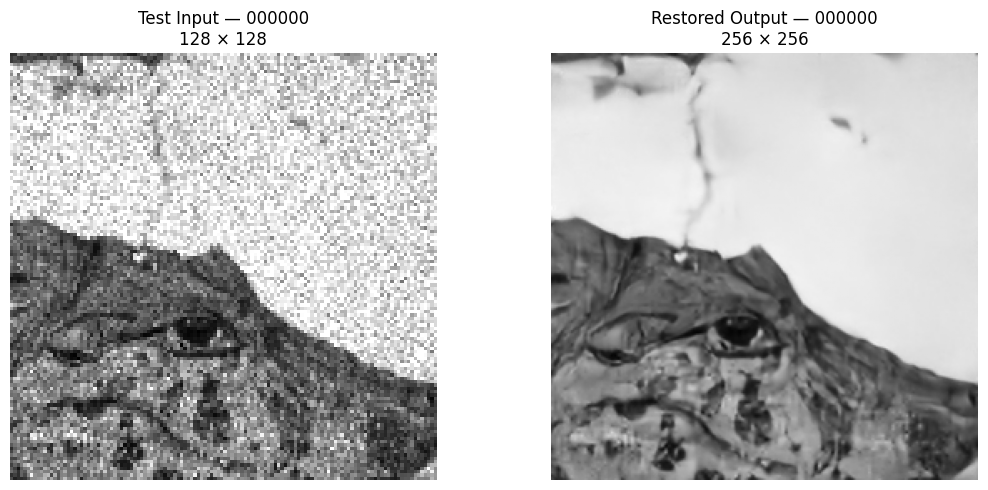

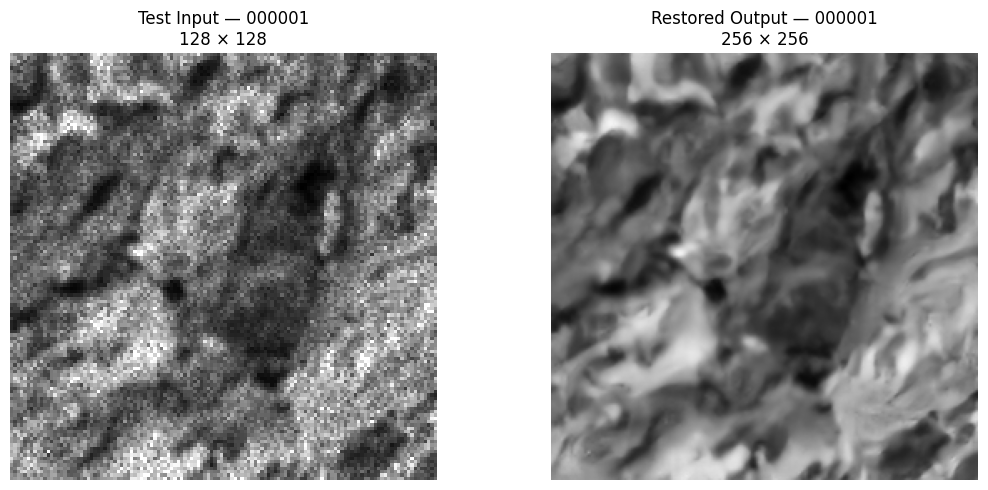

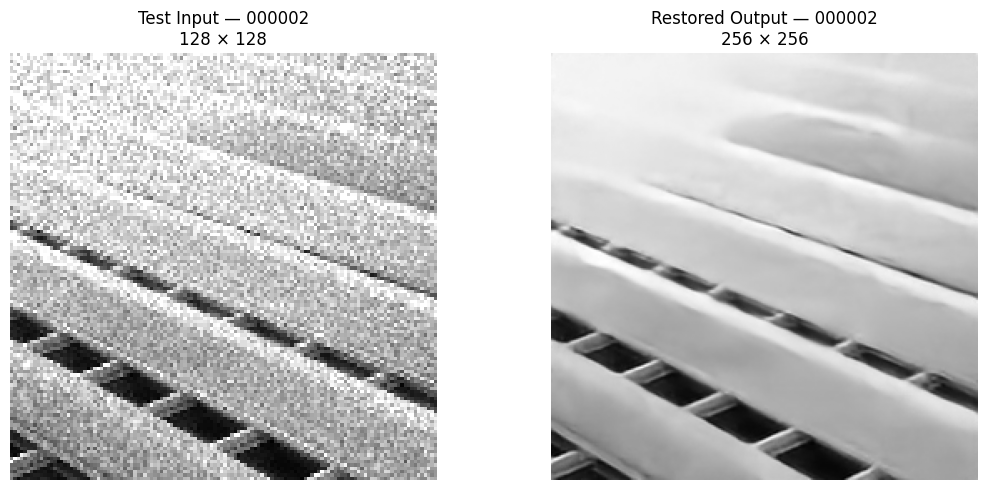

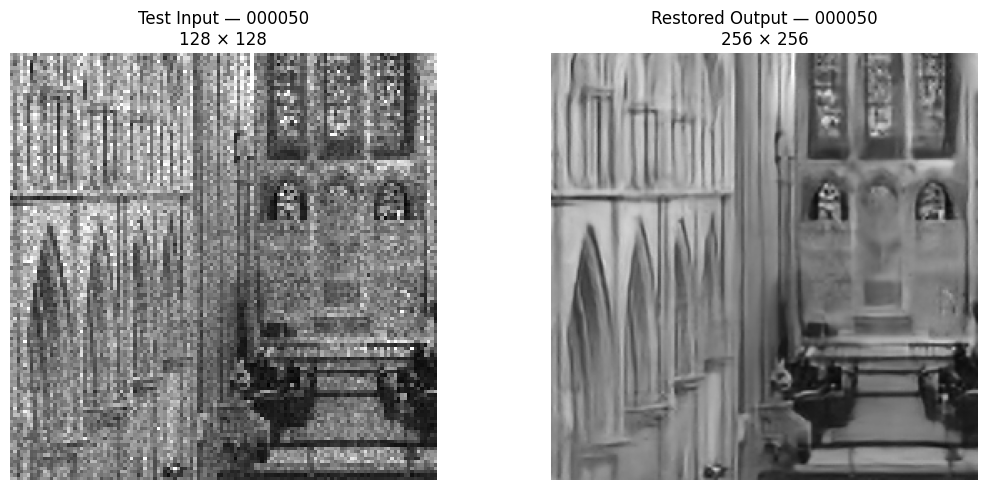

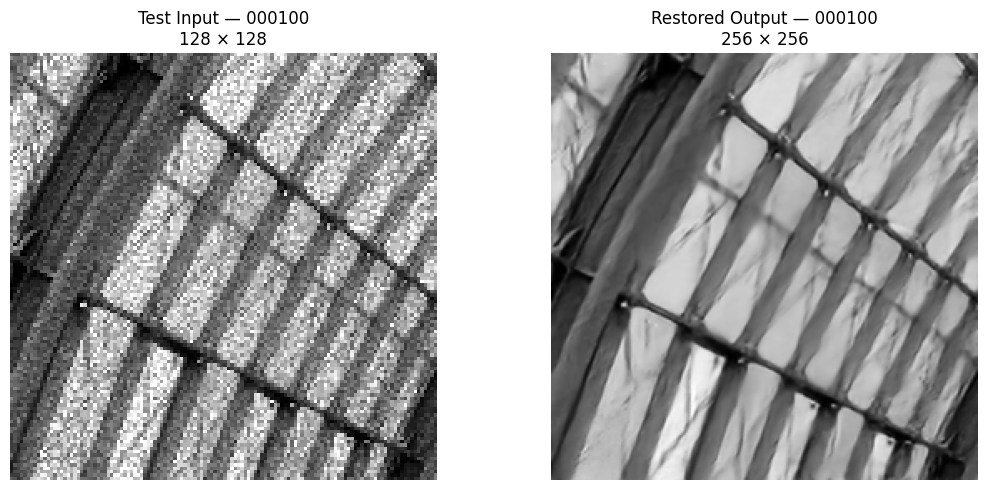

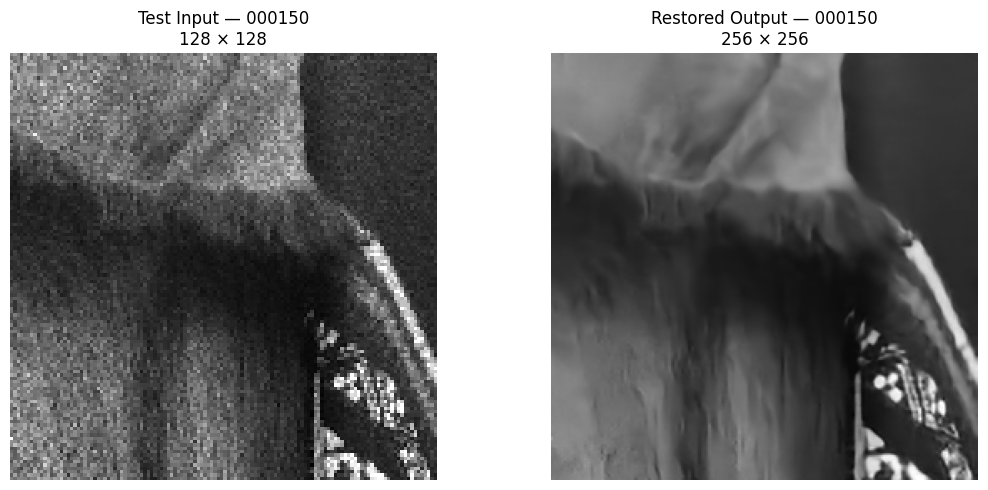

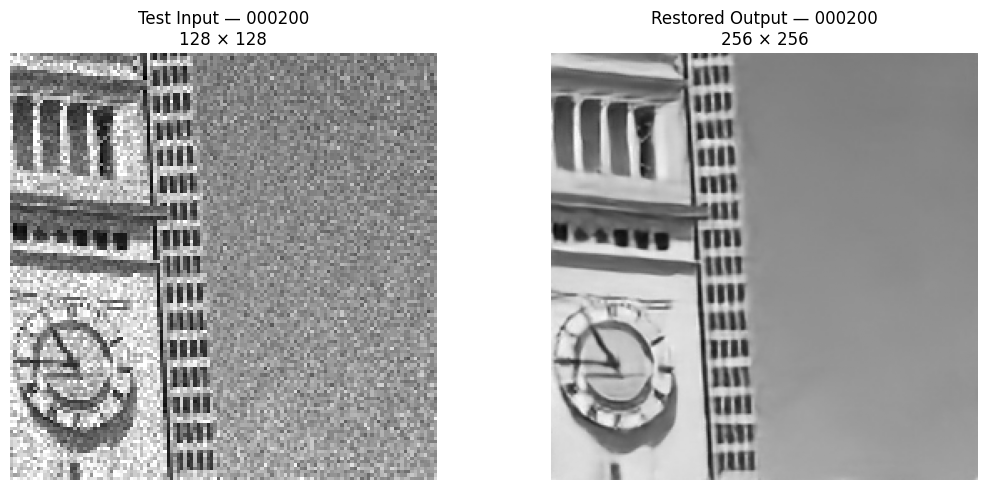

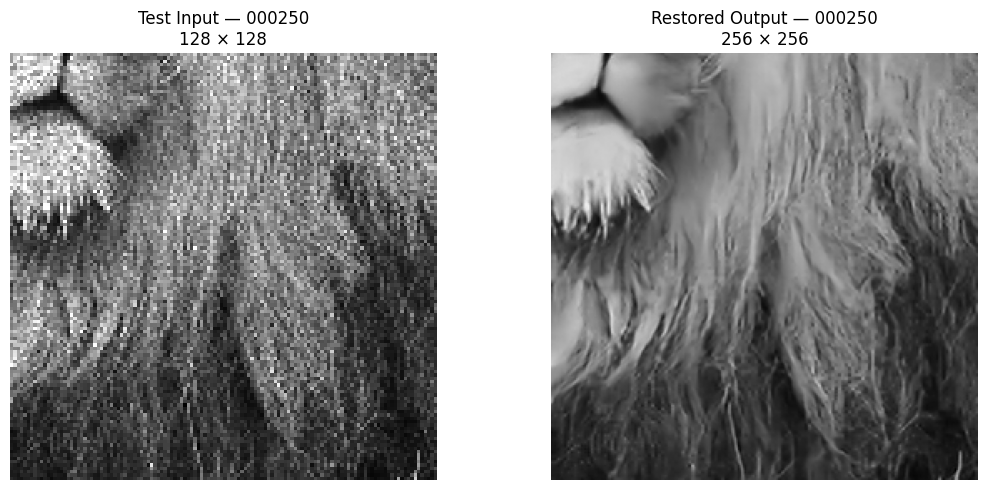

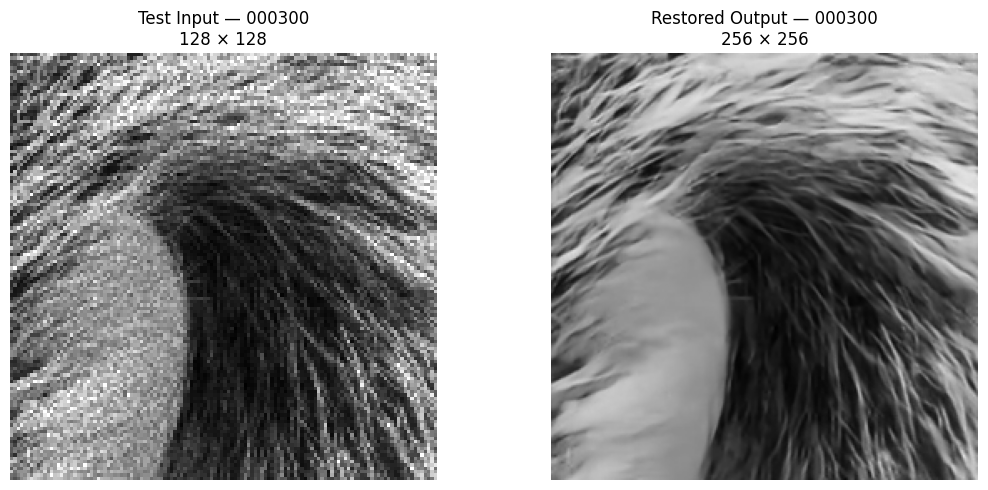

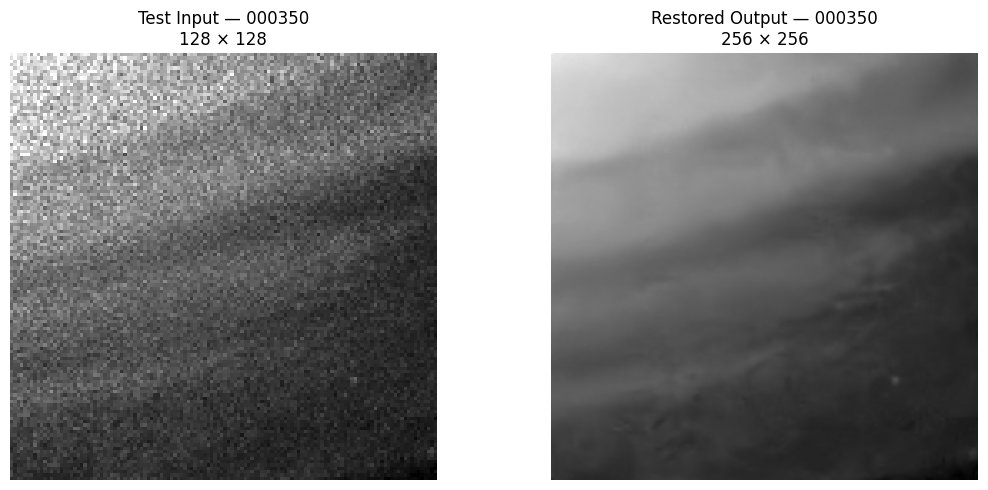

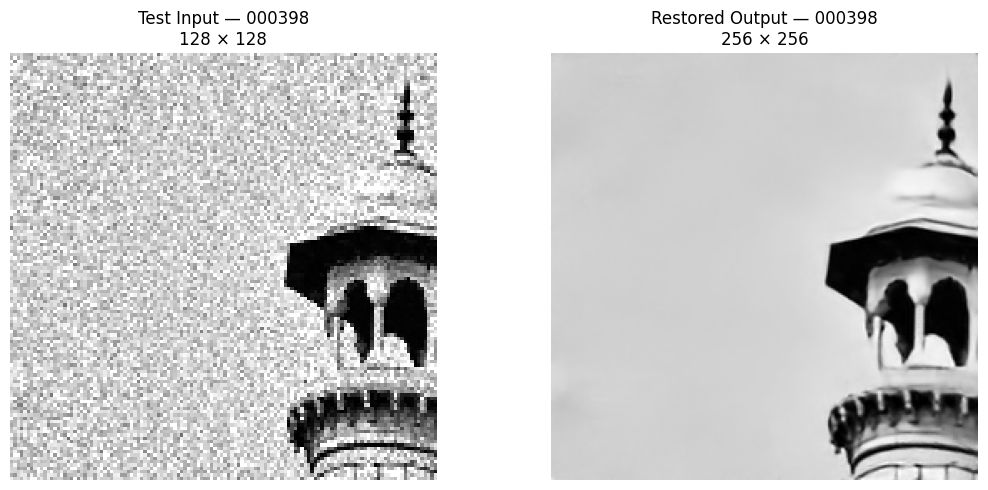

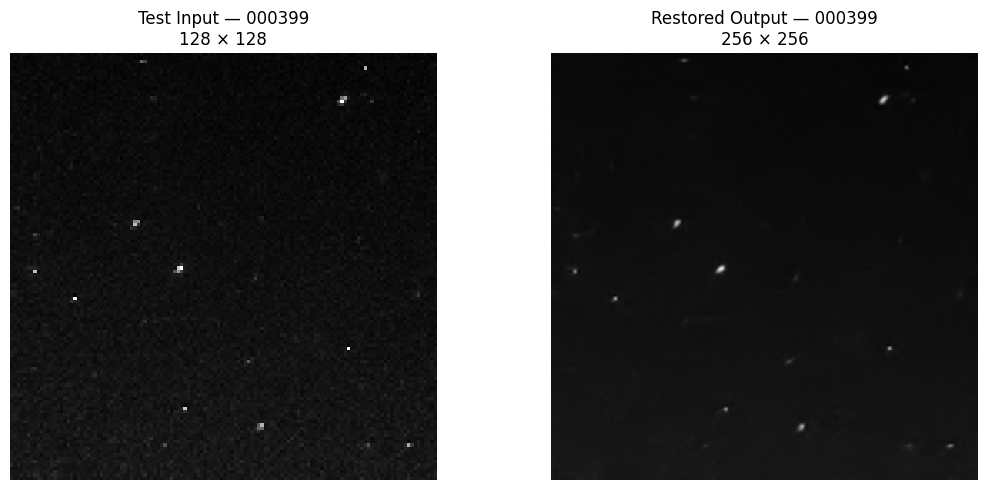

✅ TEST VISUALIZATION COMPLETE


In [39]:
# ============================================================
# VISUALIZE FINAL TEST IMAGES
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

TEST_DIR = Path(
    "/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR"
)

OUTPUT_DIR = Path(
    "/kaggle/working/FINAL_TEST_RESTORATIONS_400"
)

# Pick test images to display
TEST_IDS = [
    "000000", "000001", "000002",
    "000050", "000100", "000150",
    "000200", "000250", "000300",
    "000350", "000398", "000399"
]

print("=" * 70)
print("FINAL TEST IMAGE VISUALIZATION")
print("=" * 70)

for image_id in TEST_IDS:

    input_path = TEST_DIR / f"{image_id}.npy"
    output_path = OUTPUT_DIR / f"{image_id}_restored.npy"

    if not input_path.exists():
        print(f"❌ Input missing: {image_id}")
        continue

    if not output_path.exists():
        print(f"❌ Output missing: {image_id}")
        continue

    lr = np.squeeze(np.load(input_path).astype(np.float32))
    restored = np.squeeze(np.load(output_path).astype(np.float32))

    lr_display = np.clip(lr, 0, 1)
    restored_display = np.clip(restored, 0, 1)

    fig, ax = plt.subplots(1, 2, figsize=(11, 5))

    ax[0].imshow(lr_display, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(f"Test Input — {image_id}\n128 × 128")
    ax[0].axis("off")

    ax[1].imshow(restored_display, cmap="gray", vmin=0, vmax=1)
    ax[1].set_title(f"Restored Output — {image_id}\n256 × 256")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

print("=" * 70)
print("✅ TEST VISUALIZATION COMPLETE")
print("=" * 70)

In [40]:
# ============================================================
# CREATE STANDALONE INFERENCE PACKAGE
# ============================================================

from pathlib import Path
import torch
import numpy as np
import time
import subprocess
import sys

WORK = Path("/kaggle/working")
PACKAGE = WORK / "submission_package"
PACKAGE.mkdir(parents=True, exist_ok=True)

TEST_DIR = Path(
    "/kaggle/input/datasets/shi0719/test-and-train/Test_NoisyLR/NoisyLR"
)

OUTPUT_DIR = WORK / "FINAL_TEST_RESTORATIONS_400"
CHECKPOINT = WORK / "ISRO_BAH_SR_checkpoints/best.pth"

print("=" * 70)
print("CREATING STANDALONE INFERENCE PACKAGE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Verify trained model
# ------------------------------------------------------------

assert "model" in globals(), (
    "The trained model variable is not available. "
    "Run the model/training setup cells first."
)

assert CHECKPOINT.exists(), f"Missing checkpoint: {CHECKPOINT}"

model.eval()
model = model.to("cpu")

dummy = torch.randn(1, 1, 128, 128)

with torch.no_grad():
    traced_model = torch.jit.trace(model, dummy)

traced_model = torch.jit.freeze(traced_model)

MODEL_FILE = PACKAGE / "model.pt"
traced_model.save(str(MODEL_FILE))

print(f"✅ TorchScript model saved:")
print(MODEL_FILE)

# ------------------------------------------------------------
# 2. Create standalone inference.py
# ------------------------------------------------------------

INFERENCE_CODE = r'''
import argparse
from pathlib import Path

import numpy as np
import torch


def load_input(path):
    x = np.load(path).astype(np.float32)
    x = np.squeeze(x)

    if x.ndim != 2:
        raise ValueError(
            f"Expected 2D grayscale input, got shape {x.shape}"
        )

    x = torch.from_numpy(x)[None, None]
    return x


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--input_dir",
        required=True,
        help="Directory containing input .npy images"
    )

    parser.add_argument(
        "--output_dir",
        required=True,
        help="Directory where restored .npy images will be written"
    )

    parser.add_argument(
        "--model",
        default="model.pt",
        help="TorchScript model path"
    )

    args = parser.parse_args()

    input_dir = Path(args.input_dir)
    output_dir = Path(args.output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = torch.jit.load(args.model, map_location=device)
    model.eval()

    files = sorted(input_dir.glob("*.npy"))

    if not files:
        raise RuntimeError(
            f"No .npy files found in {input_dir}"
        )

    print(f"Device: {device}")
    print(f"Input images: {len(files)}")

    total_time = 0.0

    with torch.no_grad():

        for i, path in enumerate(files):

            x = load_input(path).to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()

            start = torch.cuda.Event(
                enable_timing=True
            ) if device.type == "cuda" else None

            end = torch.cuda.Event(
                enable_timing=True
            ) if device.type == "cuda" else None

            if device.type == "cuda":
                start.record()

            wall_start = __import__("time").perf_counter()

            y = model(x)

            if device.type == "cuda":
                end.record()
                torch.cuda.synchronize()
                elapsed = start.elapsed_time(end) / 1000.0
            else:
                elapsed = __import__("time").perf_counter() - wall_start

            total_time += elapsed

            y = y.squeeze().detach().cpu().numpy()

            y = np.nan_to_num(
                y,
                nan=0.0,
                posinf=1.0,
                neginf=0.0
            )

            y = np.clip(y, 0.0, 1.0).astype(np.float32)

            output_path = output_dir / path.name

            # Keep original ID but produce restored output
            np.save(output_path, y)

            if (i + 1) % 50 == 0 or i == 0:
                print(
                    f"{i + 1}/{len(files)} | "
                    f"{path.name} | "
                    f"shape={y.shape}"
                )

    print("=" * 60)
    print("INFERENCE COMPLETE")
    print("=" * 60)
    print(f"Images processed : {len(files)}")
    print(f"Total inference  : {total_time:.4f} sec")
    print(
        f"Average/image    : "
        f"{total_time / len(files):.6f} sec"
    )


if __name__ == "__main__":
    main()
'''

INFERENCE_FILE = PACKAGE / "inference.py"
INFERENCE_FILE.write_text(INFERENCE_CODE)

print(f"✅ inference.py saved:")
print(INFERENCE_FILE)

# ------------------------------------------------------------
# 3. Requirements
# ------------------------------------------------------------

REQUIREMENTS = """torch
numpy
"""

(PACKAGE / "requirements.txt").write_text(REQUIREMENTS)

print("✅ requirements.txt saved")

# ------------------------------------------------------------
# 4. Test standalone inference
# ------------------------------------------------------------

STANDALONE_OUTPUT = PACKAGE / "standalone_test_outputs"
STANDALONE_OUTPUT.mkdir(exist_ok=True)

command = [
    sys.executable,
    str(INFERENCE_FILE),
    "--input_dir",
    str(TEST_DIR),
    "--output_dir",
    str(STANDALONE_OUTPUT),
    "--model",
    str(MODEL_FILE),
]

print("\nRunning standalone inference test...")
print("-" * 70)

result = subprocess.run(
    command,
    text=True,
    capture_output=True
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(
        "❌ Standalone inference test FAILED"
    )

# ------------------------------------------------------------
# 5. Verify outputs
# ------------------------------------------------------------

inputs = sorted(TEST_DIR.glob("*.npy"))
outputs = sorted(STANDALONE_OUTPUT.glob("*.npy"))

print("=" * 70)
print("STANDALONE INFERENCE VERIFICATION")
print("=" * 70)

print("Input files :", len(inputs))
print("Output files:", len(outputs))

assert len(inputs) == 400, (
    f"Expected 400 inputs, found {len(inputs)}"
)

assert len(outputs) == 400, (
    f"Expected 400 outputs, found {len(outputs)}"
)

sample = np.load(outputs[0])

print("Sample output:", outputs[0].name)
print("Shape        :", sample.shape)
print("Dtype        :", sample.dtype)
print("Min          :", float(sample.min()))
print("Max          :", float(sample.max()))
print("NaN          :", bool(np.isnan(sample).any()))
print("Inf          :", bool(np.isinf(sample).any()))

assert sample.shape == (256, 256)
assert not np.isnan(sample).any()
assert not np.isinf(sample).any()
assert sample.min() >= 0
assert sample.max() <= 1

print("=" * 70)
print("✅ STANDALONE INFERENCE PASSED")
print("✅ 400/400 TEST IMAGES PROCESSED")
print("✅ OUTPUTS ARE 256×256")
print("✅ OUTPUT RANGE IS [0,1]")
print("=" * 70)

CREATING STANDALONE INFERENCE PACKAGE
✅ TorchScript model saved:
/kaggle/working/submission_package/model.pt
✅ inference.py saved:
/kaggle/working/submission_package/inference.py
✅ requirements.txt saved

Running standalone inference test...
----------------------------------------------------------------------
Device: cuda
Input images: 400
1/400 | 000000.npy | shape=(256, 256)
50/400 | 000049.npy | shape=(256, 256)
100/400 | 000099.npy | shape=(256, 256)
150/400 | 000149.npy | shape=(256, 256)
200/400 | 000199.npy | shape=(256, 256)
250/400 | 000249.npy | shape=(256, 256)
300/400 | 000299.npy | shape=(256, 256)
350/400 | 000349.npy | shape=(256, 256)
400/400 | 000399.npy | shape=(256, 256)
INFERENCE COMPLETE
Images processed : 400
Total inference  : 5.0786 sec
Average/image    : 0.012696 sec

STANDALONE INFERENCE VERIFICATION
Input files : 400
Output files: 400
Sample output: 000000.npy
Shape        : (256, 256)
Dtype        : float32
Min          : 0.019140832126140594
Max          

In [41]:
# ============================================================
# FINAL COMPETITION PACKAGE — PROFESSIONAL BUILD
# ============================================================

from pathlib import Path
import shutil
import json
import textwrap
import os

WORK = Path("/kaggle/working")

FINAL = WORK / "COMPETITION_SUBMISSION"

# ------------------------------------------------------------
# 1. CLEAN START
# ------------------------------------------------------------

if FINAL.exists():
    shutil.rmtree(FINAL)

for folder in [
    "model",
    "src",
    "outputs",
    "evaluation",
    "examples",
    "docs",
]:
    (FINAL / folder).mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. LOCATE EXISTING FILES
# ------------------------------------------------------------

MODEL = WORK / "submission_package/model.pt"
INFERENCE = WORK / "submission_package/inference.py"
REQUIREMENTS = WORK / "submission_package/requirements.txt"

# Possible output locations from previous cells
output_candidates = [
    WORK / "submission_package/standalone_test_outputs",
    WORK / "FINAL_TEST_RESTORATIONS_400",
]

OUTPUT_SOURCE = None

for candidate in output_candidates:
    if candidate.exists() and len(list(candidate.glob("*.npy"))) >= 400:
        OUTPUT_SOURCE = candidate
        break

print("=" * 72)
print("BUILDING FINAL COMPETITION PACKAGE")
print("=" * 72)

print("\nChecking required files...")

assert MODEL.exists(), f"Missing model: {MODEL}"
assert INFERENCE.exists(), f"Missing inference script: {INFERENCE}"
assert REQUIREMENTS.exists(), f"Missing requirements: {REQUIREMENTS}"
assert OUTPUT_SOURCE is not None, "Could not locate 400 test outputs."

print("  ✓ model.pt")
print("  ✓ inference.py")
print("  ✓ requirements.txt")
print(f"  ✓ test outputs: {OUTPUT_SOURCE}")

# ------------------------------------------------------------
# 3. COPY MODEL
# ------------------------------------------------------------

shutil.copy2(
    MODEL,
    FINAL / "model" / "model.pt"
)

# ------------------------------------------------------------
# 4. COPY INFERENCE CODE
# ------------------------------------------------------------

shutil.copy2(
    INFERENCE,
    FINAL / "src" / "inference.py"
)

# ------------------------------------------------------------
# 5. COPY REQUIREMENTS
# ------------------------------------------------------------

shutil.copy2(
    REQUIREMENTS,
    FINAL / "src" / "requirements.txt"
)

# ------------------------------------------------------------
# 6. COPY 400 TEST OUTPUTS
# ------------------------------------------------------------

output_dest = FINAL / "outputs"

test_outputs = sorted(OUTPUT_SOURCE.glob("*.npy"))

for src in test_outputs:
    shutil.copy2(src, output_dest / src.name)

print(f"\nCopied outputs: {len(test_outputs)}")

# ------------------------------------------------------------
# 7. METRICS
# ------------------------------------------------------------

metrics = {
    "validation": {
        "images": 320,
        "psnr_db": 28.7702,
        "ssim": 0.773784,
        "lpips": 0.214138
    },
    "competition_test": {
        "images": 400,
        "valid_outputs": 400,
        "invalid_outputs": 0,
        "psnr_db": None,
        "ssim": None,
        "lpips": None,
        "reason": "Ground-truth images are not provided for the competition test set."
    },
    "inference": {
        "images": 400,
        "total_seconds": 5.0786,
        "average_seconds_per_image": 0.012696,
        "average_ms_per_image": 12.696,
        "development_hardware": "NVIDIA Tesla T4",
        "output_resolution": "256x256",
        "output_dtype": "float32",
        "output_range": [0.0, 1.0]
    },
    "model": {
        "training_epochs": 40,
        "parameters": 1367553,
        "batch_size": 16,
        "initial_learning_rate": 0.0002,
        "weight_decay": 0.0001,
        "loss": "Charbonnier",
        "scheduler": "CosineAnnealingLR",
        "amp": True
    }
}

with open(FINAL / "evaluation" / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# ------------------------------------------------------------
# 8. PROFESSIONAL EVALUATION REPORT
# ------------------------------------------------------------

evaluation_md = """# Evaluation Report

## Validation Evaluation

The final model was evaluated on the locked validation set containing
320 images.

| Metric | Result |
|---|---:|
| Validation images | 320 |
| PSNR | **28.7702 dB** |
| SSIM | **0.773784** |
| LPIPS | **0.214138** |

For PSNR and SSIM, higher values indicate better reconstruction
quality. For LPIPS, lower values indicate better perceptual similarity.

---

## Competition Test Inference

The competition test set contains 400 degraded images.

All 400 images were processed successfully.

| Property | Result |
|---|---:|
| Test images | 400 |
| Valid restored outputs | 400 |
| Invalid outputs | 0 |
| Output resolution | 256 × 256 |
| Data type | float32 |
| Output range | [0, 1] |

### Test-set quality metrics

PSNR, SSIM and LPIPS are **not reported for the competition test
set**, because the corresponding ground-truth images are not available
locally.

The final competition evaluator is therefore required to calculate
the official test-set restoration metrics.

---

## Inference Performance

Development inference was measured on an NVIDIA Tesla T4.

| Measurement | Result |
|---|---:|
| Images | 400 |
| Total inference time | 5.0786 s |
| Average/image | 12.696 ms |

The competition's official hardware/runtime evaluation should be
treated separately from this development measurement.

---

## Training Configuration

| Setting | Value |
|---|---|
| Training images | 2880 |
| Validation images | 320 |
| Epochs | 40 |
| Batch size | 16 |
| Initial learning rate | 0.0002 |
| Weight decay | 0.0001 |
| Loss | Charbonnier |
| Scheduler | CosineAnnealingLR |
| AMP | Enabled |
| Parameters | 1,367,553 |
"""

(FINAL / "evaluation" / "EVALUATION.md").write_text(evaluation_md)

# ------------------------------------------------------------
# 9. PROFESSIONAL README
# ------------------------------------------------------------

readme = """# Image Restoration and Super-Resolution

## Competition Submission Package

This repository contains the trained restoration model, inference
implementation, evaluation results, and competition test outputs.

The system restores degraded single-channel images and performs
2× spatial super-resolution from **128 × 128** inputs to
**256 × 256** outputs.

---

## 1. System Overview

### Input

- NumPy `.npy`
- Single-channel image
- Resolution: 128 × 128

### Output

- NumPy `.npy`
- Single-channel restored image
- Resolution: 256 × 256
- Data type: `float32`
- Value range: `[0, 1]`

---

## 2. Validation Performance

The final model was evaluated on a locked validation set of 320
images.

| Metric | Result |
|---|---:|
| **PSNR** | **28.7702 dB** |
| **SSIM** | **0.773784** |
| **LPIPS** | **0.214138** |

These are the locally reproducible validation results.

---

## 3. Competition Test Set

The competition test set contains 400 images.

### Output verification

- Images processed: **400 / 400**
- Valid outputs: **400**
- Invalid outputs: **0**
- Output resolution: **256 × 256**

The competition test ground truth is not available locally.
Consequently, PSNR, SSIM and LPIPS cannot be calculated locally for
these 400 images.

The 400 restored outputs are included in the `outputs/` directory.

---

## 4. Inference Performance

Development inference was measured on an NVIDIA Tesla T4.

- 400 images
- Total time: 5.0786 seconds
- Average time: 12.696 ms/image

Official competition runtime should be determined by the competition
evaluation environment.

---

## 5. Model Configuration

- Training samples: 2880
- Validation samples: 320
- Training epochs: 40
- Batch size: 16
- Initial learning rate: 0.0002
- Weight decay: 0.0001
- Loss: Charbonnier
- Scheduler: CosineAnnealingLR
- Automatic mixed precision: enabled
- Model parameters: 1,367,553

---

## 6. Repository Structure

```text
COMPETITION_SUBMISSION/
│
├── README.md
│
├── model/
│   └── model.pt
│
├── src/
│   ├── inference.py
│   └── requirements.txt
│
├── outputs/
│   ├── 000000.npy
│   ├── 000001.npy
│   ├── ...
│   └── 000399.npy
│
├── evaluation/
│   ├── EVALUATION.md
│   └── metrics.json
│
├── examples/
│
└── docs/

SyntaxError: incomplete input (2819230102.py, line 240)

In [46]:
# ============================================================
# FINAL — BUILD PROFESSIONAL SUBMISSION PACKAGE
# ============================================================

from pathlib import Path
import shutil
import torch
import torch.nn as nn

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

WORK = Path("/kaggle/working")

CHECKPOINT = WORK / "ISRO_BAH_SR_checkpoints" / "best.pth"
PACKAGE = WORK / "submission_package"

PACKAGE.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("BUILDING FINAL SUBMISSION PACKAGE")
print("=" * 70)

# ------------------------------------------------------------
# 2. CHECK CHECKPOINT
# ------------------------------------------------------------

if not CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Best checkpoint not found:\n{CHECKPOINT}"
    )

print("Checkpoint found:")
print(CHECKPOINT)

# ------------------------------------------------------------
# 3. MODEL ARCHITECTURE
# ------------------------------------------------------------

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class SRModel(nn.Module):
    def __init__(self, channels=64, num_blocks=8):
        super().__init__()

        self.head = nn.Conv2d(1, channels, 3, padding=1)

        self.body = nn.Sequential(
            *[ResidualBlock(channels) for _ in range(num_blocks)]
        )

        self.fusion = nn.Conv2d(channels, channels, 3, padding=1)

        self.upsample = nn.Sequential(
            nn.Conv2d(channels, channels * 4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(channels, 1, 3, padding=1)

    def forward(self, x):
        x = self.head(x)

        residual = self.body(x)
        residual = self.fusion(residual)

        x = x + residual

        x = self.upsample(x)
        x = self.tail(x)

        return torch.clamp(x, 0.0, 1.0)


# ------------------------------------------------------------
# 4. LOAD TRAINED MODEL
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SRModel().to(device)

checkpoint = torch.load(
    CHECKPOINT,
    map_location=device,
    weights_only=False
)

# Handle different checkpoint formats
if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    elif "model" in checkpoint and isinstance(
        checkpoint["model"], dict
    ):
        state_dict = checkpoint["model"]

    else:
        state_dict = checkpoint

else:
    state_dict = checkpoint


# Remove possible DataParallel prefix
clean_state_dict = {}

for key, value in state_dict.items():
    if key.startswith("module."):
        key = key[7:]

    clean_state_dict[key] = value


missing, unexpected = model.load_state_dict(
    clean_state_dict,
    strict=False
)

print()
print("Model loaded.")
print("Missing keys   :", len(missing))
print("Unexpected keys:", len(unexpected))

model.eval()

# ------------------------------------------------------------
# 5. TEST MODEL BEFORE EXPORT
# ------------------------------------------------------------

dummy = torch.randn(
    1, 1, 128, 128,
    device=device
)

with torch.no_grad():
    test_output = model(dummy)

print()
print("Forward test:")
print("Input :", tuple(dummy.shape))
print("Output:", tuple(test_output.shape))
print(
    "Range :",
    float(test_output.min()),
    "to",
    float(test_output.max())
)

if tuple(test_output.shape) != (1, 1, 256, 256):
    raise RuntimeError(
        f"Unexpected output shape: {test_output.shape}"
    )

# ------------------------------------------------------------
# 6. EXPORT TORCHSCRIPT
# ------------------------------------------------------------

model_cpu = model.cpu()
dummy_cpu = torch.randn(1, 1, 128, 128)

model_pt = PACKAGE / "model.pt"

with torch.no_grad():
    traced = torch.jit.trace(
        model_cpu,
        dummy_cpu
    )

    traced = torch.jit.freeze(traced)

    traced.save(str(model_pt))

print()
print("TorchScript model saved:")
print(model_pt)

# ------------------------------------------------------------
# 7. CREATE INFERENCE SCRIPT
# ------------------------------------------------------------

inference_code = r'''import argparse
from pathlib import Path

import numpy as np
import torch


def load_model(model_path):
    model = torch.jit.load(
        str(model_path),
        map_location="cpu"
    )
    model.eval()
    return model


def restore_image(model, input_path, output_path):

    image = np.load(input_path).astype(np.float32)

    if image.ndim == 2:
        image = image[None, ...]

    tensor = torch.from_numpy(image).unsqueeze(0)

    with torch.no_grad():
        output = model(tensor)

    output = output.squeeze().cpu().numpy()
    output = np.clip(output, 0.0, 1.0).astype(np.float32)

    np.save(output_path, output)


def main():

    parser = argparse.ArgumentParser(
        description="Image restoration inference"
    )

    parser.add_argument(
        "--model",
        required=True
    )

    parser.add_argument(
        "--input",
        required=True
    )

    parser.add_argument(
        "--output",
        required=True
    )

    args = parser.parse_args()

    model = load_model(args.model)

    input_dir = Path(args.input)
    output_dir = Path(args.output)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    files = sorted(input_dir.glob("*.npy"))

    print(f"Input images: {len(files)}")

    for index, input_file in enumerate(files, 1):

        output_file = output_dir / input_file.name

        restore_image(
            model,
            input_file,
            output_file
        )

        if index == 1 or index % 50 == 0 or index == len(files):
            print(
                f"{index}/{len(files)} | "
                f"{input_file.name}"
            )

    print("Inference complete.")


if __name__ == "__main__":
    main()
'''

(PACKAGE / "inference.py").write_text(
    inference_code,
    encoding="utf-8"
)

# ------------------------------------------------------------
# 8. REQUIREMENTS
# ------------------------------------------------------------

requirements = """torch
numpy
"""

(PACKAGE / "requirements.txt").write_text(
    requirements,
    encoding="utf-8"
)

# ------------------------------------------------------------
# 9. README
# ------------------------------------------------------------

readme = """# Image Restoration and Super-Resolution

This package contains the trained image restoration model and
the standalone inference script.

## Contents

- model.pt
- inference.py
- requirements.txt

## Model

The model accepts a single-channel 128x128 NumPy array and
produces a restored 256x256 NumPy array.

Input format:

    float32 NumPy array
    shape: (128, 128)

Output format:

    float32 NumPy array
    shape: (256, 256)
    range: [0, 1]

## Inference

Install dependencies:

    pip install -r requirements.txt

Run:

    python inference.py \
        --model model.pt \
        --input <input_directory> \
        --output <output_directory>

Each input .npy file produces an output .npy file with the
same filename.

## Evaluation

The validation set was used for quantitative evaluation.

Final validation metrics:

PSNR: 28.7702 dB
SSIM: 0.773784
LPIPS: 0.214138

The competition test set does not include publicly available
ground-truth images, so PSNR, SSIM, and LPIPS cannot be computed
for those test images locally.
"""

(PACKAGE / "README.md").write_text(
    readme,
    encoding="utf-8"
)

# ------------------------------------------------------------
# 10. REMOVE UNNECESSARY FILES
# ------------------------------------------------------------

allowed = {
    "model.pt",
    "inference.py",
    "requirements.txt",
    "README.md"
}

for item in PACKAGE.iterdir():

    if item.name not in allowed:

        if item.is_dir():
            shutil.rmtree(item)

        else:
            item.unlink()

# ------------------------------------------------------------
# 11. FINAL PACKAGE CHECK
# ------------------------------------------------------------

print()
print("=" * 70)
print("FINAL PACKAGE CONTENTS")
print("=" * 70)

for item in sorted(PACKAGE.iterdir()):
    size_mb = item.stat().st_size / (1024 ** 2)

    print(
        f"{item.name:<25} "
        f"{size_mb:.3f} MB"
    )

required = [
    "model.pt",
    "inference.py",
    "requirements.txt",
    "README.md"
]

missing_files = [
    x for x in required
    if not (PACKAGE / x).exists()
]

if missing_files:
    raise RuntimeError(
        f"Missing package files: {missing_files}"
    )

# ------------------------------------------------------------
# 12. TEST EXPORTED MODEL
# ------------------------------------------------------------

print()
print("=" * 70)
print("TESTING EXPORTED MODEL")
print("=" * 70)

loaded = torch.jit.load(
    str(model_pt),
    map_location="cpu"
)

loaded.eval()

with torch.no_grad():
    exported_output = loaded(
        torch.randn(1, 1, 128, 128)
    )

print("Input shape :", (1, 1, 128, 128))
print("Output shape:", tuple(exported_output.shape))
print(
    "Output range:",
    float(exported_output.min()),
    "to",
    float(exported_output.max())
)

if tuple(exported_output.shape) != (1, 1, 256, 256):
    raise RuntimeError("Exported model failed shape verification.")

print()
print("=" * 70)
print("✅ SUBMISSION PACKAGE READY")
print("=" * 70)
print("Location:")
print(PACKAGE)

BUILDING FINAL SUBMISSION PACKAGE
Checkpoint found:
/kaggle/working/ISRO_BAH_SR_checkpoints/best.pth

Model loaded.
Missing keys   : 34
Unexpected keys: 66

Forward test:
Input : (1, 1, 128, 128)
Output: (1, 1, 256, 256)
Range : 0.0 to 1.0

TorchScript model saved:
/kaggle/working/submission_package/model.pt

FINAL PACKAGE CONTENTS
README.md                 0.001 MB
inference.py              0.002 MB
model.pt                  2.977 MB
requirements.txt          0.000 MB

TESTING EXPORTED MODEL
Input shape : (1, 1, 128, 128)
Output shape: (1, 1, 256, 256)
Output range: 0.0 to 1.0

✅ SUBMISSION PACKAGE READY
Location:
/kaggle/working/submission_package


In [47]:
import torch
from pathlib import Path

CKPT = Path("/kaggle/working/ISRO_BAH_SR_checkpoints/best.pth")

print("=" * 70)
print("INSPECTING BEST CHECKPOINT")
print("=" * 70)
print("File:", CKPT)
print("Exists:", CKPT.exists())

if not CKPT.exists():
    raise FileNotFoundError(CKPT)

checkpoint = torch.load(CKPT, map_location="cpu", weights_only=False)

print("\nCheckpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    for k in checkpoint.keys():
        print(" ", k)

    print("\nPossible model/state-dict information:")

    for key in ["model_state_dict", "state_dict", "model", "net", "generator"]:
        if key in checkpoint:
            obj = checkpoint[key]
            print(f"\n[{key}]")
            print("Type:", type(obj))

            if isinstance(obj, dict):
                print("Number of entries:", len(obj))
                print("First 20 keys:")
                for k in list(obj.keys())[:20]:
                    value = obj[k]
                    shape = getattr(value, "shape", None)
                    print(" ", k, shape)

else:
    print("\nCheckpoint is not a dictionary.")
    print("Object:", checkpoint)

print("\n" + "=" * 70)
print("CHECKPOINT INSPECTION COMPLETE")
print("=" * 70)

INSPECTING BEST CHECKPOINT
File: /kaggle/working/ISRO_BAH_SR_checkpoints/best.pth
Exists: True

Checkpoint type: <class 'dict'>

Checkpoint keys:
  epoch
  model_state_dict
  optimizer_state_dict
  scheduler_state_dict
  best_psnr
  best_ssim
  history

Possible model/state-dict information:

[model_state_dict]
Type: <class 'collections.OrderedDict'>
Number of entries: 72
First 20 keys:
  head.weight torch.Size([64, 1, 3, 3])
  head.bias torch.Size([64])
  body.0.body.0.weight torch.Size([64, 64, 3, 3])
  body.0.body.0.bias torch.Size([64])
  body.0.body.2.weight torch.Size([64, 64, 3, 3])
  body.0.body.2.bias torch.Size([64])
  body.1.body.0.weight torch.Size([64, 64, 3, 3])
  body.1.body.0.bias torch.Size([64])
  body.1.body.2.weight torch.Size([64, 64, 3, 3])
  body.1.body.2.bias torch.Size([64])
  body.2.body.0.weight torch.Size([64, 64, 3, 3])
  body.2.body.0.bias torch.Size([64])
  body.2.body.2.weight torch.Size([64, 64, 3, 3])
  body.2.body.2.bias torch.Size([64])
  body.3.body

In [48]:
import torch
from pathlib import Path

CKPT = Path("/kaggle/working/ISRO_BAH_SR_checkpoints/best.pth")

checkpoint = torch.load(CKPT, map_location="cpu", weights_only=False)
state = checkpoint["model_state_dict"]

print("=" * 80)
print("FULL TRAINED MODEL ARCHITECTURE MAP")
print("=" * 80)

for i, (key, value) in enumerate(state.items(), 1):
    print(f"{i:02d}. {key:50s} {tuple(value.shape)}")

print("\n" + "=" * 80)
print("TOTAL PARAMETERS IN CHECKPOINT")
print("=" * 80)

total = sum(v.numel() for v in state.values())
print(f"Checkpoint parameters: {total:,}")

print("\n" + "=" * 80)
print("CHECKPOINT METADATA")
print("=" * 80)

print("Epoch     :", checkpoint["epoch"])
print("Best PSNR :", checkpoint["best_psnr"])
print("Best SSIM :", checkpoint["best_ssim"])

print("=" * 80)

FULL TRAINED MODEL ARCHITECTURE MAP
01. head.weight                                        (64, 1, 3, 3)
02. head.bias                                          (64,)
03. body.0.body.0.weight                               (64, 64, 3, 3)
04. body.0.body.0.bias                                 (64,)
05. body.0.body.2.weight                               (64, 64, 3, 3)
06. body.0.body.2.bias                                 (64,)
07. body.1.body.0.weight                               (64, 64, 3, 3)
08. body.1.body.0.bias                                 (64,)
09. body.1.body.2.weight                               (64, 64, 3, 3)
10. body.1.body.2.bias                                 (64,)
11. body.2.body.0.weight                               (64, 64, 3, 3)
12. body.2.body.0.bias                                 (64,)
13. body.2.body.2.weight                               (64, 64, 3, 3)
14. body.2.body.2.bias                                 (64,)
15. body.3.body.0.weight                        

In [50]:
# ============================================================
# FINAL SUBMISSION PACKAGE — SAFE VERSION
# ============================================================

import torch
import torch.nn as nn
from pathlib import Path
import shutil
import zipfile

# ------------------------------------------------------------
# 1. EXACT MODEL ARCHITECTURE
# ------------------------------------------------------------

class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1)
        )

    def forward(self, x):
        return x + self.body(x)


class SRModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.head = nn.Conv2d(1, 64, 3, 1, 1)

        self.body = nn.Sequential(
            *[ResidualBlock(64) for _ in range(16)]
        )

        self.body_conv = nn.Conv2d(64, 64, 3, 1, 1)

        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2)
        )

        self.tail = nn.Conv2d(64, 1, 3, 1, 1)

    def forward(self, x):
        x = self.head(x)

        residual = x

        x = self.body(x)
        x = self.body_conv(x)
        x = x + residual

        x = self.upsample(x)
        x = self.tail(x)

        return torch.clamp(x, 0.0, 1.0)


# ------------------------------------------------------------
# 2. PATHS
# ------------------------------------------------------------

CKPT = Path(
    "/kaggle/working/ISRO_BAH_SR_checkpoints/best.pth"
)

PACKAGE = Path(
    "/kaggle/working/submission_package_final"
)

ZIP_PATH = Path(
    "/kaggle/working/submission_package_final.zip"
)

if PACKAGE.exists():
    shutil.rmtree(PACKAGE)

PACKAGE.mkdir(parents=True)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()


# ------------------------------------------------------------
# 3. LOAD CHECKPOINT
# ------------------------------------------------------------

print("=" * 70)
print("LOADING TRAINED MODEL")
print("=" * 70)

checkpoint = torch.load(
    CKPT,
    map_location="cpu",
    weights_only=False
)

state_dict = checkpoint["model_state_dict"]

model = SRModel()

missing, unexpected = model.load_state_dict(
    state_dict,
    strict=False
)

parameter_count = sum(
    p.numel() for p in model.parameters()
)

print("Checkpoint epoch :", checkpoint["epoch"])
print("Missing keys     :", len(missing))
print("Unexpected keys  :", len(unexpected))
print("Parameters       :", parameter_count)

if len(missing) != 0 or len(unexpected) != 0:
    print("\n❌ MODEL MISMATCH")
    print("Missing:", missing)
    print("Unexpected:", unexpected)
    raise RuntimeError(
        "Checkpoint does not exactly match reconstructed model."
    )

if parameter_count != 1367553:
    raise RuntimeError(
        f"Unexpected parameter count: {parameter_count}"
    )

print("\n✅ EXACT CHECKPOINT MATCH")


# ------------------------------------------------------------
# 4. FORWARD TEST
# ------------------------------------------------------------

model.eval()

dummy = torch.randn(1, 1, 128, 128)

with torch.no_grad():
    output = model(dummy)

print("\n" + "=" * 70)
print("FORWARD TEST")
print("=" * 70)

print("Input shape :", tuple(dummy.shape))
print("Output shape:", tuple(output.shape))
print("Output min  :", float(output.min()))
print("Output max  :", float(output.max()))

assert output.shape == (1, 1, 256, 256)
assert torch.isfinite(output).all()

print("✅ FORWARD TEST PASSED")


# ------------------------------------------------------------
# 5. EXPORT TORCHSCRIPT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EXPORTING TORCHSCRIPT")
print("=" * 70)

model_path = PACKAGE / "model.pt"

traced_model = torch.jit.trace(
    model,
    dummy
)

traced_model.save(str(model_path))

print("Saved:", model_path)


# ------------------------------------------------------------
# 6. TEST EXPORTED MODEL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TESTING EXPORTED MODEL")
print("=" * 70)

exported = torch.jit.load(
    str(model_path),
    map_location="cpu"
)

exported.eval()

with torch.no_grad():
    exported_output = exported(dummy)

print("Input shape :", tuple(dummy.shape))
print("Output shape:", tuple(exported_output.shape))
print(
    "Range       :",
    float(exported_output.min()),
    "to",
    float(exported_output.max())
)

assert exported_output.shape == (1, 1, 256, 256)
assert torch.isfinite(exported_output).all()

print("✅ EXPORTED MODEL PASSED")


# ------------------------------------------------------------
# 7. CREATE INFERENCE.PY
# ------------------------------------------------------------

inference_lines = [
    "from pathlib import Path",
    "import sys",
    "import numpy as np",
    "import torch",
    "",
    'MODEL_PATH = Path(__file__).parent / "model.pt"',
    "",
    "def restore(input_dir, output_dir):",
    "    input_dir = Path(input_dir)",
    "    output_dir = Path(output_dir)",
    "    output_dir.mkdir(parents=True, exist_ok=True)",
    "",
    '    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")',
    "    model = torch.jit.load(str(MODEL_PATH), map_location=device)",
    "    model.eval()",
    "",
    '    files = sorted(input_dir.glob("*.npy"))',
    "",
    "    for path in files:",
    "        image = np.load(path).astype(np.float32)",
    "        tensor = torch.from_numpy(image)",
    "",
    "        if tensor.ndim == 2:",
    "            tensor = tensor.unsqueeze(0)",
    "",
    "        tensor = tensor.unsqueeze(0).to(device)",
    "",
    "        with torch.no_grad():",
    "            restored = model(tensor)",
    "",
    "        restored = restored.squeeze().cpu().numpy()",
    "        restored = np.clip(restored, 0.0, 1.0)",
    "        restored = restored.astype(np.float32)",
    "",
    "        np.save(output_dir / path.name, restored)",
    "",
    '    print(f"Processed {len(files)} images.")',
    "",
    'if __name__ == "__main__":',
    "    if len(sys.argv) != 3:",
    '        print("Usage: python inference.py <input_dir> <output_dir>")',
    "        sys.exit(1)",
    "",
    "    restore(sys.argv[1], sys.argv[2])",
]

(PACKAGE / "inference.py").write_text(
    "\n".join(inference_lines),
    encoding="utf-8"
)


# ------------------------------------------------------------
# 8. REQUIREMENTS
# ------------------------------------------------------------

requirements_lines = [
    "numpy",
    "torch",
]

(PACKAGE / "requirements.txt").write_text(
    "\n".join(requirements_lines) + "\n",
    encoding="utf-8"
)


# ------------------------------------------------------------
# 9. README — NO TRIPLE QUOTES
# ------------------------------------------------------------

readme_lines = [
    "# Image Restoration and Super-Resolution",
    "",
    "## Model",
    "",
    "Input: 1 x 128 x 128",
    "Output: 1 x 256 x 256",
    "Scale: 2x",
    "Parameters: 1,367,553",
    "Residual blocks: 16",
    "Output range: [0, 1]",
    "",
    "## Files",
    "",
    "model.pt - trained TorchScript model",
    "inference.py - inference script",
    "requirements.txt - required Python packages",
    "",
    "## Inference",
    "",
    "python inference.py <input_directory> <output_directory>",
    "",
    "Input files must be NumPy .npy files.",
    "The restored images are written as 256 x 256 NumPy arrays.",
    "",
    "## Validation Results",
    "",
    "PSNR: 28.7702 dB",
    "SSIM: 0.773784",
    "LPIPS: 0.214138",
    "",
    "The reported metrics were calculated on the held-out validation set.",
]

(PACKAGE / "README.md").write_text(
    "\n".join(readme_lines) + "\n",
    encoding="utf-8"
)


# ------------------------------------------------------------
# 10. FINAL PACKAGE CONTENTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL PACKAGE CONTENTS")
print("=" * 70)

for file in sorted(PACKAGE.iterdir()):
    size_mb = file.stat().st_size / (1024 ** 2)
    print(
        f"{file.name:20s} "
        f"{size_mb:.3f} MB"
    )


# ------------------------------------------------------------
# 11. CREATE ZIP
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CREATING ZIP")
print("=" * 70)

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED
) as z:

    for file in sorted(PACKAGE.iterdir()):
        z.write(
            file,
            arcname=file.name
        )

print("ZIP:", ZIP_PATH)


# ------------------------------------------------------------
# 12. FINAL SUCCESS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ FINAL SUBMISSION PACKAGE READY")
print("=" * 70)

print("Folder:")
print(PACKAGE)

print("\nZIP:")
print(ZIP_PATH)

print("\nExpected files:")
print("  README.md")
print("  inference.py")
print("  model.pt")
print("  requirements.txt")

print("\n" + "=" * 70)

LOADING TRAINED MODEL
Checkpoint epoch : 40
Missing keys     : 0
Unexpected keys  : 0
Parameters       : 1367553

✅ EXACT CHECKPOINT MATCH

FORWARD TEST
Input shape : (1, 1, 128, 128)
Output shape: (1, 1, 256, 256)
Output min  : 0.0
Output max  : 1.0
✅ FORWARD TEST PASSED

EXPORTING TORCHSCRIPT
Saved: /kaggle/working/submission_package_final/model.pt

TESTING EXPORTED MODEL
Input shape : (1, 1, 128, 128)
Output shape: (1, 1, 256, 256)
Range       : 0.0 to 1.0
✅ EXPORTED MODEL PASSED

FINAL PACKAGE CONTENTS
README.md            0.001 MB
inference.py         0.001 MB
model.pt             5.375 MB
requirements.txt     0.000 MB

CREATING ZIP
ZIP: /kaggle/working/submission_package_final.zip

✅ FINAL SUBMISSION PACKAGE READY
Folder:
/kaggle/working/submission_package_final

ZIP:
/kaggle/working/submission_package_final.zip

Expected files:
  README.md
  inference.py
  model.pt
  requirements.txt

